In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

## Load and visuallize data

In [2]:
df_train = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025\processed_train.csv")
df_test = pd.read_csv(r"C:\mydata\G8Vitamin\data\final\08062025\processed_test.csv")

In [3]:
columns_remove = [
    'VitaminD',
    'YearStart',
]

In [4]:
df_train = df_train[df_train['milk_consumption']<=3]
df_test = df_test[df_test['milk_consumption']<=3]

In [5]:
df_train.drop(columns=columns_remove, inplace=True)
df_test.drop(columns=columns_remove, inplace=True)

In [6]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'familysize', 'PIR', 'BMI',
       'WaistCircumference', 'FastingGlucose', 'ALT', 'AST',
       'AlkalinePhosphotase', 'Triglycerides', 'UricAcid', 'Creatinine',
       'HDLCholesterol', 'LDLCholesterol', 'Hemoglobin', 'Hematocrit',
       'MeanCellVolumn', 'MeanCellHemoglobin', 'RedCellDistributionWidth',
       'PlateletCount', 'MeanPlateletVolume', 'SmokeFam', 'milk_consumption',
       'label'],
      dtype='object')

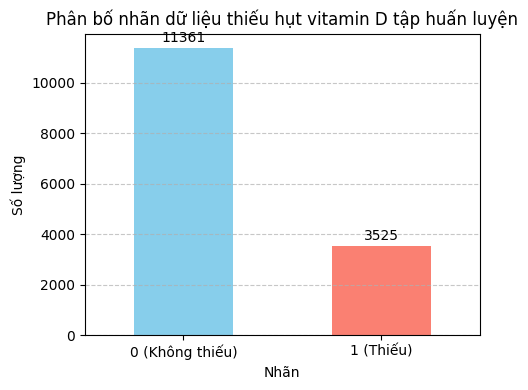

In [7]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_train['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập huấn luyện')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


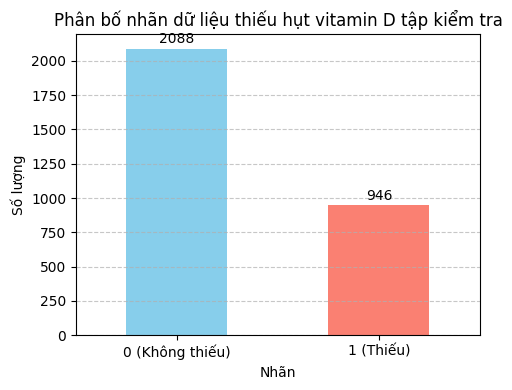

In [11]:
import matplotlib.pyplot as plt

# Count the labels
label_counts = df_test['label'].value_counts()

# Plot
plt.figure(figsize=(5, 4))
bars = label_counts.plot(kind='bar', color=['skyblue', 'salmon'])

# Add numbers on top of bars
for i, count in enumerate(label_counts):
    plt.text(i, count + max(label_counts) * 0.01, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Phân bố nhãn dữ liệu thiếu hụt vitamin D tập kiểm tra')
plt.xlabel('Nhãn')
plt.ylabel('Số lượng')
plt.xticks(ticks=[0, 1], labels=['0 (Không thiếu)', '1 (Thiếu)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [12]:
category_columns = [
    'Gender','SmokeFam' ,'Race', 'label','milk_consumption'
]

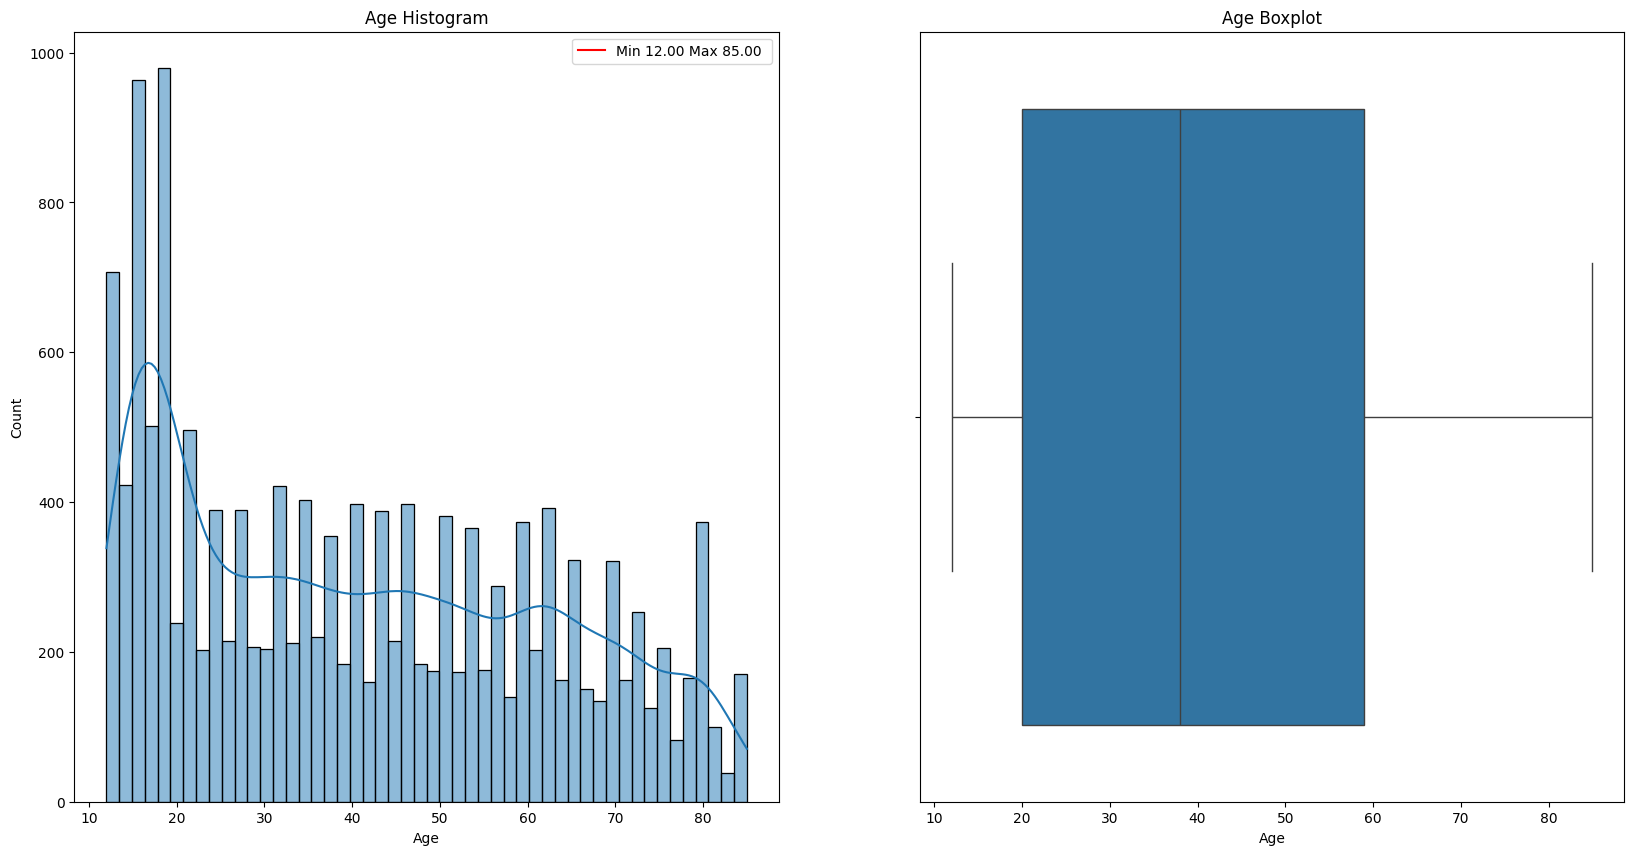

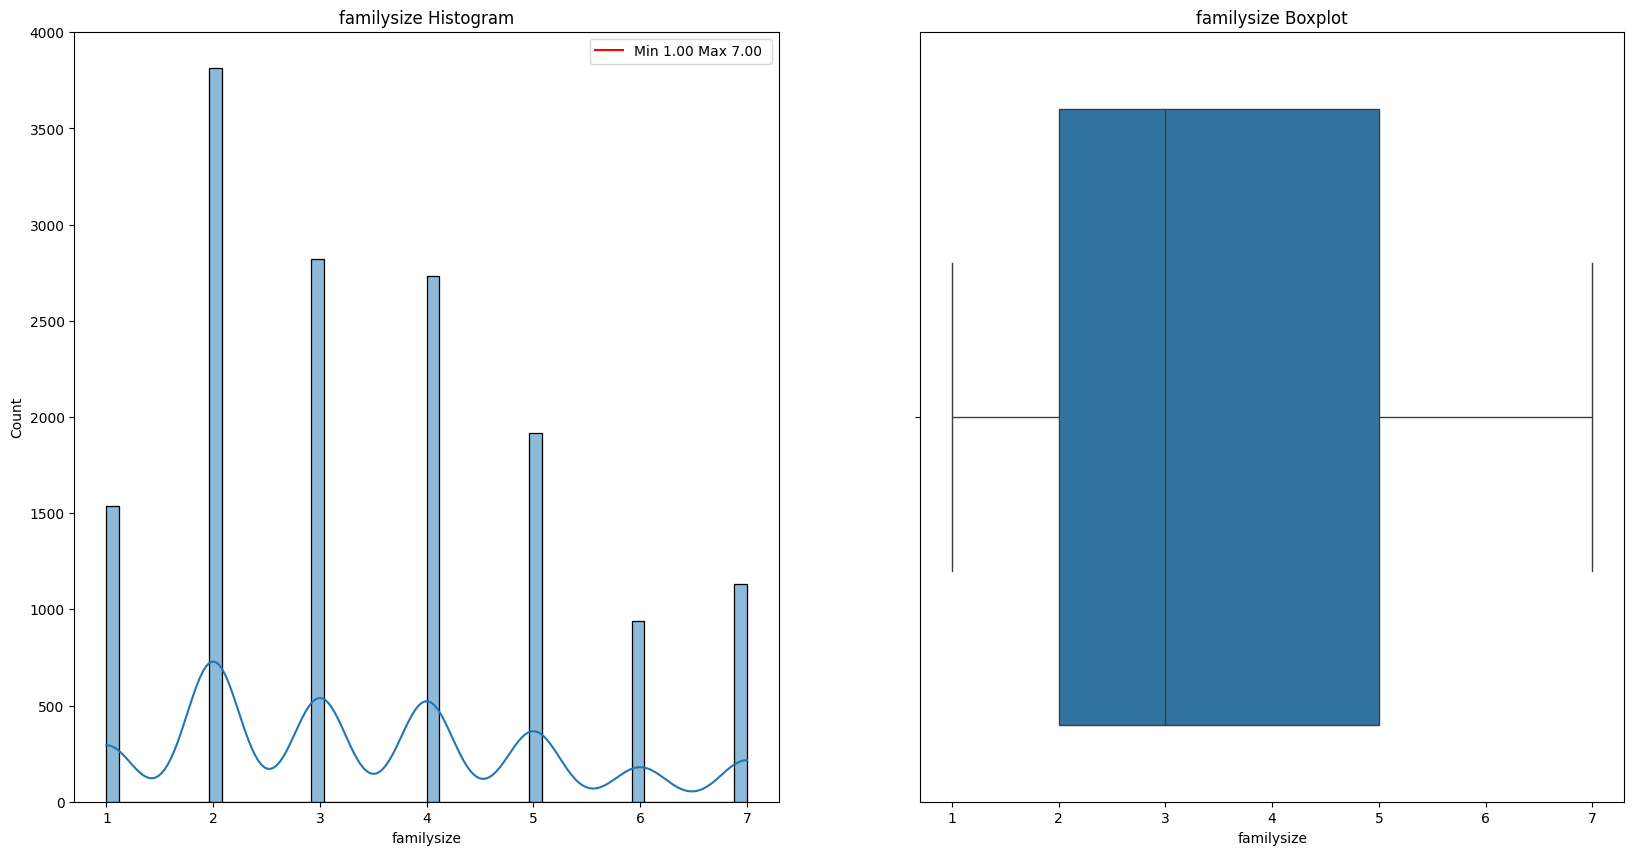

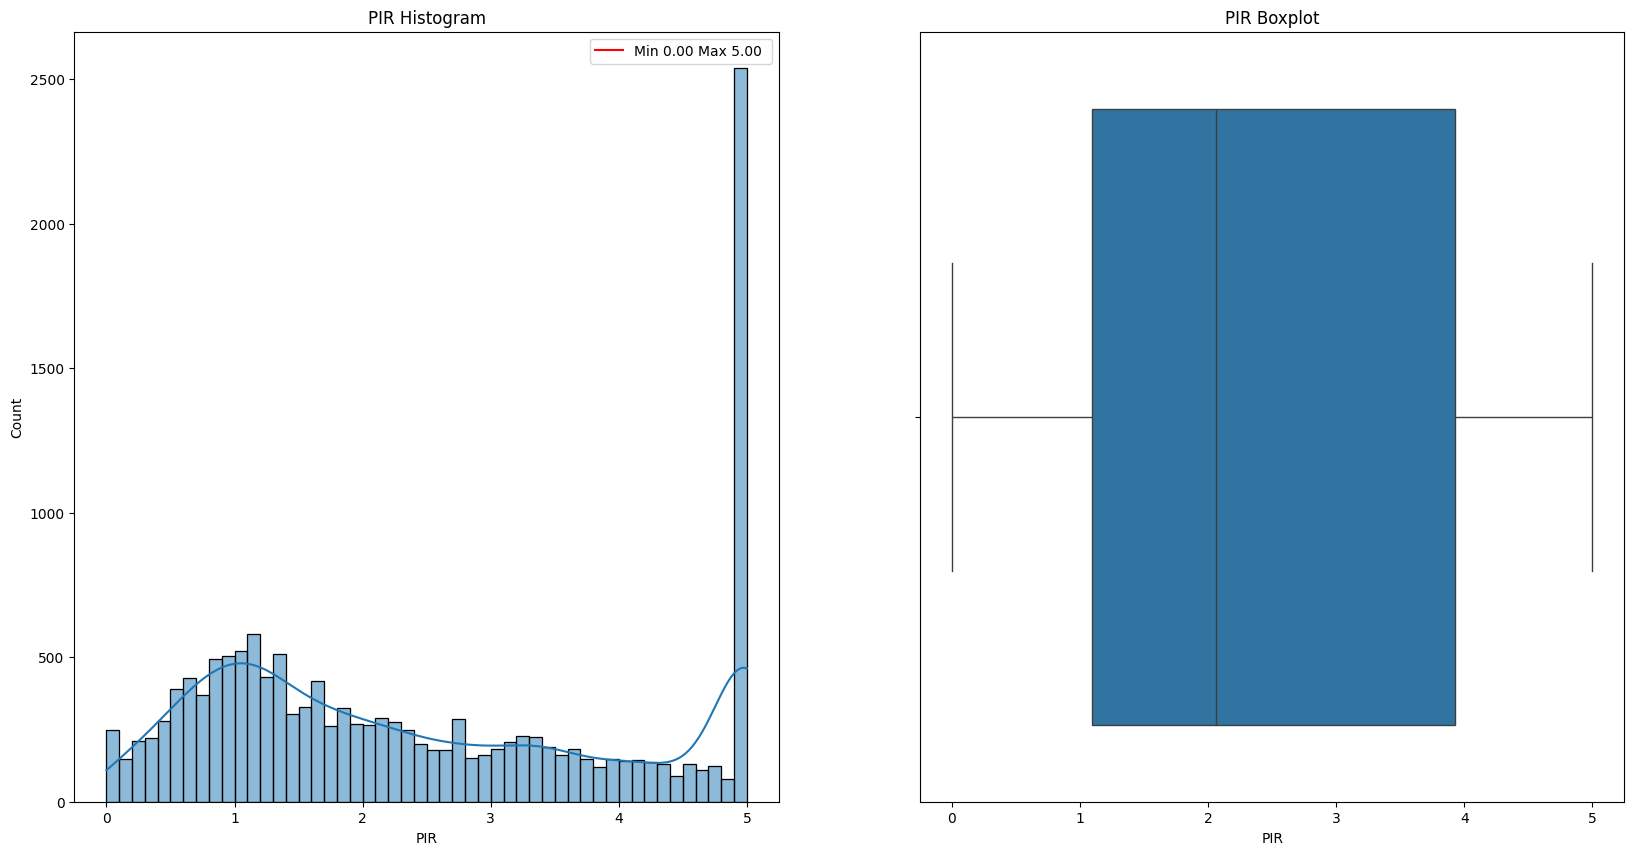

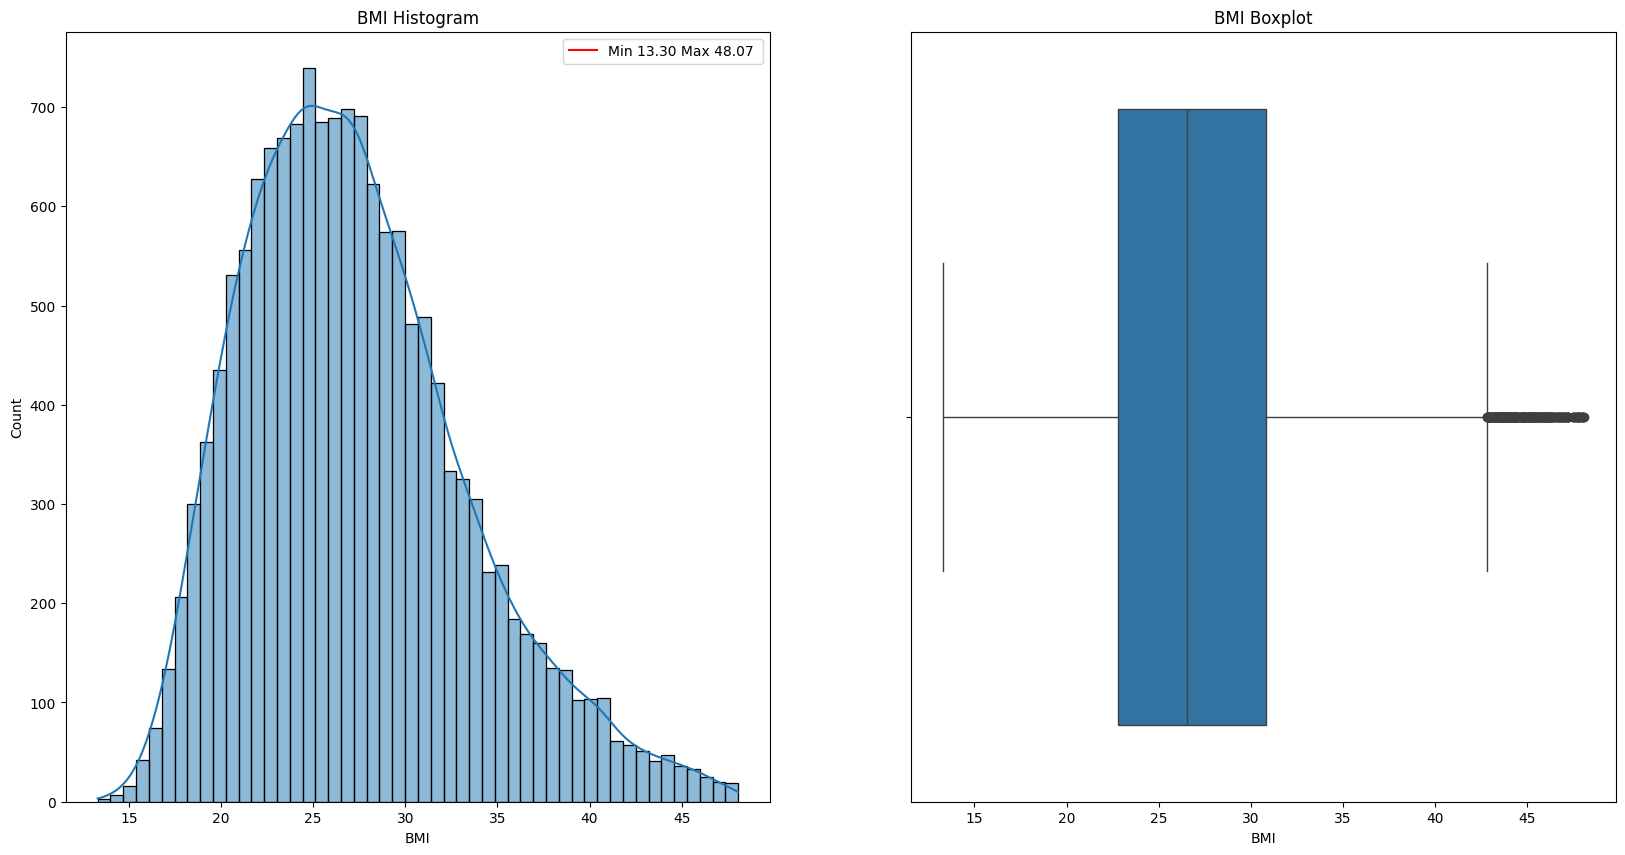

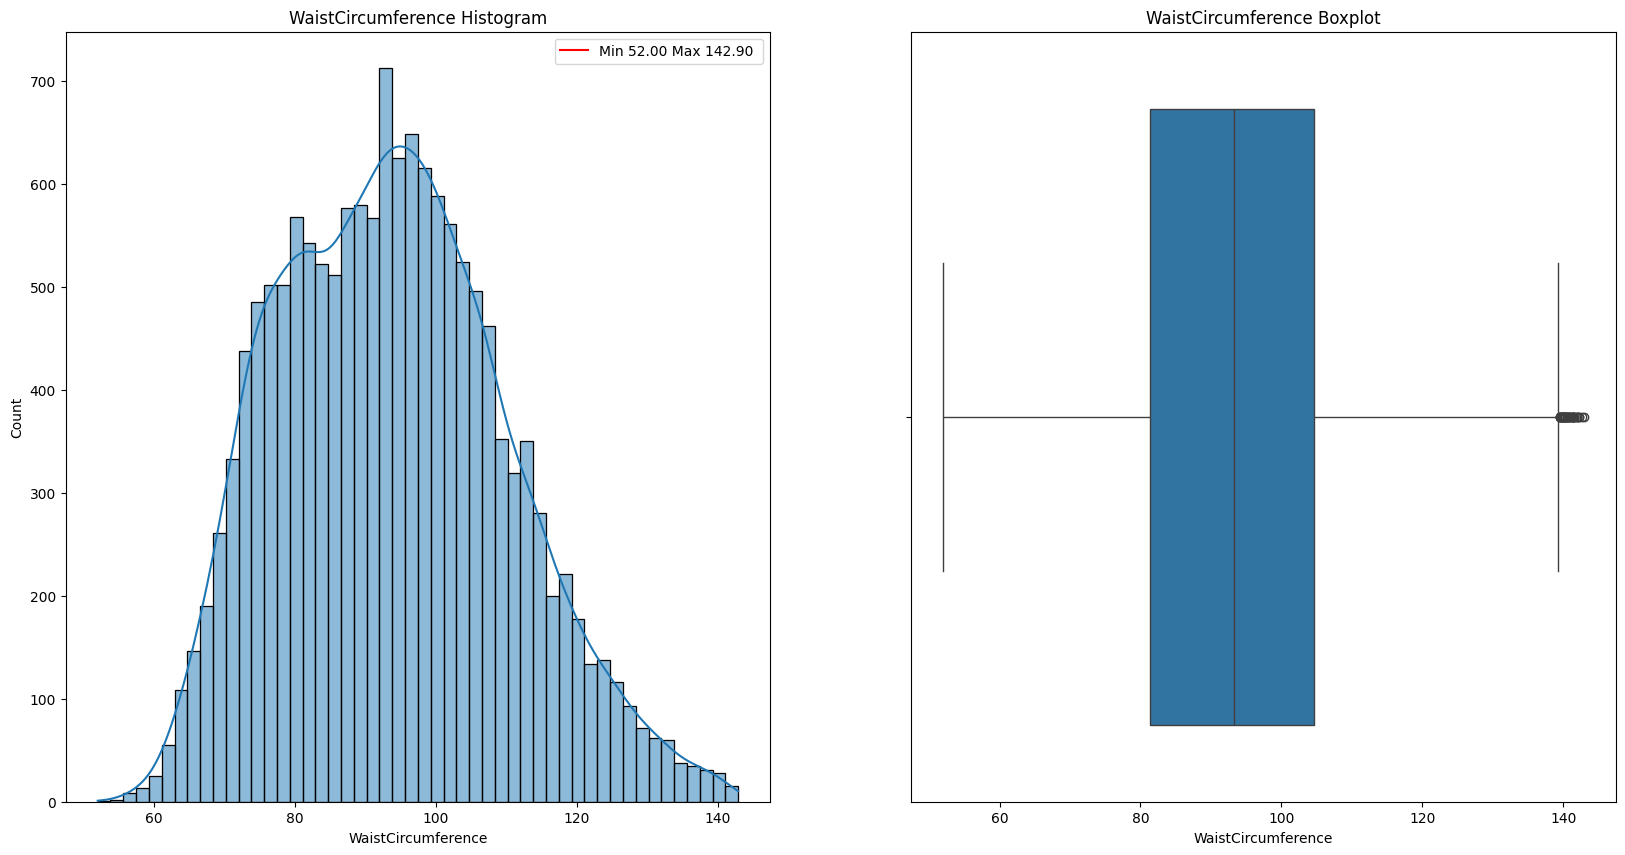

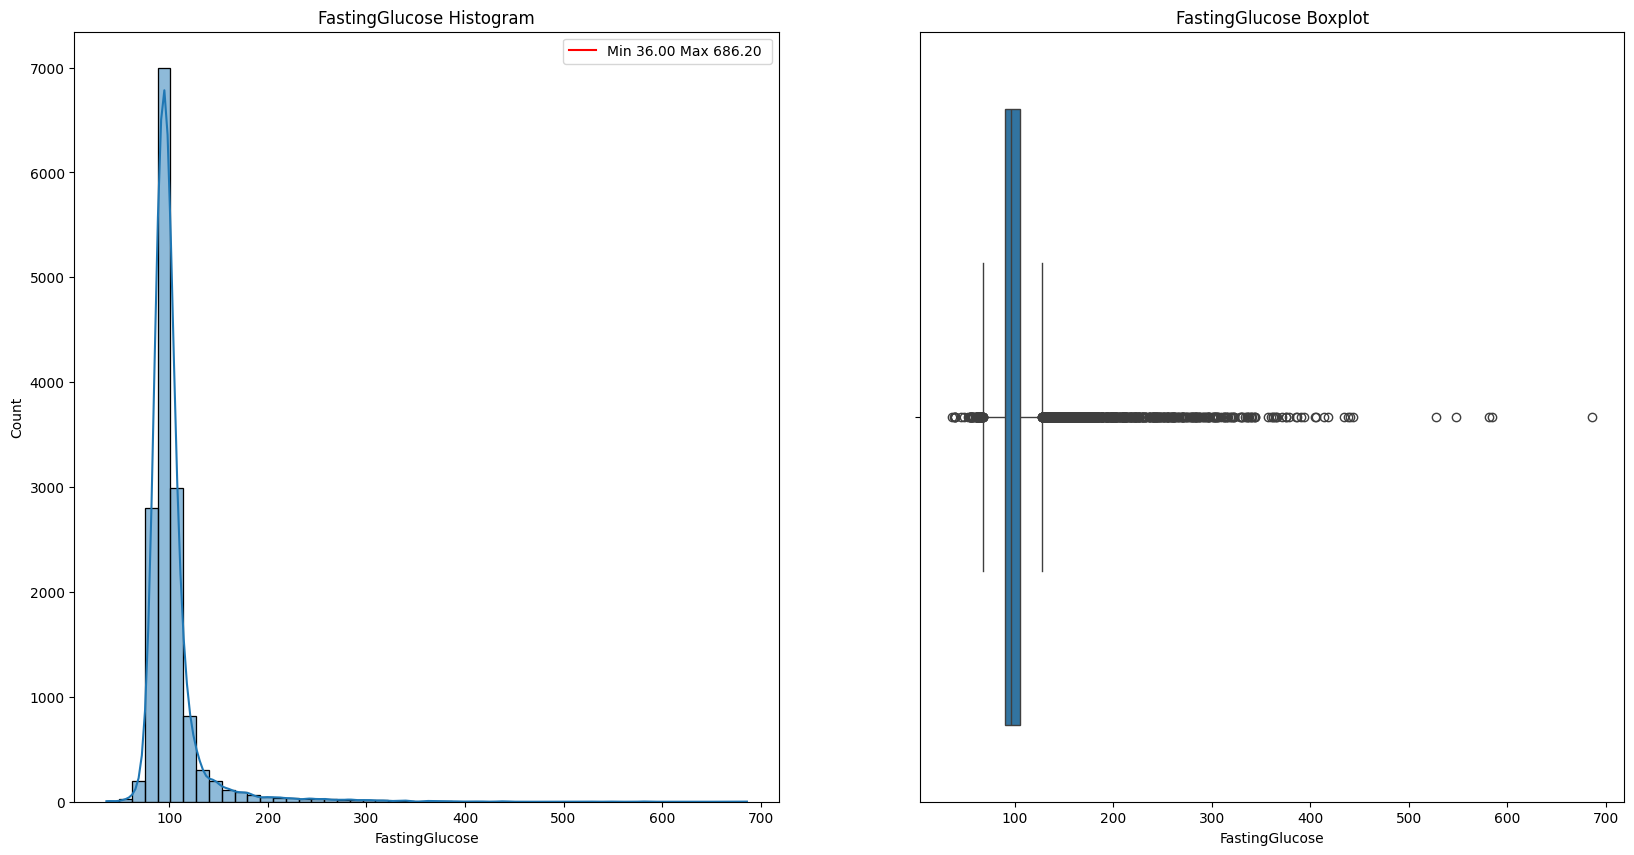

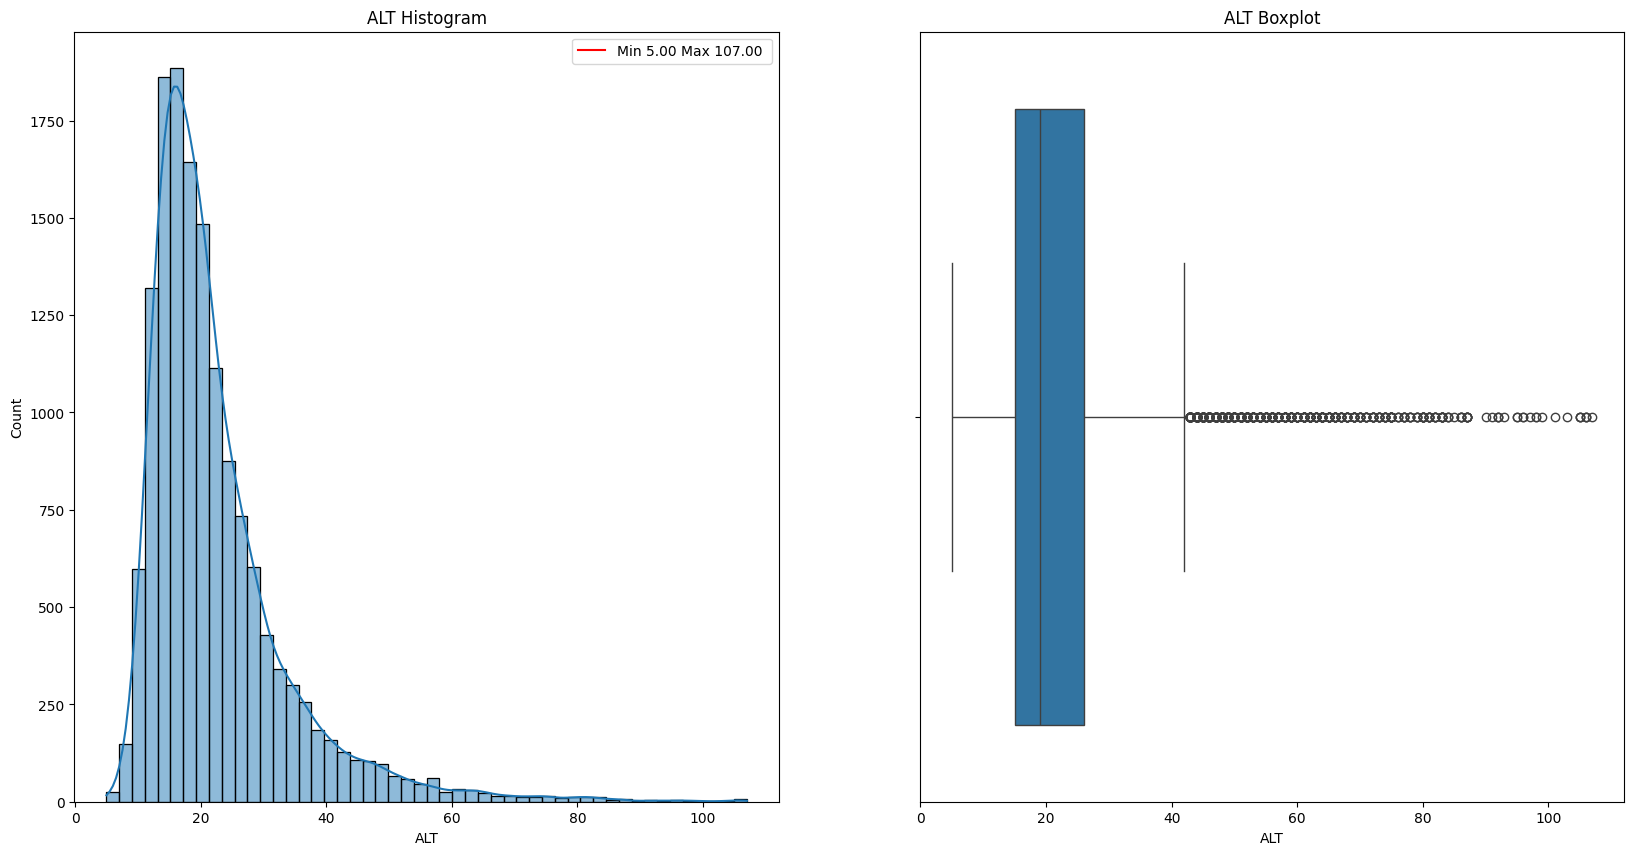

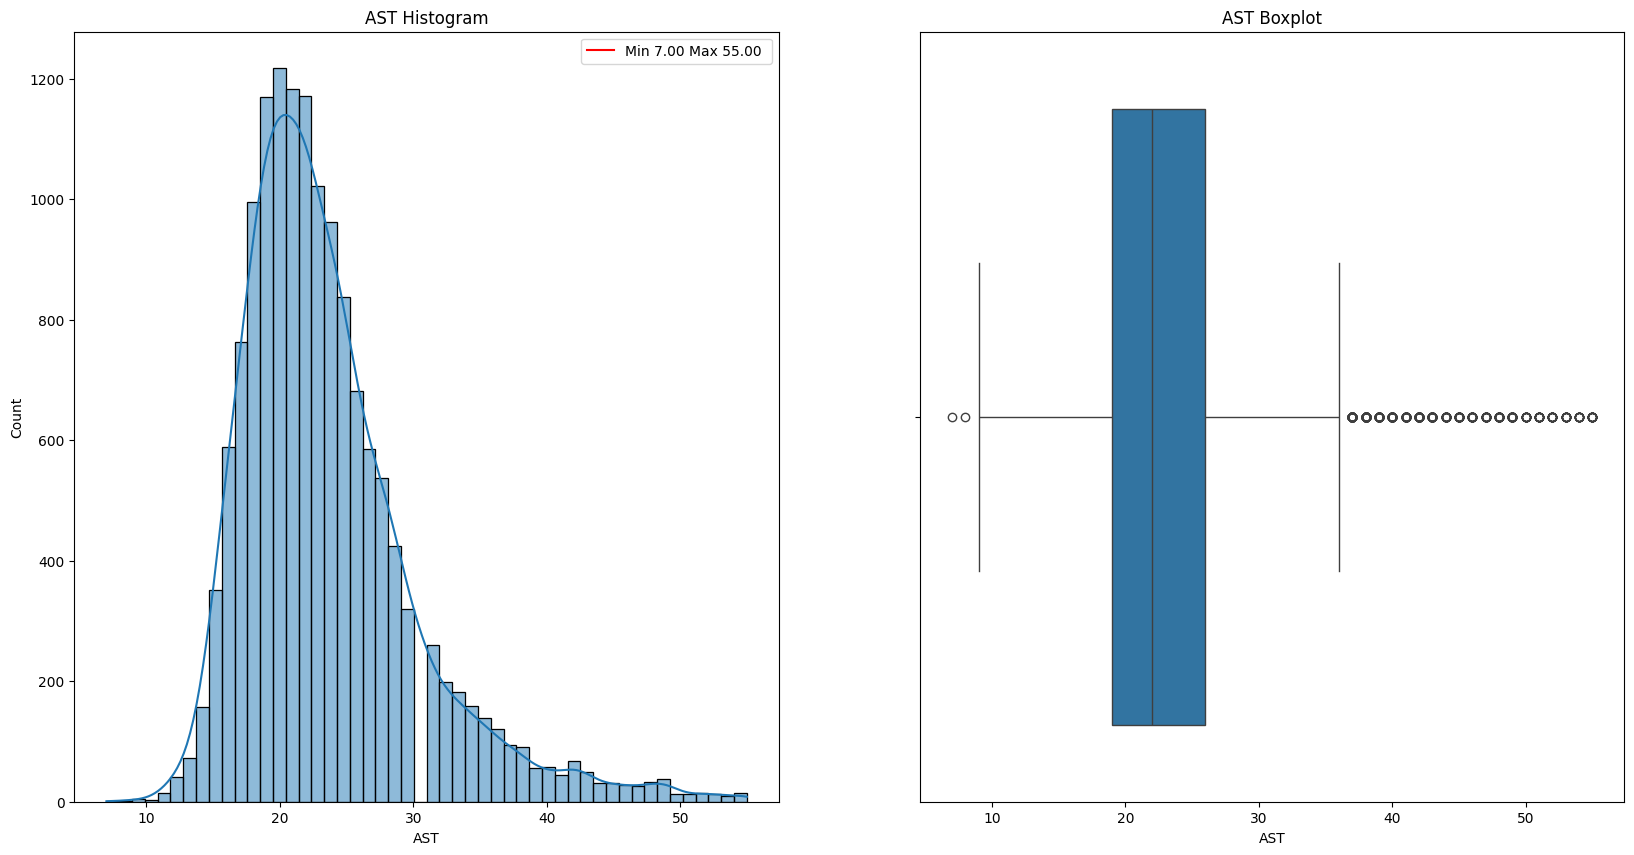

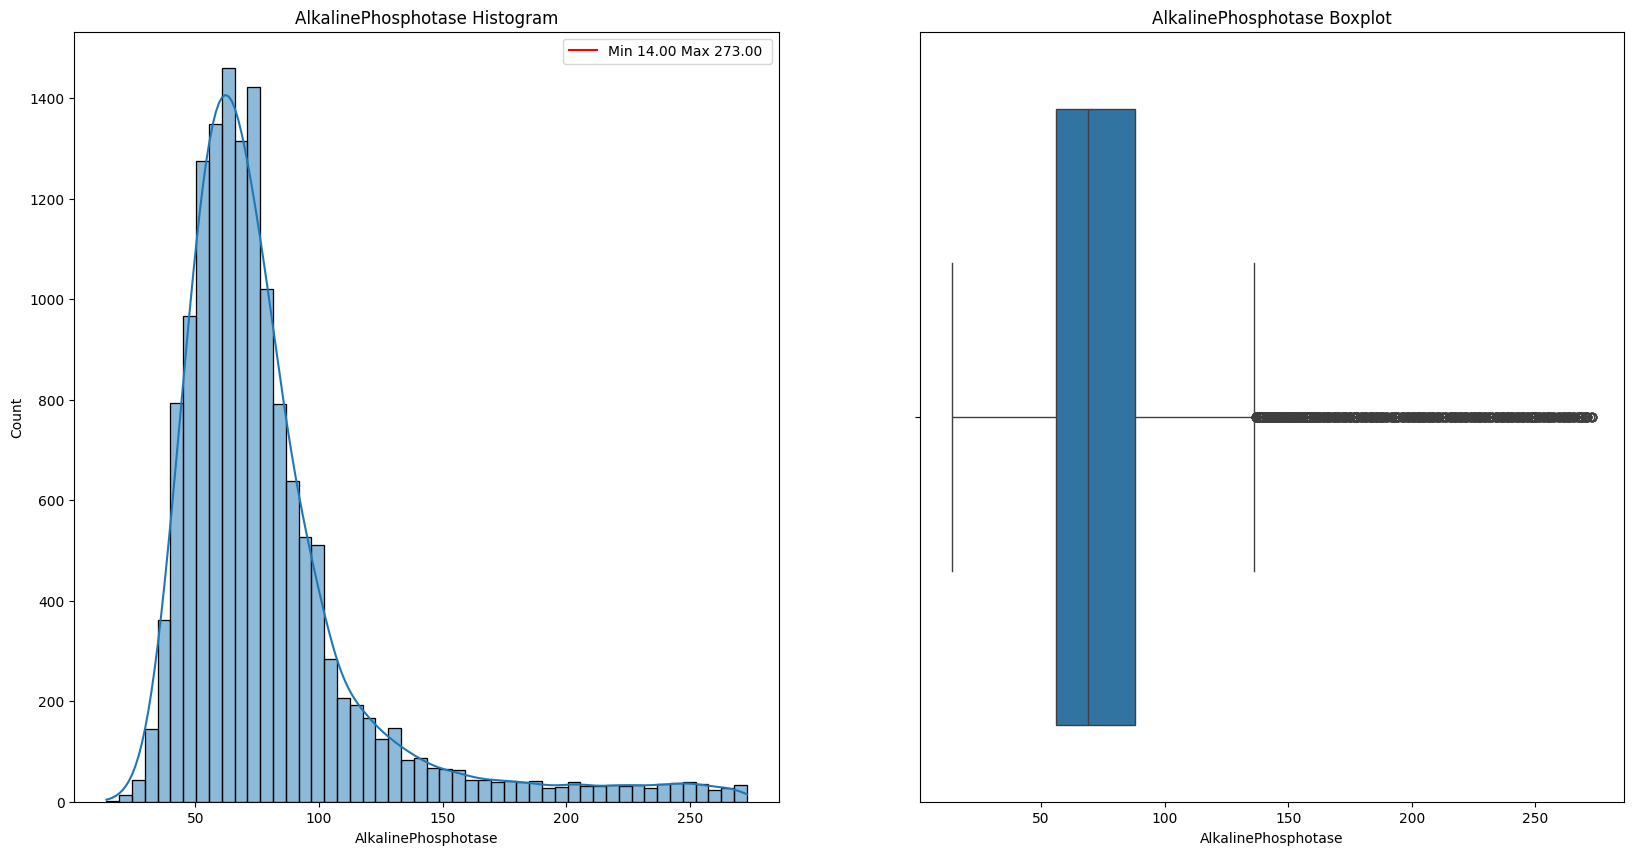

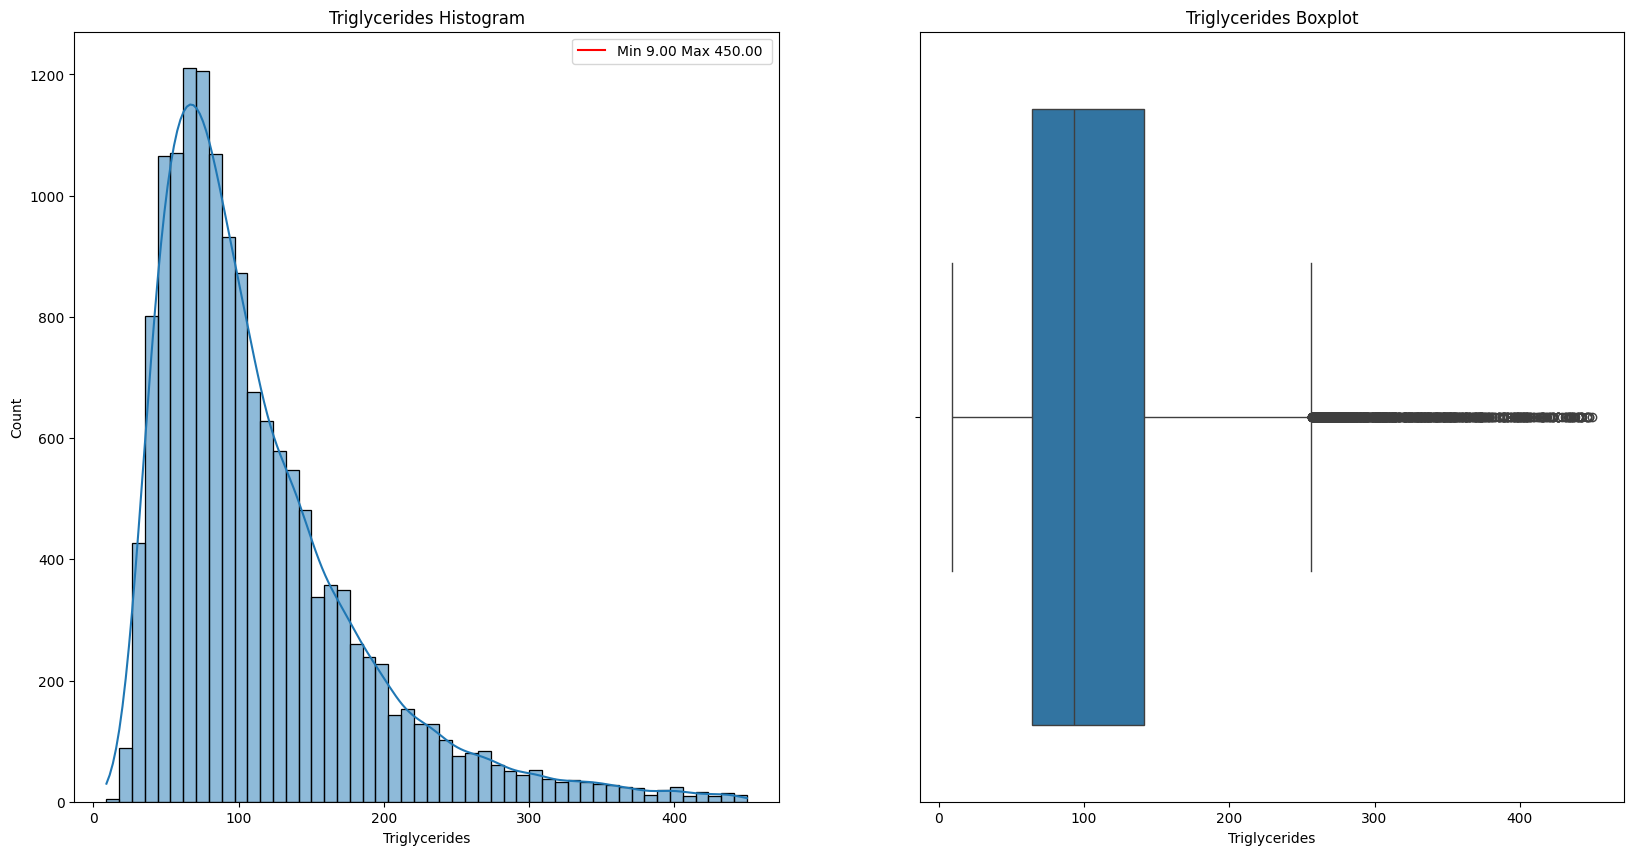

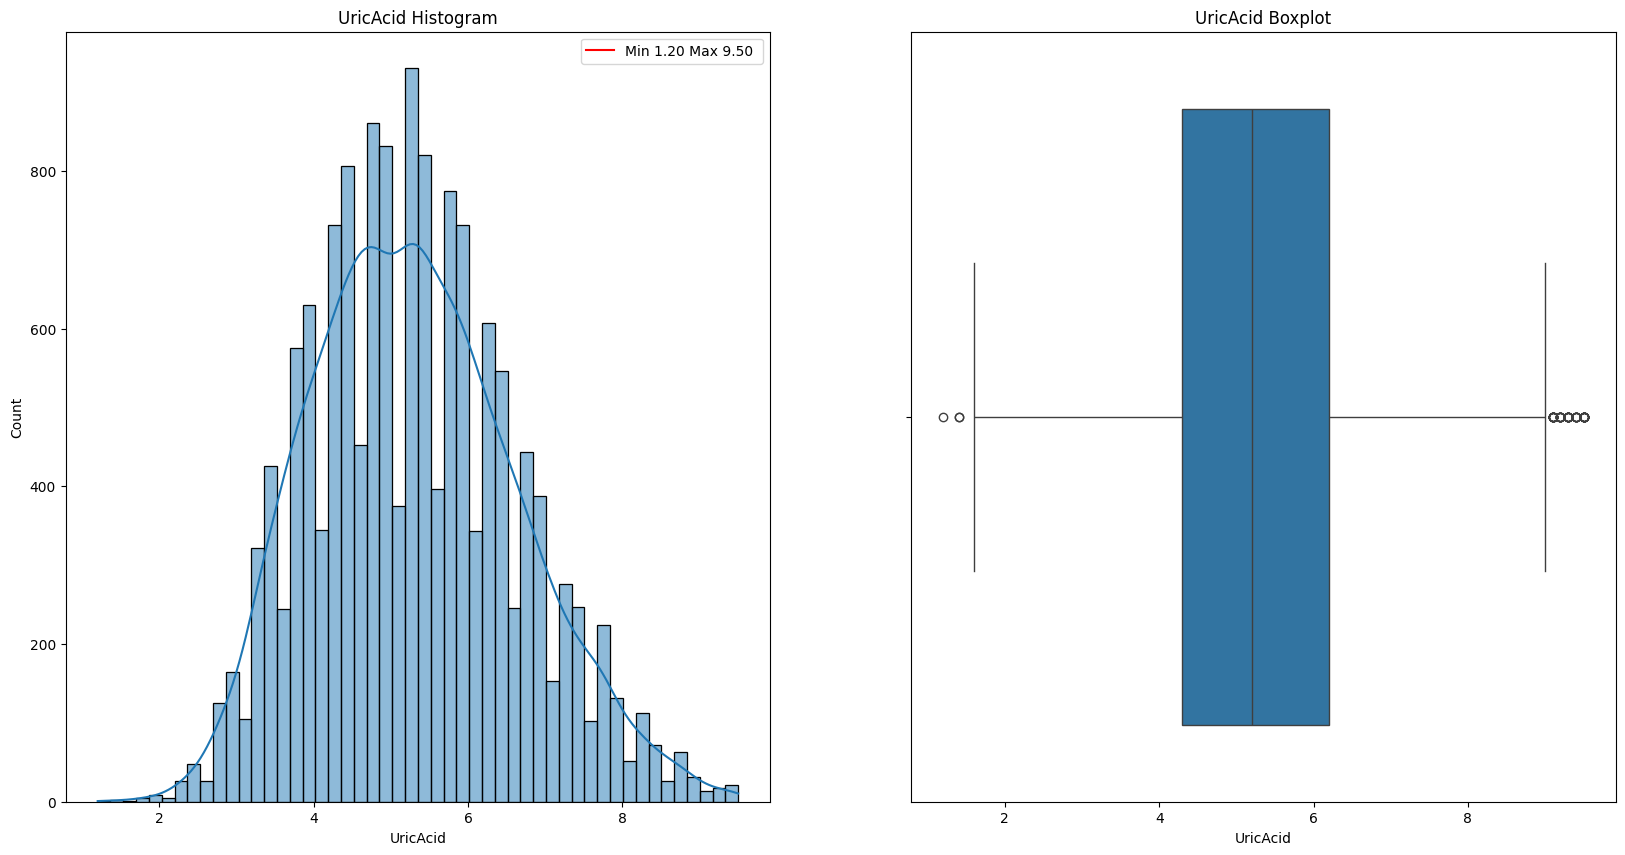

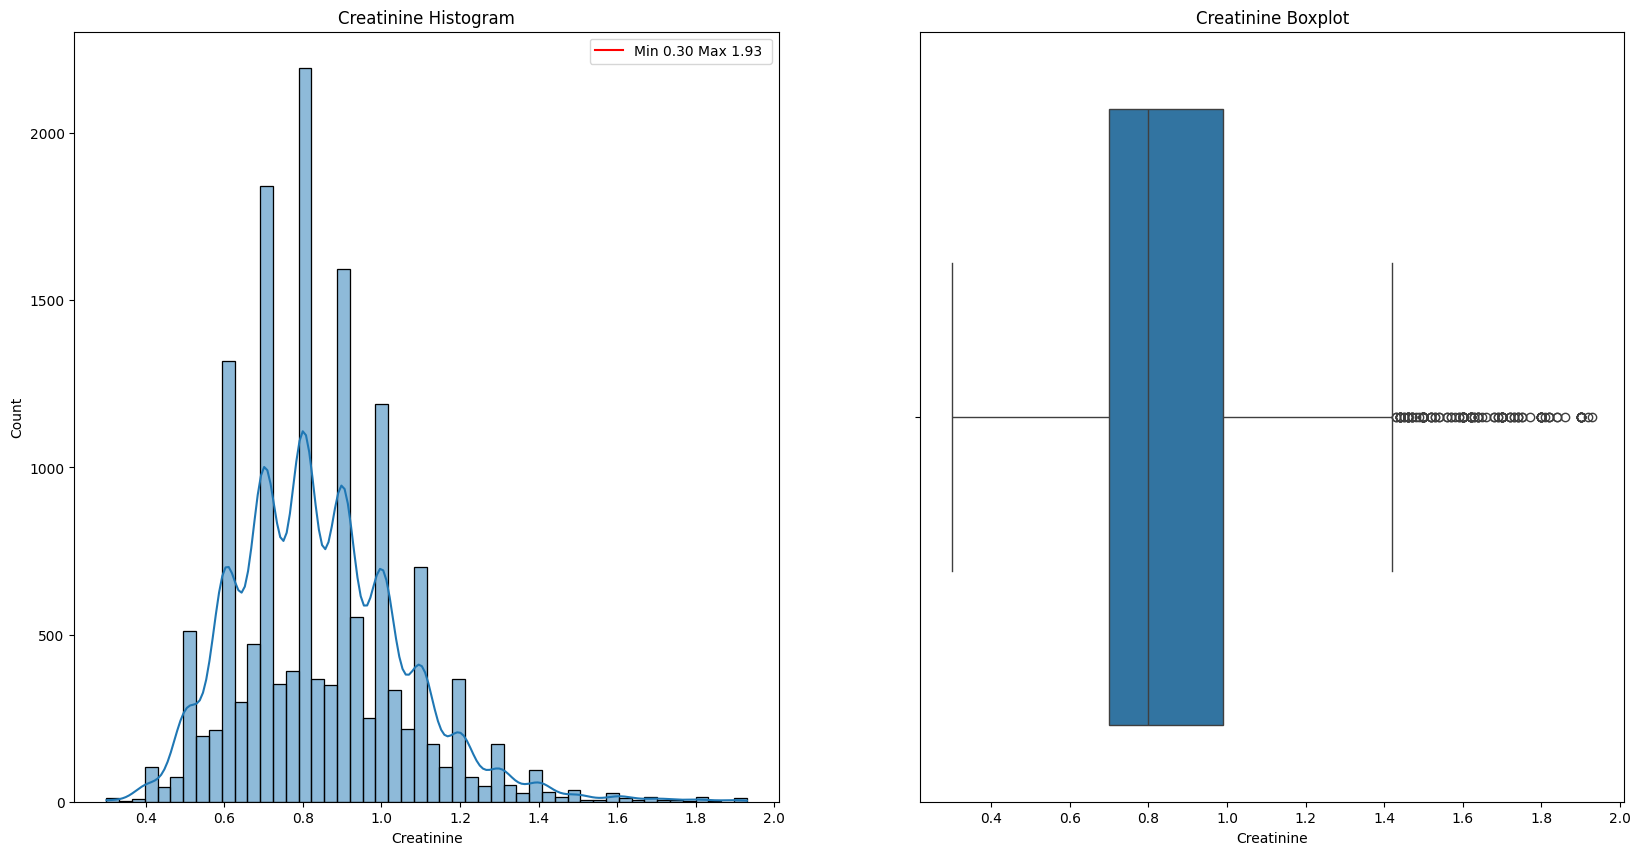

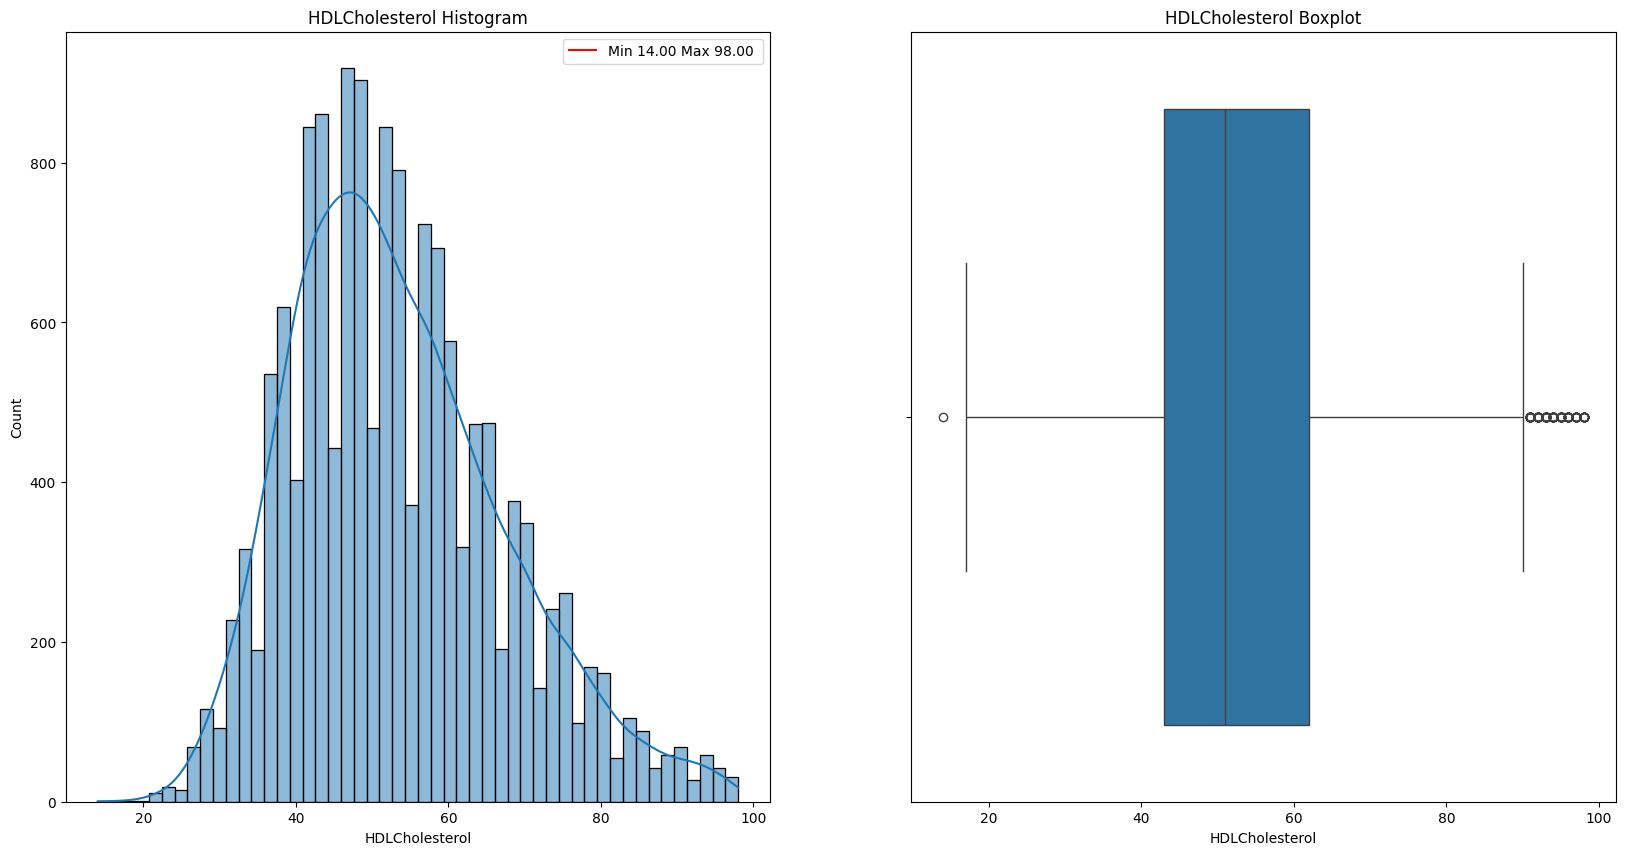

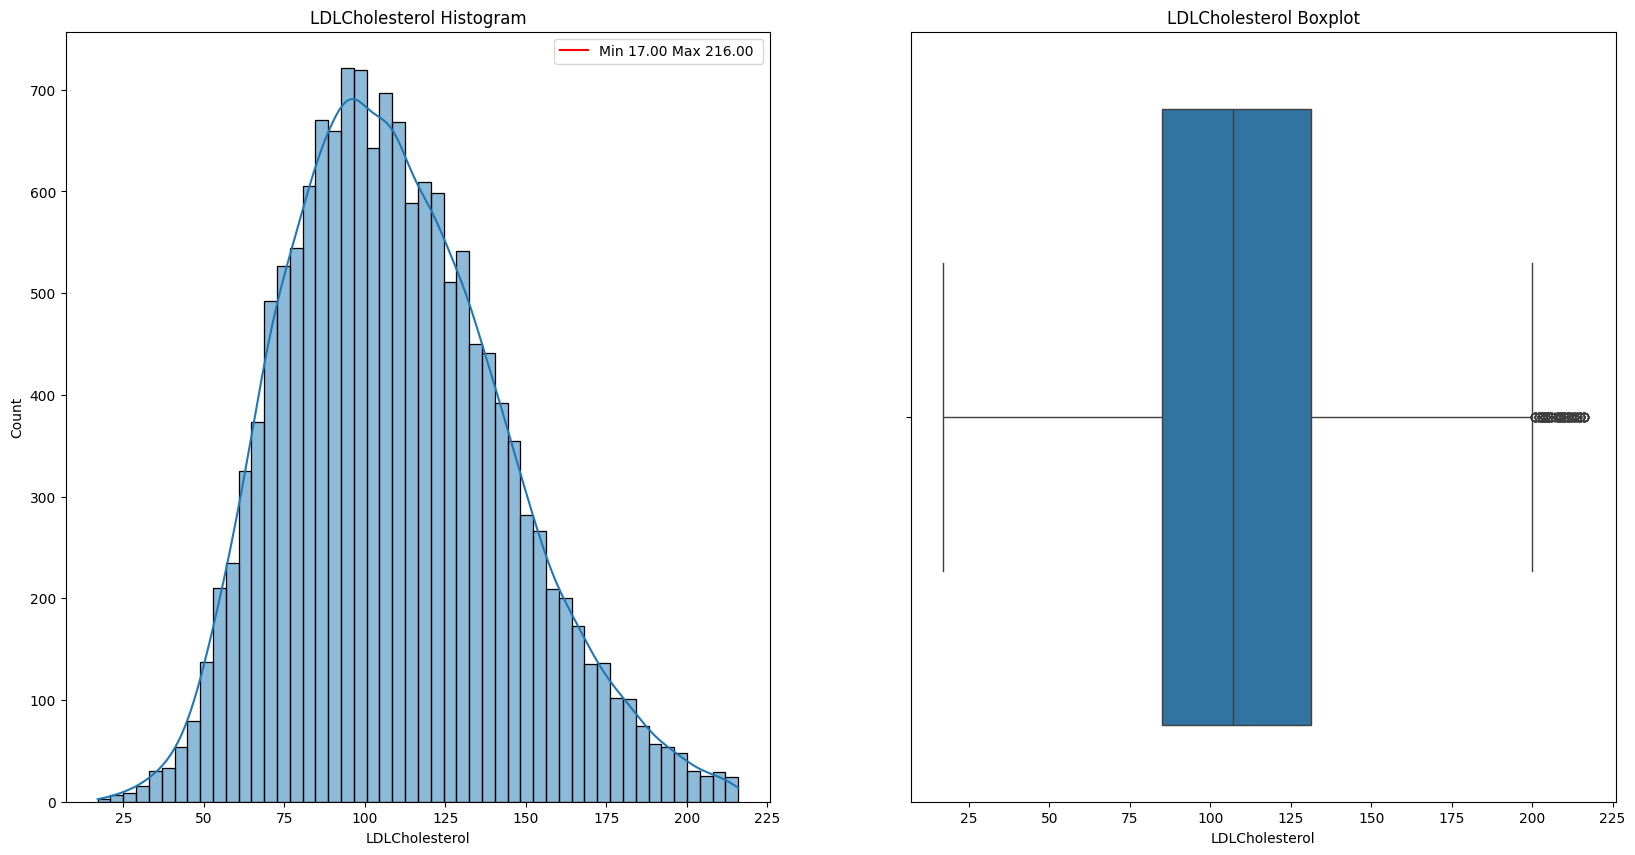

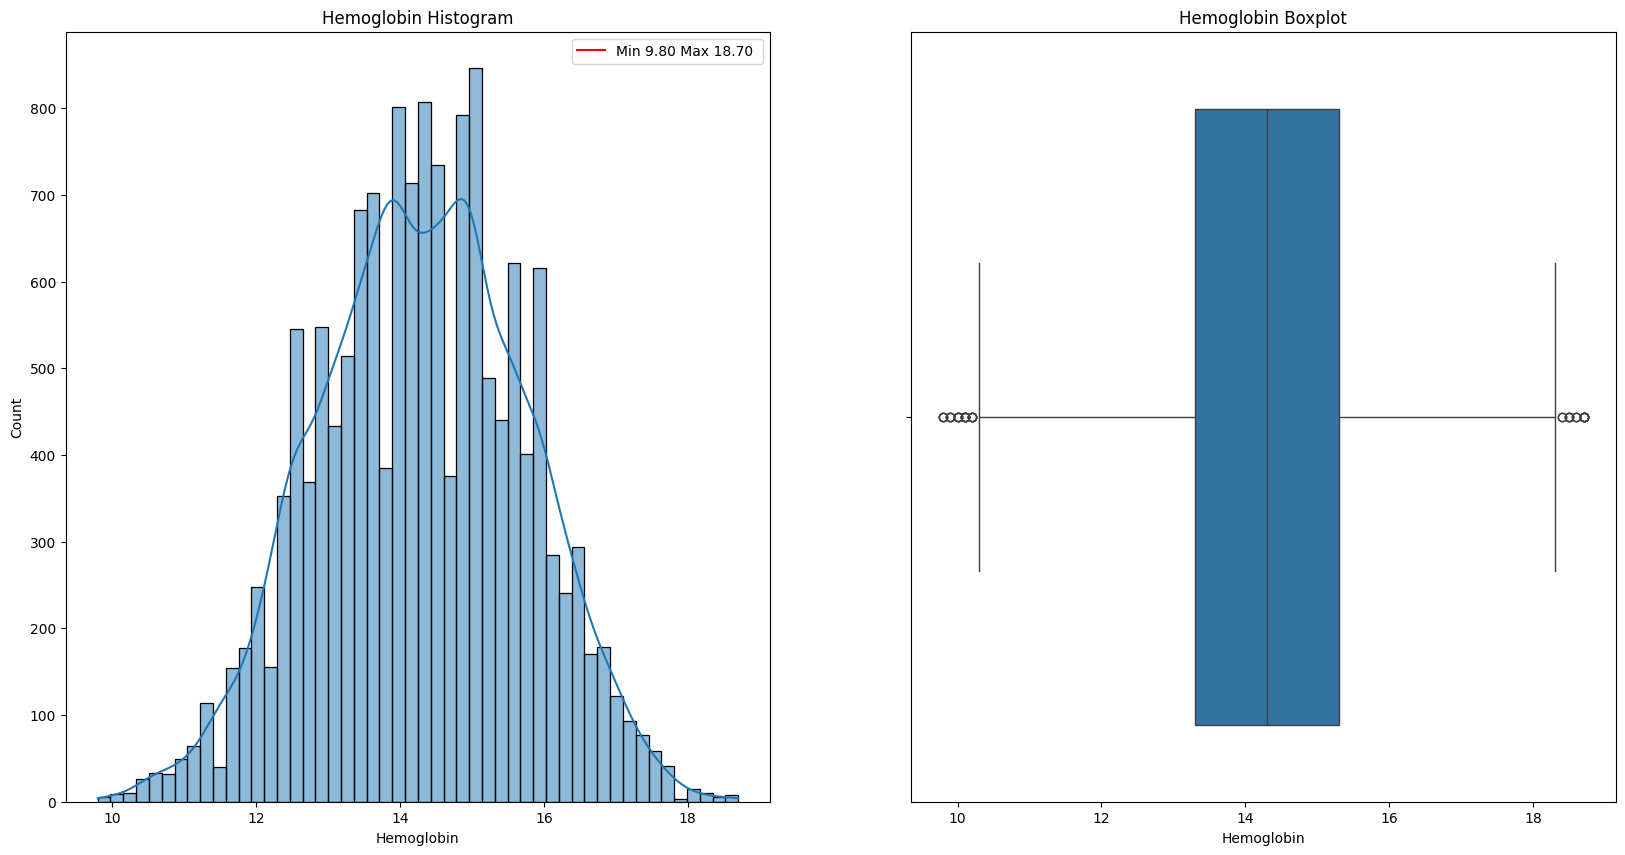

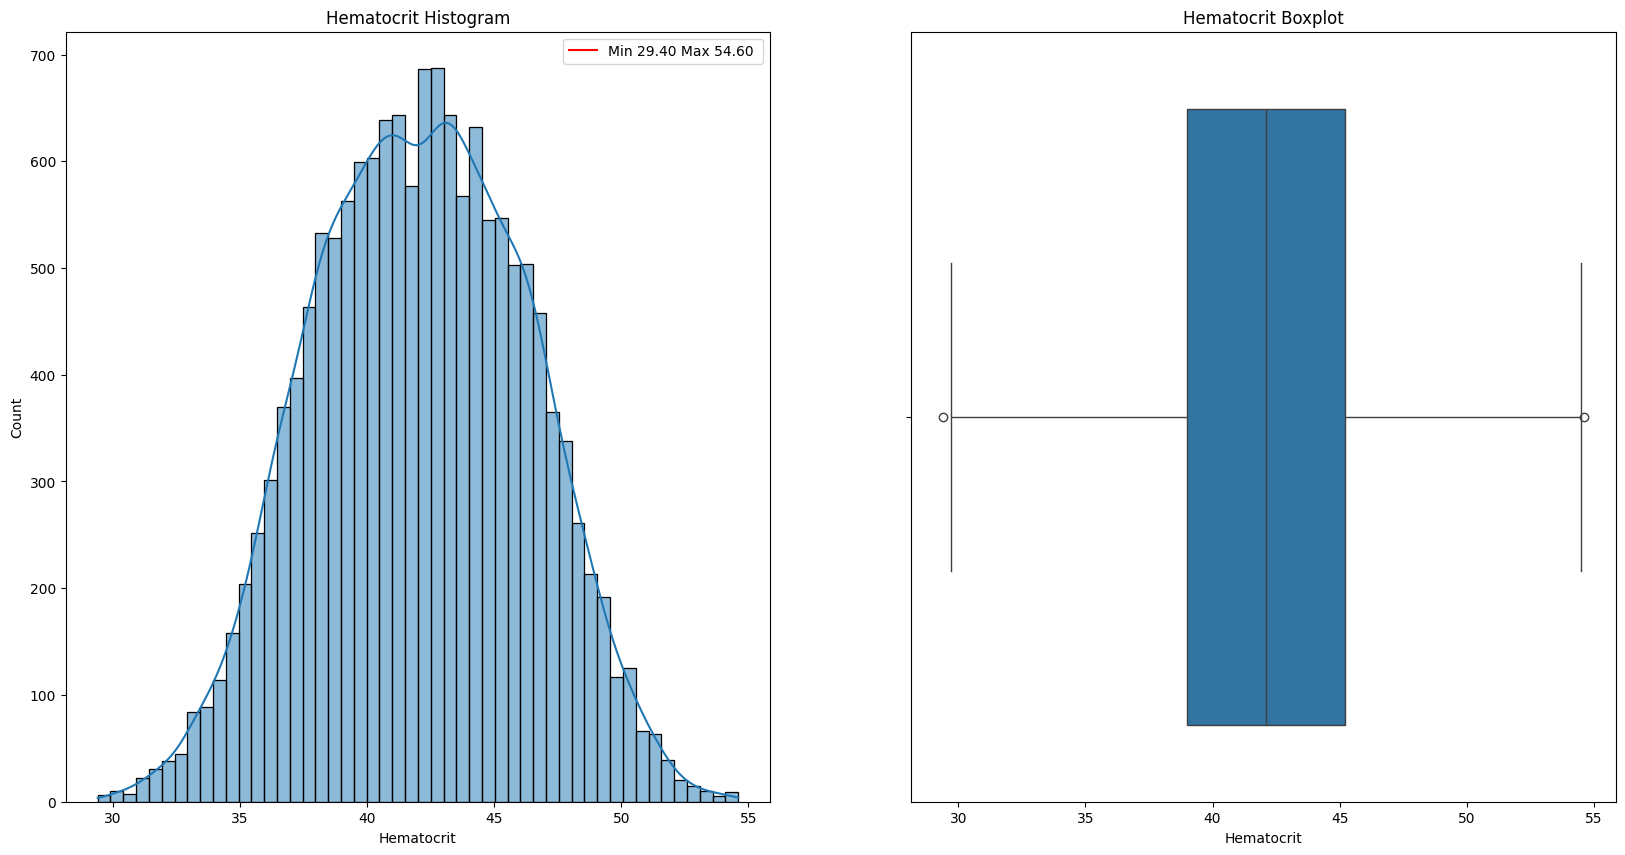

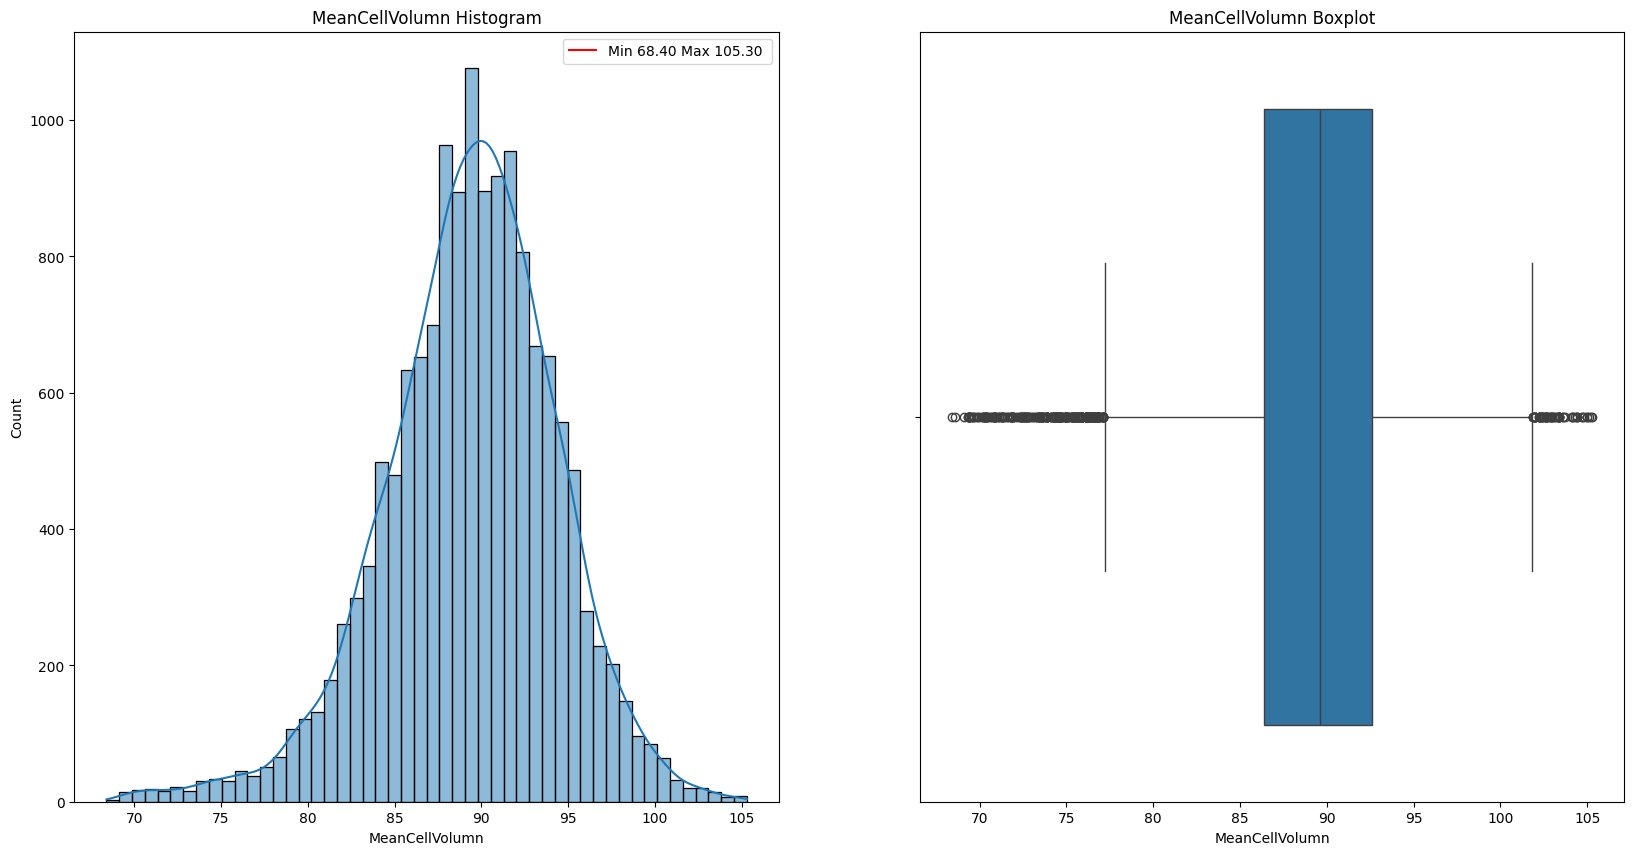

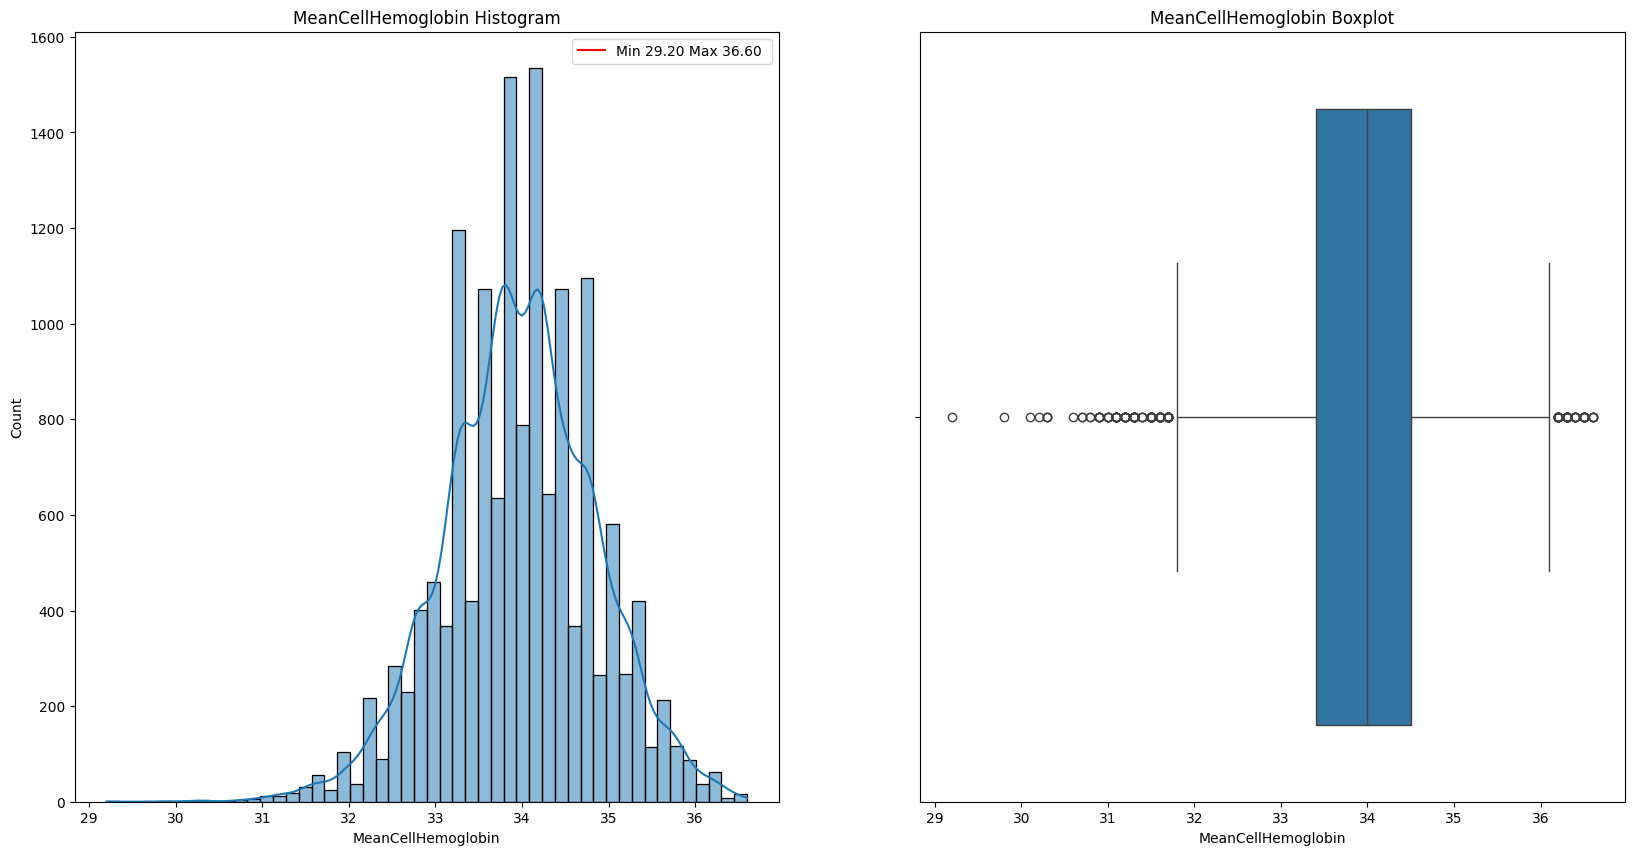

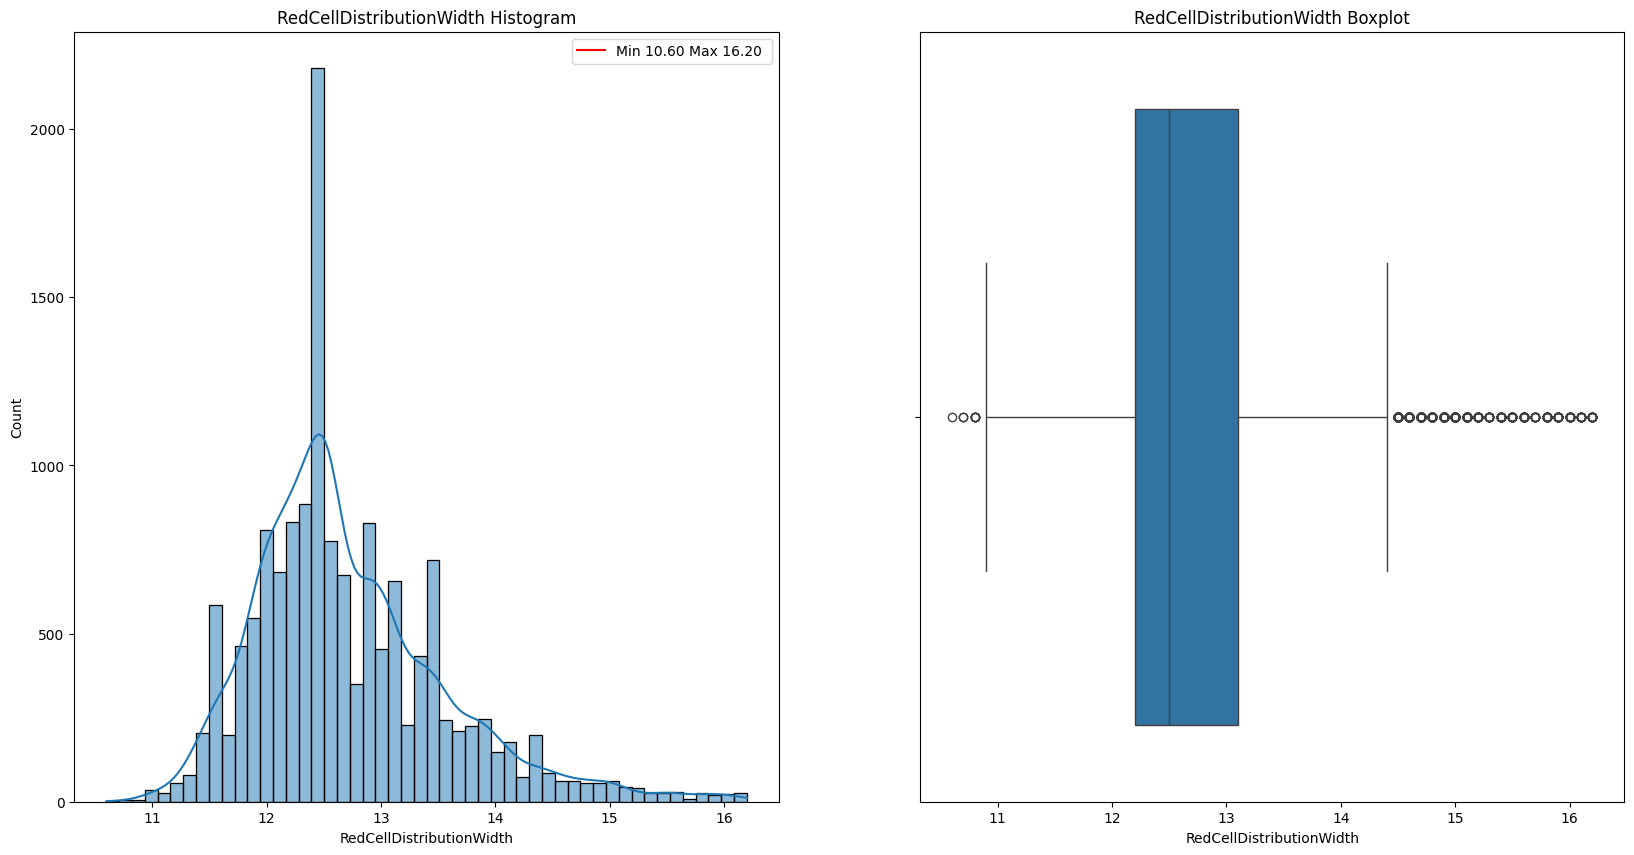

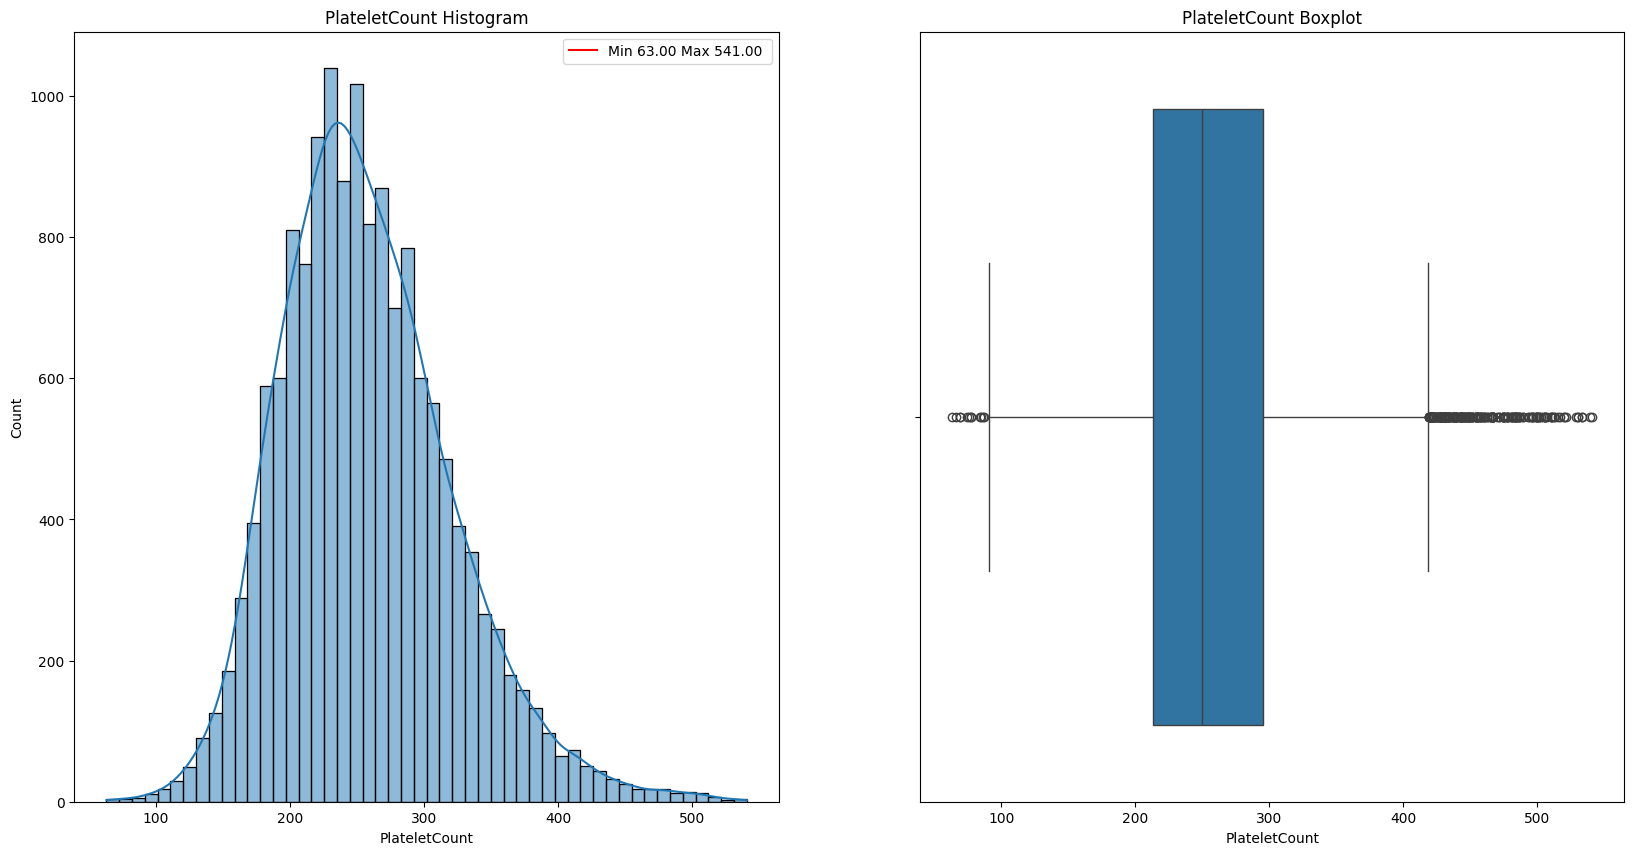

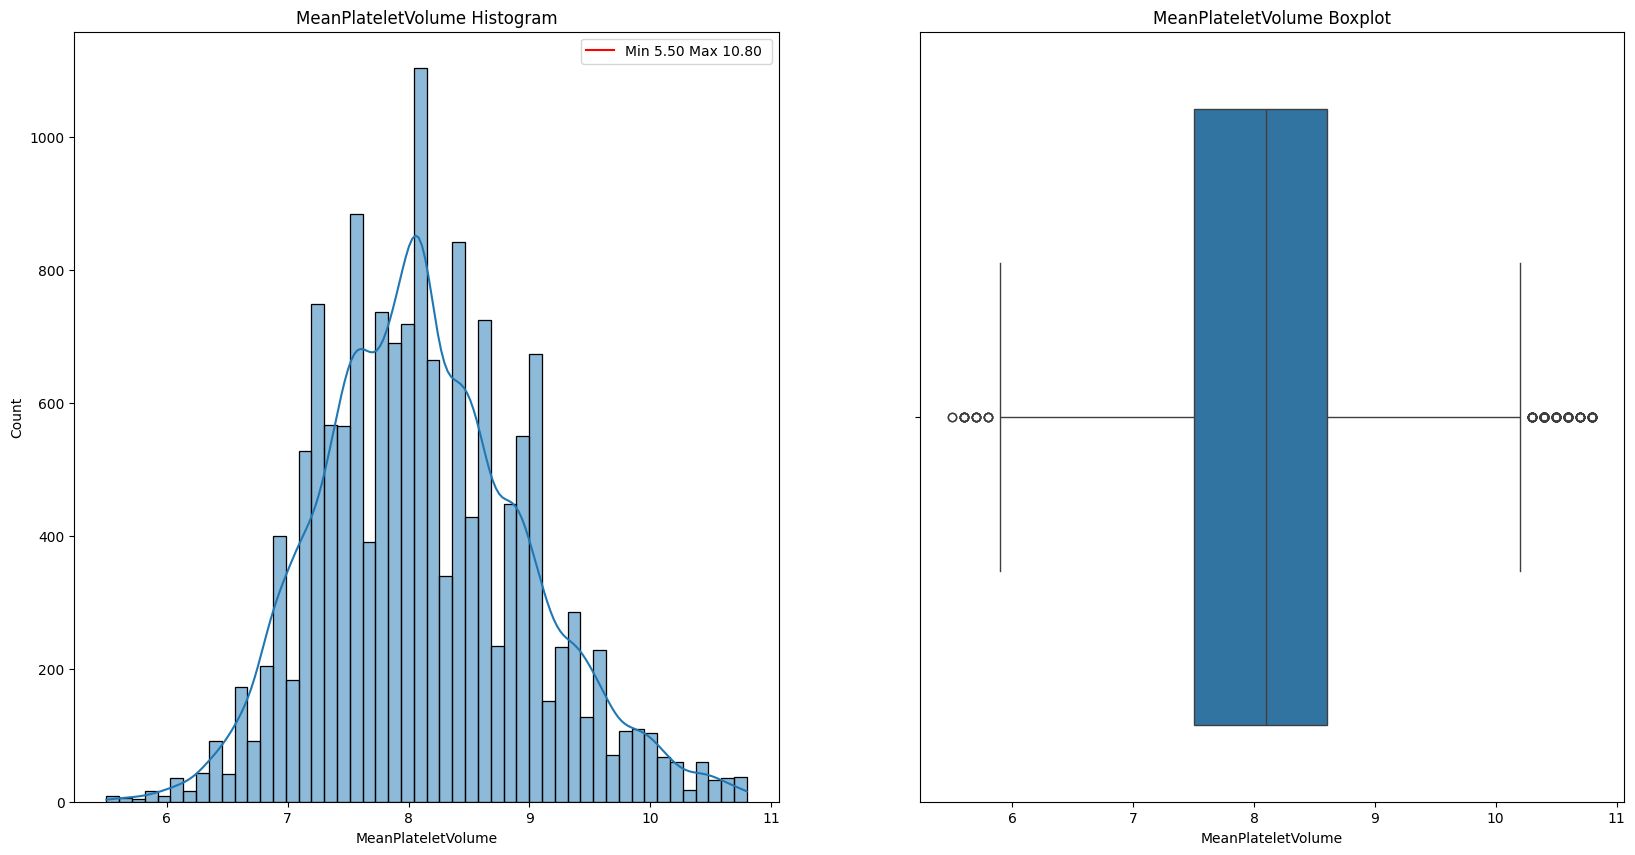

In [13]:
#revisuallize clean data
df_scaled = df_train.copy()
df_scaled.drop(columns=category_columns, inplace=True)

for col in df_scaled.columns:
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    sns.histplot(df_scaled[col], bins=50, kde=True)
    plt.plot([], [], label = f"Min {df_scaled[col].min():.2f} Max {df_scaled[col].max():.2f} ", color='red')
    plt.legend()
    plt.title(f"{col} Histogram")

    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_scaled[col])
    plt.title(f"{col} Boxplot")

    plt.show()


## Model training and evaluation

In [8]:
unuseful_features = ['WaistCircumference','AST','ALT','AlkalinePhosphotase','UricAcid','LDLCholesterol','Hematocrit','MeanCellHemoglobin','PlateletCount', 'MeanPlateletVolume','familysize']

In [9]:
df_train.drop(columns=unuseful_features,inplace=True)
df_test = df_test[df_train.columns]

In [10]:
df_train.columns

Index(['Gender', 'Age', 'Race', 'PIR', 'BMI', 'FastingGlucose',
       'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin',
       'MeanCellVolumn', 'RedCellDistributionWidth', 'SmokeFam',
       'milk_consumption', 'label'],
      dtype='object')

In [11]:
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency

# Giả sử bạn đã có DataFrame tên là df_train
categorical_features = ['Gender', 'Race', 'SmokeFam', 'milk_consumption']
continuous_features = [
    'Age', 'BMI', 'FastingGlucose', 'PIR',
    'Triglycerides', 'Creatinine', 'HDLCholesterol',
    'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth'
]

results = []

# Thay ANOVA bằng t-test cho biến liên tục
for feature in continuous_features:
    group0 = df_train[df_train['label'] == 0][feature].dropna()
    group1 = df_train[df_train['label'] == 1][feature].dropna()
    stat, p = ttest_ind(group0, group1, equal_var=False)  # sử dụng Welch's t-test (không giả định phương sai bằng nhau)
    results.append({
        'Feature': feature,
        'Type': 'Continuous',
        'Test': 't-test',
        'p-value': p
    })

# Chi-square cho biến phân loại (giữ nguyên)
for feature in categorical_features:
    contingency_table = pd.crosstab(df_train[feature], df_train['label'])
    stat, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        'Feature': feature,
        'Type': 'Categorical',
        'Test': 'Chi-square',
        'p-value': p
    })

results_df = pd.DataFrame(results)
print(results_df.sort_values('p-value'))

                     Feature         Type        Test       p-value
11                      Race  Categorical  Chi-square  0.000000e+00
13          milk_consumption  Categorical  Chi-square  1.827201e-69
8             MeanCellVolumn   Continuous      t-test  2.421726e-40
1                        BMI   Continuous      t-test  1.011394e-39
3                        PIR   Continuous      t-test  1.903272e-39
9   RedCellDistributionWidth   Continuous      t-test  1.926490e-37
7                 Hemoglobin   Continuous      t-test  9.547881e-31
0                        Age   Continuous      t-test  4.768730e-16
4              Triglycerides   Continuous      t-test  3.551075e-15
2             FastingGlucose   Continuous      t-test  1.153412e-08
5                 Creatinine   Continuous      t-test  4.724685e-07
6             HDLCholesterol   Continuous      t-test  8.226090e-05
12                  SmokeFam  Categorical  Chi-square  1.653734e-03
10                    Gender  Categorical  Chi-s

['Age', 'PIR', 'BMI', 'FastingGlucose', 'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth']
['Gender', 'Race', 'milk_consumption', 'SmokeFam']

🚀 Training and Evaluating: RandomForest
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84      5380
         1.0       0.52      0.43      0.47      1788

    accuracy                           0.76      7168
   macro avg       0.67      0.65      0.66      7168
weighted avg       0.74      0.76      0.75      7168



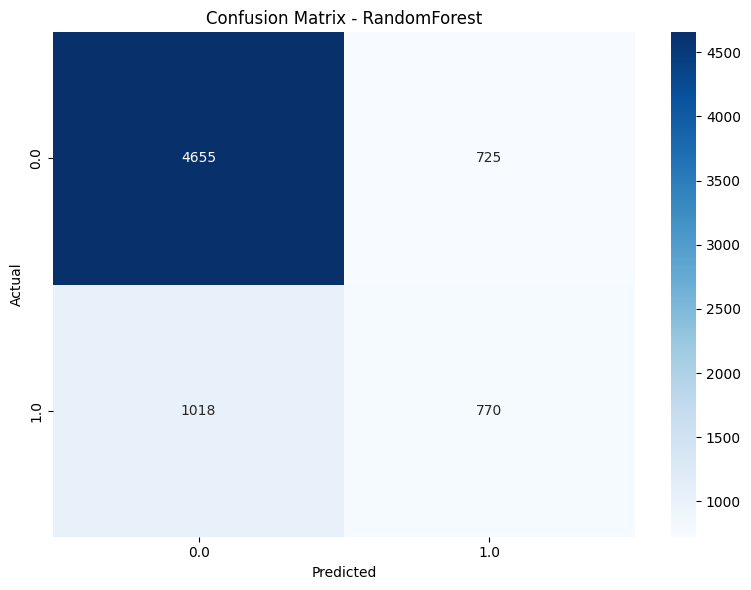


🚀 Training and Evaluating: AdaBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78      5380
         1.0       0.43      0.62      0.51      1788

    accuracy                           0.70      7168
   macro avg       0.64      0.67      0.64      7168
weighted avg       0.75      0.70      0.71      7168



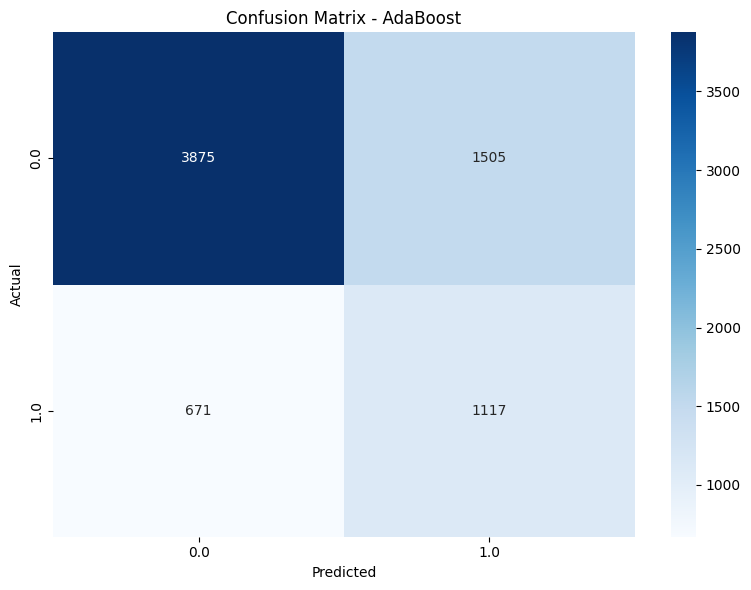


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 8069, number of negative: 8069
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002940 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 16138, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85      5380
         1.0       0.53      0.51      0.52      1788

    accuracy                           0.77      7168
   macro avg       0.69      0.68      0.68      7168
weighted avg       0.76      0.77      0.76      7168



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


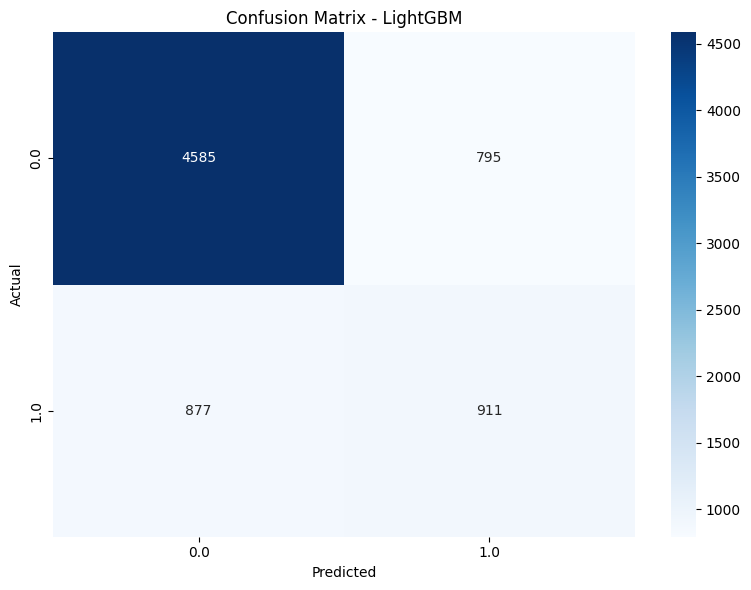


🚀 Training and Evaluating: SVM
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.77      0.79      5380
         1.0       0.42      0.51      0.46      1788

    accuracy                           0.70      7168
   macro avg       0.62      0.64      0.63      7168
weighted avg       0.72      0.70      0.71      7168



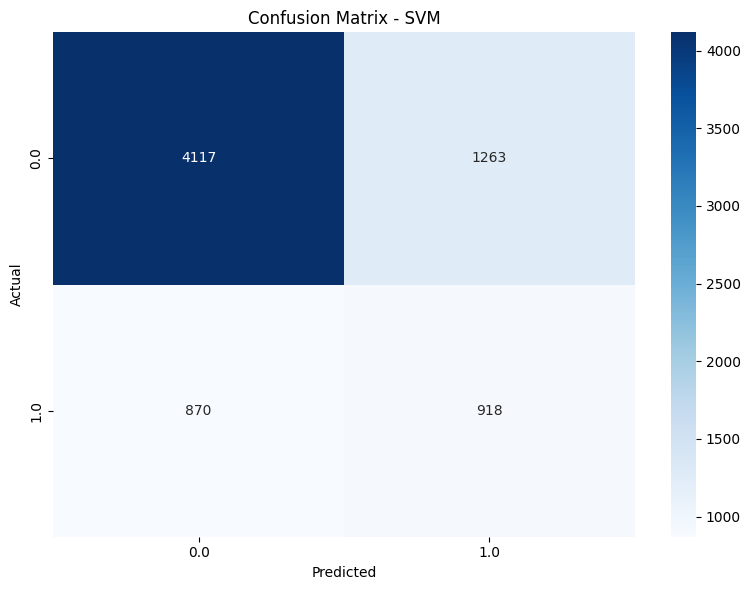

✅ Exported results to model_comparison_results.csv


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
df = pd.concat([df_train,df_test])

X = df.drop(columns=['label'])
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Identify categorical and numeric columns
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']
print(numeric_cols)
print(categorical_cols)
# 5. Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# 6. Define models
models_to_test = {
    # 'XGBoost': XGBClassifier(
    #     colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
    #     n_estimators=50, subsample=1.0, use_label_encoder=False,
    #     eval_metric='mlogloss', random_state=42
    # ),
    # 'ElasticNetLogistic': LogisticRegression(
    #     penalty='elasticnet', solver='saga', max_iter=1000,
    #     random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    # ),
    'RandomForest': RandomForestClassifier(
                                            n_estimators=300,        # more trees → more stable results
                                            max_depth=None,          # let trees grow fully (can tune to avoid overfitting)
                                            min_samples_split=2,     # default, fine for most cases
                                            min_samples_leaf=1,      # default, fine for most cases
                                            max_features='sqrt',     # best practice for classification
                                            bootstrap=True,          # enable bagging
                                            random_state=42,
                                            n_jobs=-1                # use all CPU cores
                                            ),
    'AdaBoost': AdaBoostClassifier(
                                    random_state=42
                                    ),
    'LightGBM': LGBMClassifier( 
                                n_estimators=100,
                                learning_rate=0.05,
                                random_state=42,
                                ),
    'SVM': SVC(
                kernel='rbf',
                C=10,                   # stronger regularization (smaller C) or weaker (larger C)
                gamma='scale',          # adaptive to data
                probability=True,
                random_state=42
            )

}


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    
    # Predict proba for AUC
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # Collect scores
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    # Save result
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Optional: show classification report and confusion matrix
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Export to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results.csv", index=False)
print("✅ Exported results to model_comparison_results.csv")

In [42]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from lightgbm import LGBMClassifier
from pytorch_tabnet.tab_model import TabNetClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, SMOTENC

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),  # Changed to 'auto'
    ('classifier', lgbm)
])

# ====== 2) TabNet pipeline with proper categorical handling ======
# Calculate categorical dimensions and indices
cat_dims = [X_train_raw[col].nunique() for col in categorical_cols]
cat_idxs = list(range(len(categorical_cols)))

preprocessor_tabnet = ColumnTransformer(
    transformers=[
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

# SMOTENC for mixed data types
smotenc = SMOTENC(
    categorical_features=cat_idxs,  # Only categorical indices
    sampling_strategy='auto',
    random_state=42
)

tabnet_clf = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5,
    gamma=1.5,
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_independent=2, 
    n_shared=2,
    momentum=0.02,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=0
)

# Function to convert to float32 (required for TabNet)
def to_float32(X):
    return X.astype(np.float32)

float32_transformer = FunctionTransformer(to_float32, validate=False)

tabnet_pipe = ImbPipeline(steps=[
    ('preprocessor_tabnet', preprocessor_tabnet),
    ('smotenc', smotenc),
    ('to_float32', float32_transformer),
    ('classifier', tabnet_clf)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
tabnet_wrapped = ImblearnWrapper(tabnet_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'TabNet': tabnet_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 5) Ensemble methods ======
print("\n🔥 Training Ensemble Models...")

ensemble_models = {
    'Soft Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('tabnet', tabnet_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]
    ),
    'Hard Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('tabnet', tabnet_wrapped)],
        voting='hard'
    ),
    'Stacking': StackingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('tabnet', tabnet_wrapped)],
        final_estimator=LogisticRegression(random_state=42),
        passthrough=False  # Changed to False for stability
    )
}

ensemble_results = []

# for name, model in ensemble_models.items():
#     print(f"\n🚀 Training: {name}")
#     try:
#         model.fit(X_train_raw, y_train)
        
#         y_pred = model.predict(X_test_raw)
#         y_proba = model.predict_proba(X_test_raw)
        
#         # Calculate metrics
#         if len(np.unique(y_test)) == 2:
#             auc = roc_auc_score(y_test, y_proba[:, 1])
#         else:
#             auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
#         precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
#         recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
#         f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
#         accuracy = accuracy_score(y_test, y_pred)
        
#         ensemble_results.append({
#             'Model': name,
#             'Precision (Macro)': precision,
#             'Recall (Macro)': recall,
#             'F1 Score (Macro)': f1,
#             'Accuracy': accuracy,
#             'AUC': auc
#         })
        
#         print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
#         # Plot confusion matrix
#         cm = confusion_matrix(y_test, y_pred)
#         plt.figure(figsize=(6, 5))
#         sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#                     xticklabels=np.unique(y_test),
#                     yticklabels=np.unique(y_test))
#         plt.title(f"Confusion Matrix - {name}")
#         plt.xlabel("Predicted")
#         plt.ylabel("Actual")
#         plt.tight_layout()
#         plt.show()
        
#     except Exception as e:
#         print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    tabnet_proba = individual_models['TabNet'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning
    thresh_lgbm, thresh_tabnet = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (tabnet_proba > thresh_tabnet)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average
    alpha, beta = 0.7, 0.3
    ensemble_proba = alpha * lgbm_proba + beta * tabnet_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules
    y_pred_hybrid = []
    for p_l, p_t in zip(lgbm_proba, tabnet_proba):
        if p_t > 0.7 and p_l > 0.4:
            y_pred_hybrid.append(1)
        elif p_t > 0.8:
            y_pred_hybrid.append(1)
        elif p_l > 0.6:
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results + ensemble_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("lgbm_tabnet_ensemble_results_v2_minority_SMOTE_tabnetsupport.csv", index=False)
print(f"\n✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.7755, F1: 0.6767, AUC: 0.7714

🚀 Training: TabNet


c:\mydata\G8Vitamin\.venv\Lib\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


✅ TabNet - Accuracy: 0.6624, F1: 0.6225, AUC: 0.7246

🔥 Training Ensemble Models...

⚡ Creating Manual Ensembles...


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ Threshold Ensemble - Accuracy: 0.7196, F1: 0.6642
✅ Weighted Average - Accuracy: 0.7697, F1: 0.6890, AUC: 0.7721
✅ Hybrid Rules - Accuracy: 0.7720, F1: 0.6707

📊 FINAL RESULTS SUMMARY:
             Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
          LightGBM             0.6955          0.6656            0.6767    0.7755 0.7714
            TabNet             0.6279          0.6670            0.6225    0.6624 0.7246
Threshold Ensemble             0.6568          0.6890            0.6642    0.7196    NaN
  Weighted Average             0.6912          0.6869            0.6890    0.7697 0.7721
      Hybrid Rules             0.6899          0.6598            0.6707    0.7720    NaN

✅ Results exported to: lgbm_tabnet_ensemble_results_v2_minoritySMOTE.csv

🏆 BEST MODEL: Weighted Average (F1 Score: 0.6890)


🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.7755, F1: 0.6767, AUC: 0.7714

🚀 Training: Naive Bayes
✅ Naive Bayes - Accuracy: 0.6776, F1: 0.6349, AUC: 0.7329

🔥 Training Ensemble Models...

🚀 Training: Soft Voting
❌ Error training Soft Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Hard Voting
❌ Error training Hard Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Stacking


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


❌ Error training Stacking: 'ImblearnWrapper' object has no attribute 'classes_'

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6960, F1: 0.6489
✅ Weighted Average - Accuracy: 0.7582, F1: 0.6856, AUC: 0.7713
✅ Hybrid Rules - Accuracy: 0.7589, F1: 0.6766

🔬 Testing Different Weight Combinations...
✅ 60-40 LGBM-NB - Accuracy: 0.7404, F1: 0.6748, AUC: 0.7678
✅ 80-20 LGBM-NB - Accuracy: 0.7697, F1: 0.6892, AUC: 0.7734
✅ 70-30 LGBM-NB - Accuracy: 0.7582, F1: 0.6856, AUC: 0.7713
✅ 50-50 Equal - Accuracy: 0.7257, F1: 0.6672, AUC: 0.7635
✅ 90-10 LGBM-NB - Accuracy: 0.7741, F1: 0.6836, AUC: 0.7738

📊 FINAL RESULTS SUMMARY:
                    Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
                 LightGBM             0.6955          0.6656            0.6767    0.7755 0.7714
              Naive Bayes             0.6364          0.6760            0.6349    0.6776 0.7329
       Threshold Ensemble             0.6459          0.6843           

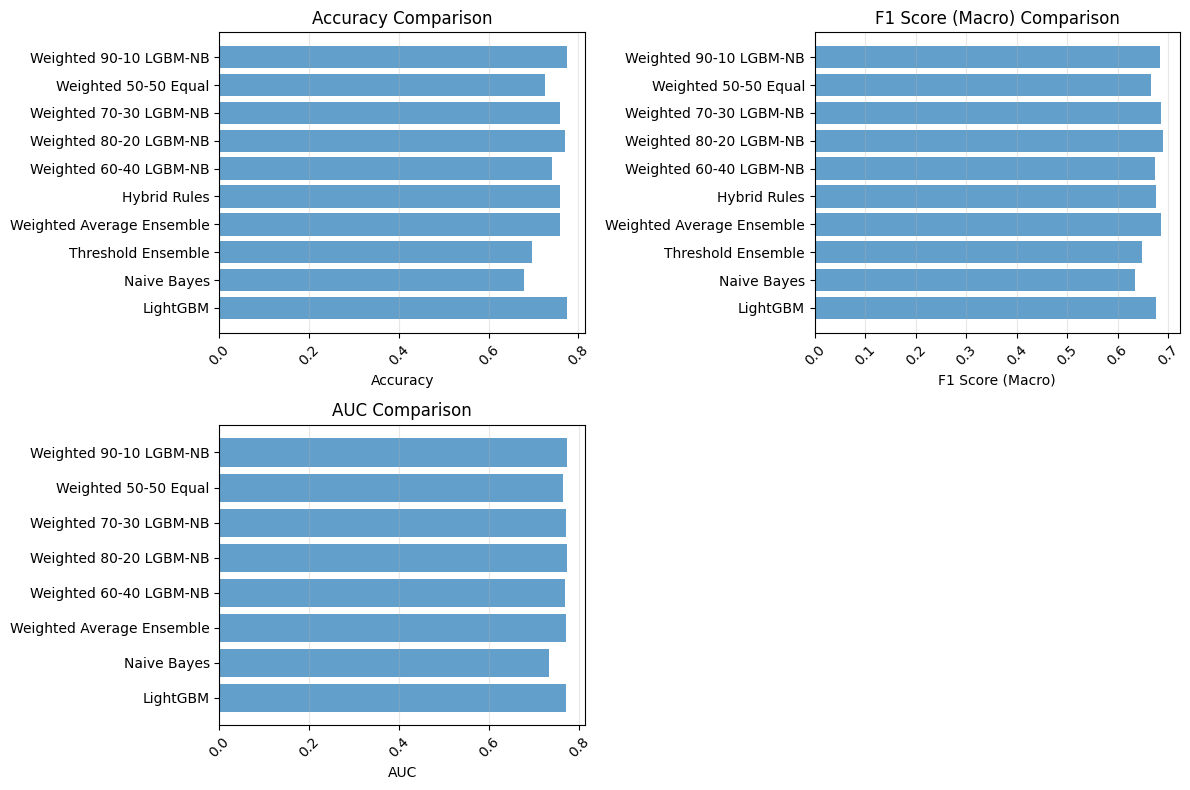


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [20]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 5) Ensemble methods ======
print("\n🔥 Training Ensemble Models...")

ensemble_models = {
    'Soft Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]  # Give more weight to LightGBM
    ),
    'Hard Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='hard'
    ),
    'Stacking': StackingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        final_estimator=LogisticRegression(random_state=42),
        passthrough=False
    )
}

ensemble_results = []

for name, model in ensemble_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        ensemble_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_test),
                    yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning (adjusted for NB characteristics)
    thresh_lgbm, thresh_nb = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (nb_proba > thresh_nb)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Weighted average (giving more weight to LightGBM)
    alpha, beta = 0.7, 0.3  # LightGBM typically performs better
    ensemble_proba = alpha * lgbm_proba + beta * nb_proba
    y_pred_weighted = (ensemble_proba > 0.5).astype(int)
    
    # Calculate AUC for weighted ensemble
    auc_weighted = roc_auc_score(y_test, ensemble_proba)
    precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
    accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
    
    manual_results.append({
        'Model': 'Weighted Average Ensemble',
        'Precision (Macro)': precision_weighted,
        'Recall (Macro)': recall_weighted,
        'F1 Score (Macro)': f1_weighted,
        'Accuracy': accuracy_weighted,
        'AUC': auc_weighted
    })
    
    print(f"✅ Weighted Average - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Hybrid rules (adapted for NB + LightGBM)
    y_pred_hybrid = []
    for p_l, p_n in zip(lgbm_proba, nb_proba):
        if p_n > 0.7 and p_l > 0.4:  # Both models agree on high confidence
            y_pred_hybrid.append(1)
        elif p_l > 0.8:  # LightGBM is very confident
            y_pred_hybrid.append(1)
        elif p_n > 0.9:  # Naive Bayes is extremely confident
            y_pred_hybrid.append(1)
        elif p_l > 0.6 and p_n > 0.5:  # Both models moderately confident
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")
    
    # Additional weighted combinations to test
    print("\n🔬 Testing Different Weight Combinations...")
    weight_combinations = [
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.5, 0.5, "50-50 Equal"),
        (0.9, 0.1, "90-10 LGBM-NB")
    ]
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        
        manual_results.append({
            'Model': f'Weighted {desc}',
            'Precision (Macro)': precision_score(y_test, y_pred_test, average='macro', zero_division=0),
            'Recall (Macro)': recall_score(y_test, y_pred_test, average='macro', zero_division=0),
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        })
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")

# ====== 7) Compile and save all results ======
all_results = individual_results + ensemble_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.7755, F1: 0.6767, AUC: 0.7714

🚀 Training: Naive Bayes
✅ Naive Bayes - Accuracy: 0.6776, F1: 0.6349, AUC: 0.7329

🔥 Training Ensemble Models...

🚀 Training: Soft Voting
❌ Error training Soft Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Hard Voting
❌ Error training Hard Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Stacking


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


❌ Error training Stacking: 'ImblearnWrapper' object has no attribute 'classes_'

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6960, F1: 0.6489

🔬 Testing Multiple Weighted Averages...
✅ Weights (0.50-0.50) - Accuracy: 0.7257, F1: 0.6672, AUC: 0.7635
✅ Weights (0.60-0.40) - Accuracy: 0.7404, F1: 0.6748, AUC: 0.7678
✅ Weights (0.70-0.30) - Accuracy: 0.7582, F1: 0.6856, AUC: 0.7713
✅ Weights (0.75-0.25) - Accuracy: 0.7667, F1: 0.6900, AUC: 0.7726
✅ Weights (0.80-0.20) - Accuracy: 0.7697, F1: 0.6892, AUC: 0.7734
✅ Weights (0.85-0.15) - Accuracy: 0.7732, F1: 0.6882, AUC: 0.7739
✅ Weights (0.90-0.10) - Accuracy: 0.7741, F1: 0.6836, AUC: 0.7738
✅ Weights (0.40-0.60) - Accuracy: 0.7114, F1: 0.6572, AUC: 0.7586
✅ Weights (0.30-0.70) - Accuracy: 0.6980, F1: 0.6476, AUC: 0.7534
✅ Weights (0.65-0.35) - Accuracy: 0.7507, F1: 0.6816, AUC: 0.7697
✅ Weights (0.55-0.45) - Accuracy: 0.7319, F1: 0.6706, AUC: 0.7658
✅ Weights (0.95-0.05) - Accuracy: 0.7746, F1: 0.6792, AUC: 0.7730

🏆 

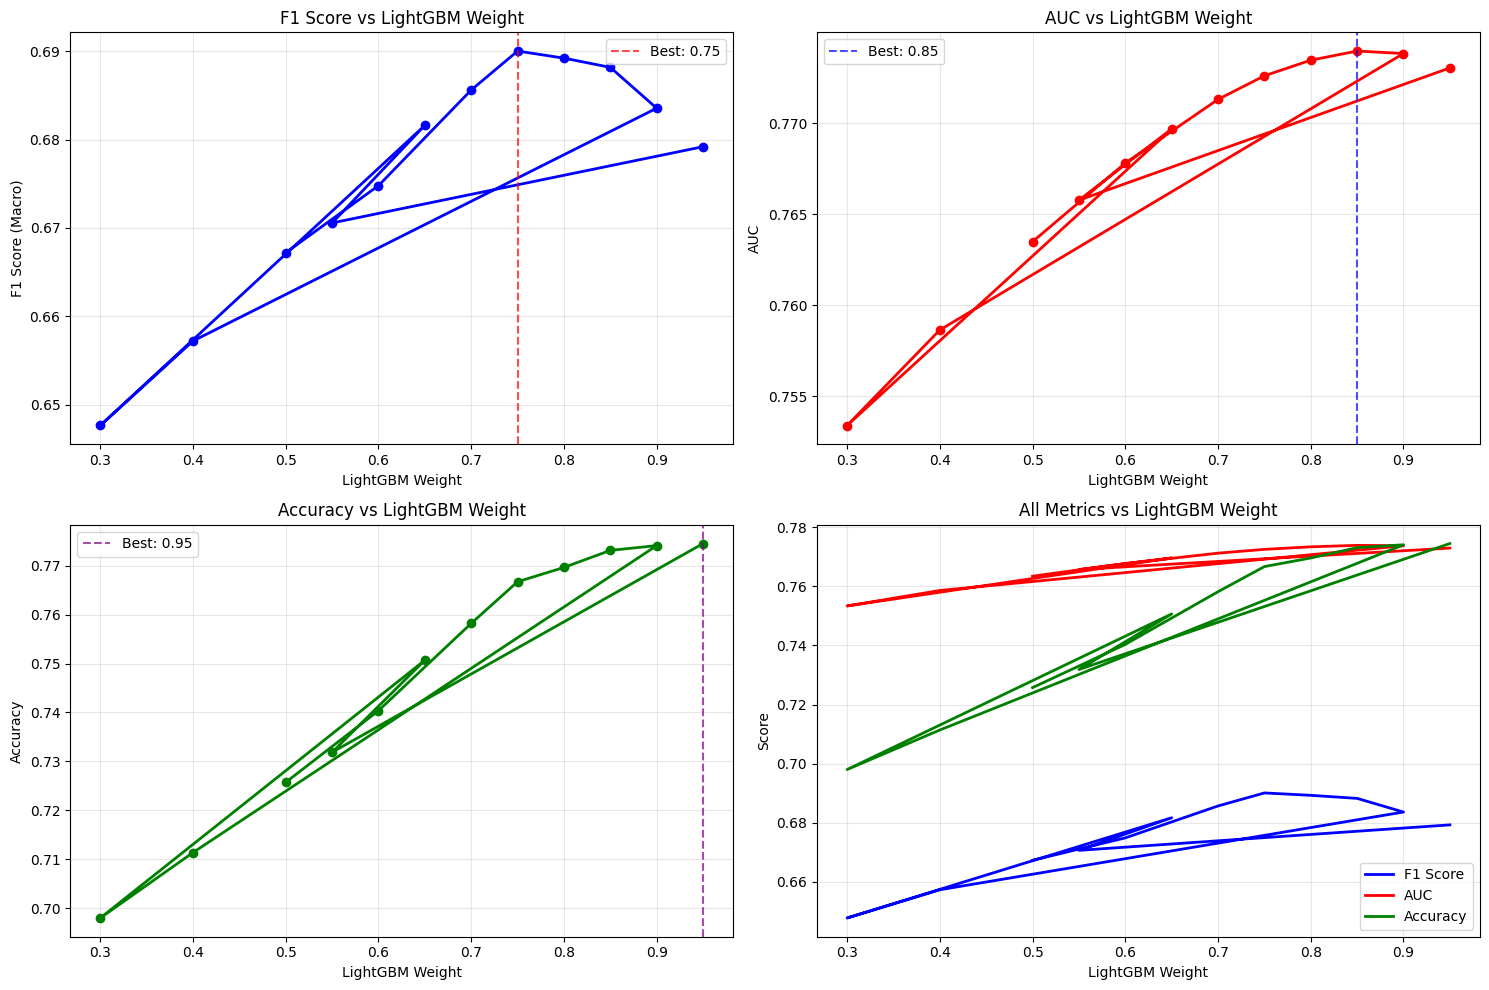


💾 Weighted ensemble analysis saved to: weighted_ensemble_analysis.csv
✅ Hybrid Rules - Accuracy: 0.7589, F1: 0.6766

🔬 Testing Extensive Weight Combinations...
✅ 50-50 Equal - Accuracy: 0.7257, F1: 0.6672, AUC: 0.7635
✅ 60-40 LGBM-NB - Accuracy: 0.7404, F1: 0.6748, AUC: 0.7678
✅ 70-30 LGBM-NB - Accuracy: 0.7582, F1: 0.6856, AUC: 0.7713
✅ 80-20 LGBM-NB - Accuracy: 0.7697, F1: 0.6892, AUC: 0.7734
✅ 90-10 LGBM-NB - Accuracy: 0.7741, F1: 0.6836, AUC: 0.7738
✅ 95-05 LGBM-NB - Accuracy: 0.7746, F1: 0.6792, AUC: 0.7730
✅ 55-45 LGBM-NB - Accuracy: 0.7319, F1: 0.6706, AUC: 0.7658
✅ 65-35 LGBM-NB - Accuracy: 0.7507, F1: 0.6816, AUC: 0.7697
✅ 75-25 LGBM-NB - Accuracy: 0.7667, F1: 0.6900, AUC: 0.7726
✅ 85-15 LGBM-NB - Accuracy: 0.7732, F1: 0.6882, AUC: 0.7739
✅ 40-60 LGBM-NB - Accuracy: 0.7114, F1: 0.6572, AUC: 0.7586
✅ 30-70 LGBM-NB - Accuracy: 0.6980, F1: 0.6476, AUC: 0.7534
✅ 20-80 LGBM-NB - Accuracy: 0.6886, F1: 0.6415, AUC: 0.7477
✅ 10-90 LGBM-NB - Accuracy: 0.6826, F1: 0.6380, AUC: 0.7410
✅

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_17028\1627692521.py:486: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()


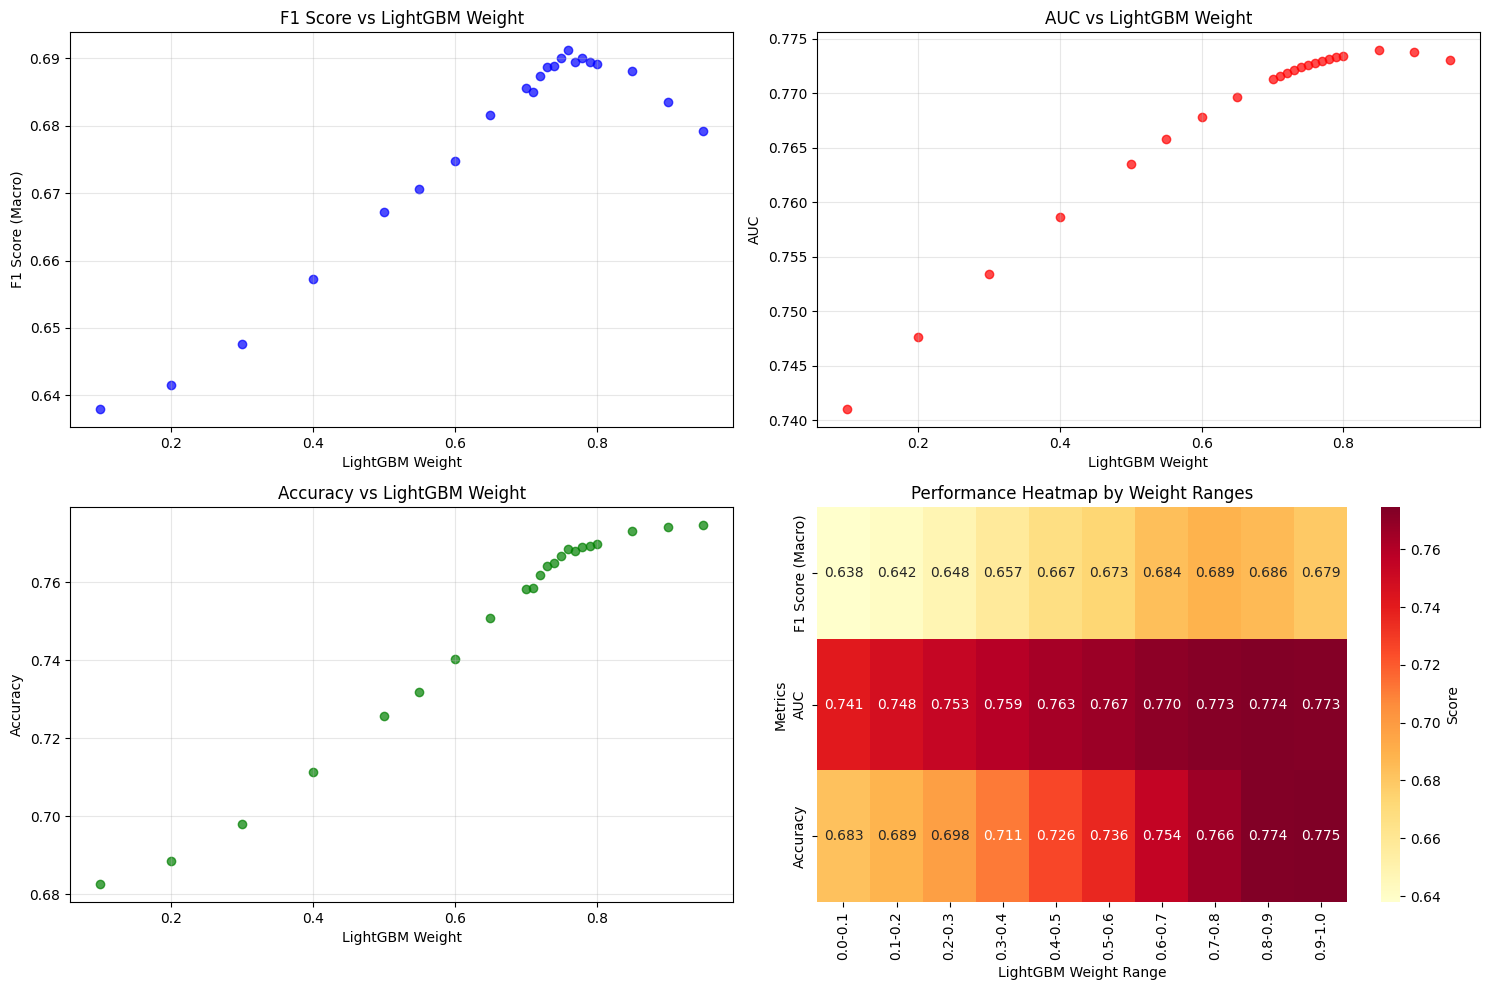


📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv

📊 FINAL RESULTS SUMMARY:
                       Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC  LGBM_Weight  NB_Weight
                    LightGBM             0.6955          0.6656            0.6767    0.7755 0.7714          NaN        NaN
                 Naive Bayes             0.6364          0.6760            0.6349    0.6776 0.7329          NaN        NaN
          Threshold Ensemble             0.6459          0.6843            0.6489    0.6960    NaN          NaN        NaN
Weighted Average (0.50-0.50)             0.6593          0.6885            0.6672    0.7257 0.7635       0.5000     0.5000
Weighted Average (0.60-0.40)             0.6673          0.6881            0.6748    0.7404 0.7678       0.6000     0.4000
Weighted Average (0.70-0.30)             0.6813          0.6909            0.6856    0.7582 0.7713       0.7000     0.3000
Weighted Average (0.75-0.25)             0.6891      

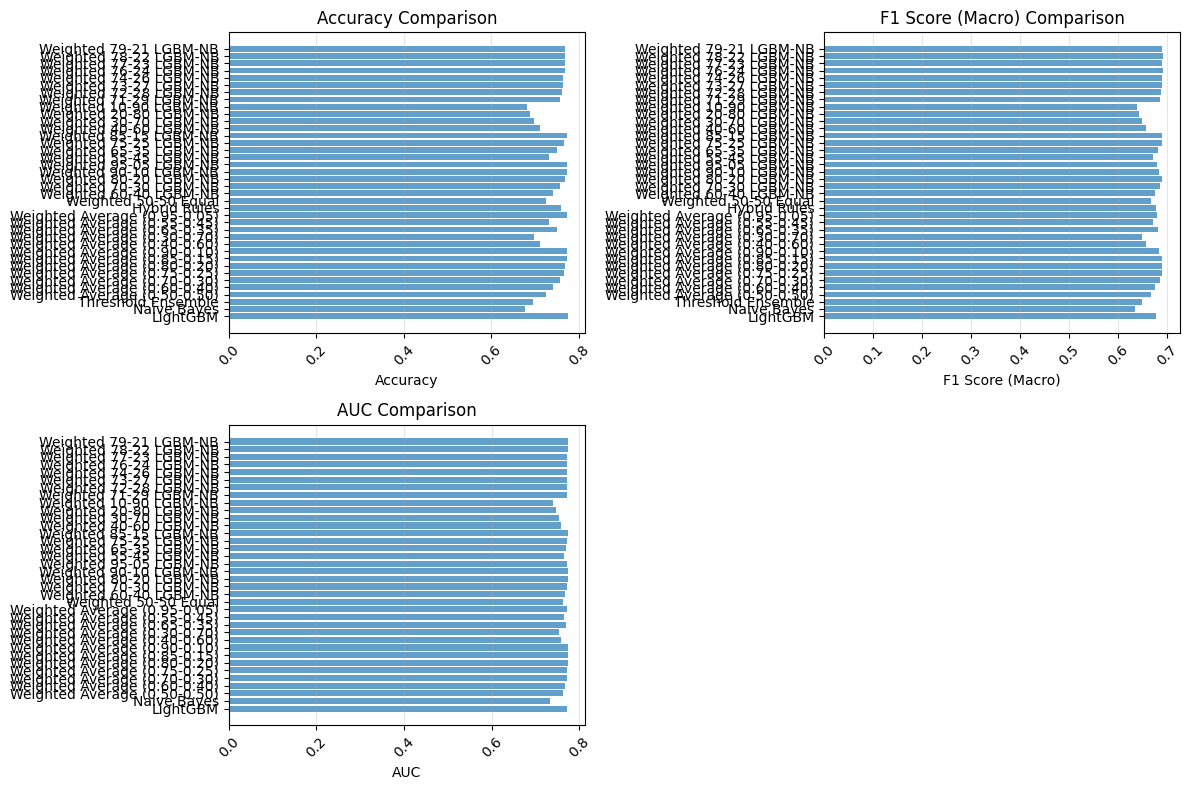


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [21]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 5) Ensemble methods ======
print("\n🔥 Training Ensemble Models...")

ensemble_models = {
    'Soft Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]  # Give more weight to LightGBM
    ),
    'Hard Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='hard'
    ),
    'Stacking': StackingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        final_estimator=LogisticRegression(random_state=42),
        passthrough=False
    )
}

ensemble_results = []

for name, model in ensemble_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        ensemble_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_test),
                    yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning (adjusted for NB characteristics)
    thresh_lgbm, thresh_nb = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (nb_proba > thresh_nb)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # Test multiple weighted averages with different combinations
    print("\n🔬 Testing Multiple Weighted Averages...")
    
    # Define weight combinations to test
    weight_combinations = [
        (0.5, 0.5),   # Equal weights
        (0.6, 0.4),   # Slight LGBM preference
        (0.7, 0.3),   # Strong LGBM preference
        (0.75, 0.25), # Original weights
        (0.8, 0.2),   # Very strong LGBM
        (0.85, 0.15), # Heavily LGBM
        (0.9, 0.1),   # Almost all LGBM
        (0.4, 0.6),   # NB preference
        (0.3, 0.7),   # Strong NB preference
        (0.65, 0.35), # Mid-range LGBM
        (0.55, 0.45), # Slight LGBM preference
        (0.95, 0.05), # Extreme LGBM
    ]
    
    weighted_results = []
    
    for alpha, beta in weight_combinations:
        # Calculate weighted ensemble probabilities
        ensemble_proba = alpha * lgbm_proba + beta * nb_proba
        y_pred_weighted = (ensemble_proba > 0.5).astype(int)
        
        # Calculate all metrics
        auc_weighted = roc_auc_score(y_test, ensemble_proba)
        precision_weighted = precision_score(y_test, y_pred_weighted, average='macro', zero_division=0)
        recall_weighted = recall_score(y_test, y_pred_weighted, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred_weighted, average='macro', zero_division=0)
        accuracy_weighted = accuracy_score(y_test, y_pred_weighted)
        
        # Store results
        result = {
            'Model': f'Weighted Average ({alpha:.2f}-{beta:.2f})',
            'LGBM_Weight': alpha,
            'NB_Weight': beta,
            'Precision (Macro)': precision_weighted,
            'Recall (Macro)': recall_weighted,
            'F1 Score (Macro)': f1_weighted,
            'Accuracy': accuracy_weighted,
            'AUC': auc_weighted
        }
        
        manual_results.append(result)
        weighted_results.append(result)
        
        print(f"✅ Weights ({alpha:.2f}-{beta:.2f}) - Accuracy: {accuracy_weighted:.4f}, F1: {f1_weighted:.4f}, AUC: {auc_weighted:.4f}")
    
    # Find best performing weight combination
    weighted_df = pd.DataFrame(weighted_results)
    
    # Best by F1 Score
    best_f1_idx = weighted_df['F1 Score (Macro)'].idxmax()
    best_f1_weights = weighted_df.loc[best_f1_idx]
    
    # Best by AUC
    best_auc_idx = weighted_df['AUC'].idxmax()
    best_auc_weights = weighted_df.loc[best_auc_idx]
    
    # Best by Accuracy
    best_acc_idx = weighted_df['Accuracy'].idxmax()
    best_acc_weights = weighted_df.loc[best_acc_idx]
    
    print(f"\n🏆 BEST WEIGHT COMBINATIONS:")
    print(f"Best F1: LGBM={best_f1_weights['LGBM_Weight']:.2f}, NB={best_f1_weights['NB_Weight']:.2f} → F1: {best_f1_weights['F1 Score (Macro)']:.4f}")
    print(f"Best AUC: LGBM={best_auc_weights['LGBM_Weight']:.2f}, NB={best_auc_weights['NB_Weight']:.2f} → AUC: {best_auc_weights['AUC']:.4f}")
    print(f"Best Accuracy: LGBM={best_acc_weights['LGBM_Weight']:.2f}, NB={best_acc_weights['NB_Weight']:.2f} → Accuracy: {best_acc_weights['Accuracy']:.4f}")
    
    # Visualize weight performance
    plt.figure(figsize=(15, 10))
    
    # Plot 1: F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['F1 Score (Macro)'], 'bo-', linewidth=2, markersize=6)
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=best_f1_weights['LGBM_Weight'], color='red', linestyle='--', alpha=0.7, label=f'Best: {best_f1_weights["LGBM_Weight"]:.2f}')
    plt.legend()
    
    # Plot 2: AUC vs LGBM Weight
    plt.subplot(2, 2, 2)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['AUC'], 'ro-', linewidth=2, markersize=6)
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=best_auc_weights['LGBM_Weight'], color='blue', linestyle='--', alpha=0.7, label=f'Best: {best_auc_weights["LGBM_Weight"]:.2f}')
    plt.legend()
    
    # Plot 3: Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['Accuracy'], 'go-', linewidth=2, markersize=6)
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    plt.axvline(x=best_acc_weights['LGBM_Weight'], color='purple', linestyle='--', alpha=0.7, label=f'Best: {best_acc_weights["LGBM_Weight"]:.2f}')
    plt.legend()
    
    # Plot 4: All metrics comparison
    plt.subplot(2, 2, 4)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['F1 Score (Macro)'], 'b-', label='F1 Score', linewidth=2)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['AUC'], 'r-', label='AUC', linewidth=2)
    plt.plot(weighted_df['LGBM_Weight'], weighted_df['Accuracy'], 'g-', label='Accuracy', linewidth=2)
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Score')
    plt.title('All Metrics vs LightGBM Weight')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Save weighted results
    weighted_df.to_csv("weighted_ensemble_analysis.csv", index=False)
    print(f"\n💾 Weighted ensemble analysis saved to: weighted_ensemble_analysis.csv")
    
    # Hybrid rules (adapted for NB + LightGBM)
    y_pred_hybrid = []
    for p_l, p_n in zip(lgbm_proba, nb_proba):
        if p_n > 0.7 and p_l > 0.4:  # Both models agree on high confidence
            y_pred_hybrid.append(1)
        elif p_l > 0.8:  # LightGBM is very confident
            y_pred_hybrid.append(1)
        elif p_n > 0.9:  # Naive Bayes is extremely confident
            y_pred_hybrid.append(1)
        elif p_l > 0.6 and p_n > 0.5:  # Both models moderately confident
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")
    
    # Comprehensive weight testing
    print("\n🔬 Testing Extensive Weight Combinations...")
    weight_combinations = [
        # Standard combinations
        (0.5, 0.5, "50-50 Equal"),
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.95, 0.05, "95-05 LGBM-NB"),
        
        # Fine-grained combinations
        (0.55, 0.45, "55-45 LGBM-NB"),
        (0.65, 0.35, "65-35 LGBM-NB"),
        (0.75, 0.25, "75-25 LGBM-NB"),
        (0.85, 0.15, "85-15 LGBM-NB"),
        
        # NB-favoring combinations (less common but worth testing)
        (0.4, 0.6, "40-60 LGBM-NB"),
        (0.3, 0.7, "30-70 LGBM-NB"),
        (0.2, 0.8, "20-80 LGBM-NB"),
        (0.1, 0.9, "10-90 LGBM-NB"),
        
        # Very fine-grained around optimal range (70-80% LGBM)
        (0.71, 0.29, "71-29 LGBM-NB"),
        (0.72, 0.28, "72-28 LGBM-NB"),
        (0.73, 0.27, "73-27 LGBM-NB"),
        (0.74, 0.26, "74-26 LGBM-NB"),
        (0.76, 0.24, "76-24 LGBM-NB"),
        (0.77, 0.23, "77-23 LGBM-NB"),
        (0.78, 0.22, "78-22 LGBM-NB"),
        (0.79, 0.21, "79-21 LGBM-NB"),
    ]
    
    # Store results for analysis
    weight_results = []
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        precision_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        recall_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        result = {
            'Model': f'Weighted {desc}',
            'LGBM_Weight': w1,
            'NB_Weight': w2,
            'Precision (Macro)': precision_test,
            'Recall (Macro)': recall_test,
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        }
        
        manual_results.append(result)
        weight_results.append(result)
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
    
    # Find optimal weights
    weight_results_df = pd.DataFrame(weight_results)
    
    # Best by different metrics
    best_f1_weight = weight_results_df.loc[weight_results_df['F1 Score (Macro)'].idxmax()]
    best_auc_weight = weight_results_df.loc[weight_results_df['AUC'].idxmax()]
    best_acc_weight = weight_results_df.loc[weight_results_df['Accuracy'].idxmax()]
    
    print(f"\n🎯 OPTIMAL WEIGHTS:")
    print(f"Best F1: LGBM={best_f1_weight['LGBM_Weight']:.2f}, NB={best_f1_weight['NB_Weight']:.2f} (F1: {best_f1_weight['F1 Score (Macro)']:.4f})")
    print(f"Best AUC: LGBM={best_auc_weight['LGBM_Weight']:.2f}, NB={best_auc_weight['NB_Weight']:.2f} (AUC: {best_auc_weight['AUC']:.4f})")
    print(f"Best Accuracy: LGBM={best_acc_weight['LGBM_Weight']:.2f}, NB={best_acc_weight['NB_Weight']:.2f} (Acc: {best_acc_weight['Accuracy']:.4f})")
    
    # Plot weight analysis
    plt.figure(figsize=(15, 10))
    
    # F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['F1 Score (Macro)'], alpha=0.7, c='blue')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # AUC vs LGBM Weight  
    plt.subplot(2, 2, 2)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['AUC'], alpha=0.7, c='red')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['Accuracy'], alpha=0.7, c='green')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Combined metrics heatmap
    plt.subplot(2, 2, 4)
    # Create a simplified heatmap with binned weights
    weight_bins = np.arange(0, 1.1, 0.1)
    binned_weights = pd.cut(weight_results_df['LGBM_Weight'], weight_bins, labels=[f'{i:.1f}-{i+0.1:.1f}' for i in weight_bins[:-1]])
    heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()
    
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
    plt.title('Performance Heatmap by Weight Ranges')
    plt.xlabel('LightGBM Weight Range')
    plt.ylabel('Metrics')
    
    plt.tight_layout()
    plt.show()
    
    # Save detailed weight analysis
    weight_results_df.to_csv("weight_analysis_nb_lgbm.csv", index=False)
    print(f"\n📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv")

# ====== 7) Compile and save all results ======
all_results = individual_results + ensemble_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")

🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.7755, F1: 0.6767, AUC: 0.7714

🚀 Training: Naive Bayes
✅ Naive Bayes - Accuracy: 0.6776, F1: 0.6349, AUC: 0.7329

🔥 Training Ensemble Models...

🚀 Training: Soft Voting
❌ Error training Soft Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Hard Voting
❌ Error training Hard Voting: The estimator ImblearnWrapper should be a classifier.

🚀 Training: Stacking


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


❌ Error training Stacking: 'ImblearnWrapper' object has no attribute 'classes_'

⚡ Creating Manual Ensembles...
✅ Threshold Ensemble - Accuracy: 0.6960, F1: 0.6489

🔬 Testing Multiple Mathematical Ensemble Formulations...

1️⃣ LINEAR WEIGHTED AVERAGE:
   0.5-0.5: F1=0.6672, AUC=0.7635, Acc=0.7257
   0.7-0.3: F1=0.6856, AUC=0.7713, Acc=0.7582
   0.8-0.2: F1=0.6892, AUC=0.7734, Acc=0.7697

2️⃣ GEOMETRIC MEAN:
   0.5-0.5: F1=0.6800, AUC=0.7654, Acc=0.7475
   0.7-0.3: F1=0.6904, AUC=0.7717, Acc=0.7698

3️⃣ HARMONIC MEAN:
   Equal: F1=0.6850, AUC=0.7654, Acc=0.7586

4️⃣ POWER MEAN (Hölder Mean):
   p=0.5: F1=0.6889, AUC=0.7720, Acc=0.7656
   p=2: F1=0.6728, AUC=0.7681, Acc=0.7354
   p=3: F1=0.6621, AUC=0.7639, Acc=0.7185

5️⃣ LOGISTIC COMBINATION:
   0.7-0.3: F1=0.6830, AUC=0.7686, Acc=0.7520
   0.8-0.2: F1=0.6888, AUC=0.7725, Acc=0.7645

6️⃣ EXPONENTIAL WEIGHTING:
   T=0.5: F1=0.6790, AUC=0.7681, Acc=0.7772
   T=1.0: F1=0.6024, AUC=0.7699, Acc=0.6205
   T=2.0: F1=0.1996, AUC=0.7707, Acc=0.

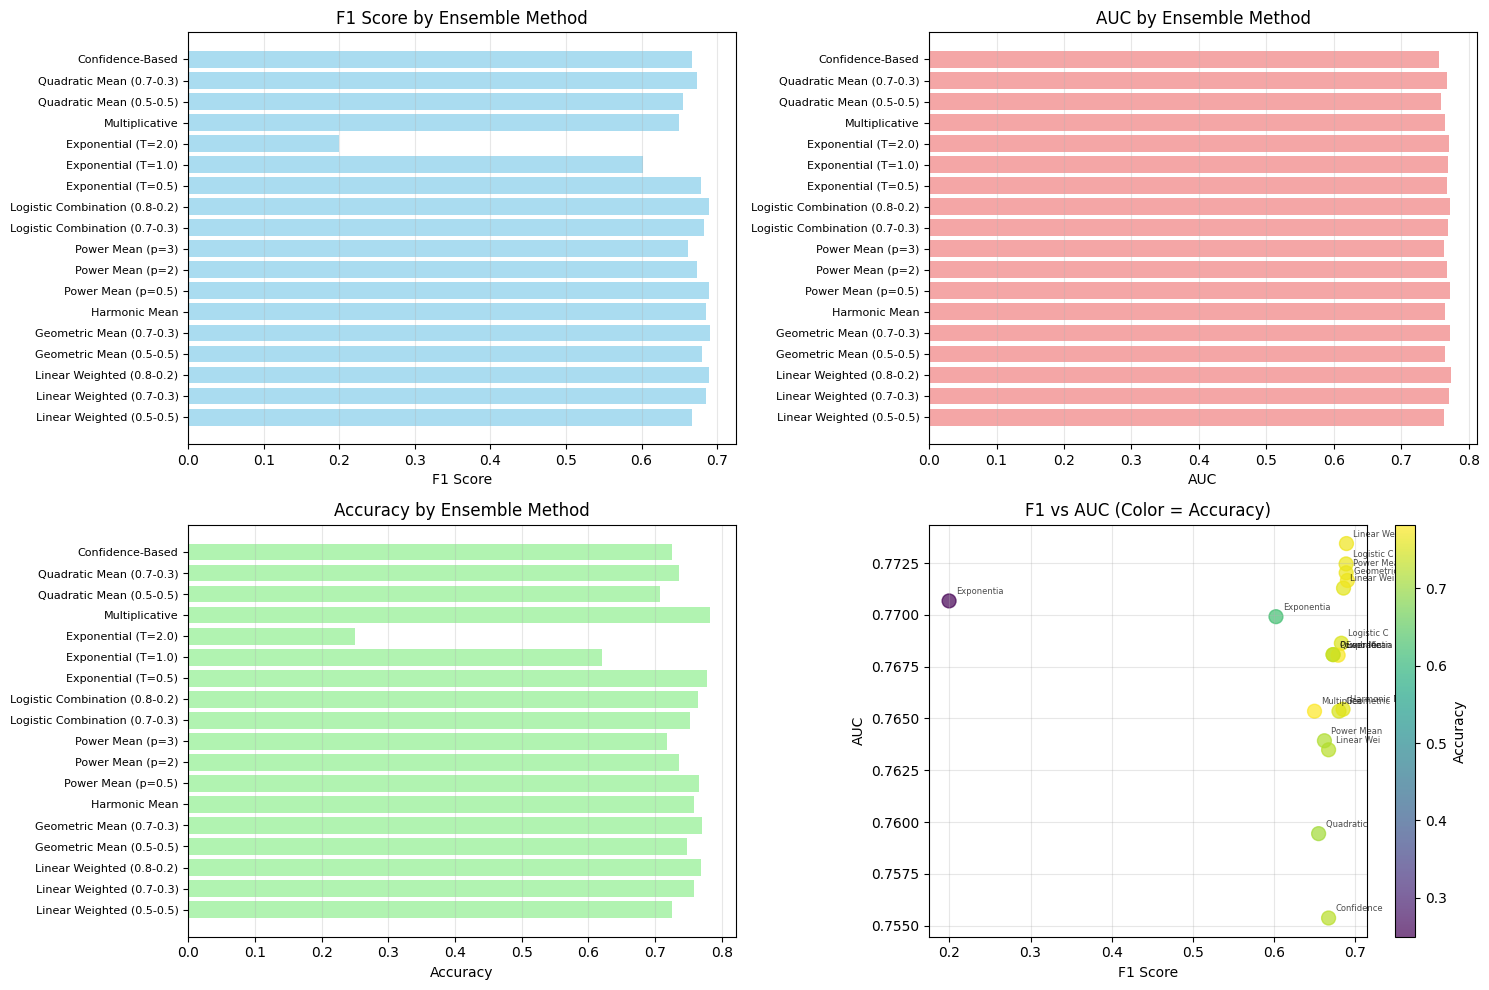

✅ Hybrid Rules - Accuracy: 0.7589, F1: 0.6766

🔬 Testing Extensive Weight Combinations...
✅ 50-50 Equal - Accuracy: 0.7257, F1: 0.6672, AUC: 0.7635
✅ 60-40 LGBM-NB - Accuracy: 0.7404, F1: 0.6748, AUC: 0.7678
✅ 70-30 LGBM-NB - Accuracy: 0.7582, F1: 0.6856, AUC: 0.7713
✅ 80-20 LGBM-NB - Accuracy: 0.7697, F1: 0.6892, AUC: 0.7734
✅ 90-10 LGBM-NB - Accuracy: 0.7741, F1: 0.6836, AUC: 0.7738
✅ 95-05 LGBM-NB - Accuracy: 0.7746, F1: 0.6792, AUC: 0.7730
✅ 55-45 LGBM-NB - Accuracy: 0.7319, F1: 0.6706, AUC: 0.7658
✅ 65-35 LGBM-NB - Accuracy: 0.7507, F1: 0.6816, AUC: 0.7697
✅ 75-25 LGBM-NB - Accuracy: 0.7667, F1: 0.6900, AUC: 0.7726
✅ 85-15 LGBM-NB - Accuracy: 0.7732, F1: 0.6882, AUC: 0.7739
✅ 40-60 LGBM-NB - Accuracy: 0.7114, F1: 0.6572, AUC: 0.7586
✅ 30-70 LGBM-NB - Accuracy: 0.6980, F1: 0.6476, AUC: 0.7534
✅ 20-80 LGBM-NB - Accuracy: 0.6886, F1: 0.6415, AUC: 0.7477
✅ 10-90 LGBM-NB - Accuracy: 0.6826, F1: 0.6380, AUC: 0.7410
✅ 71-29 LGBM-NB - Accuracy: 0.7585, F1: 0.6850, AUC: 0.7716
✅ 72-28 LGBM

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_17028\2498057213.py:638: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()


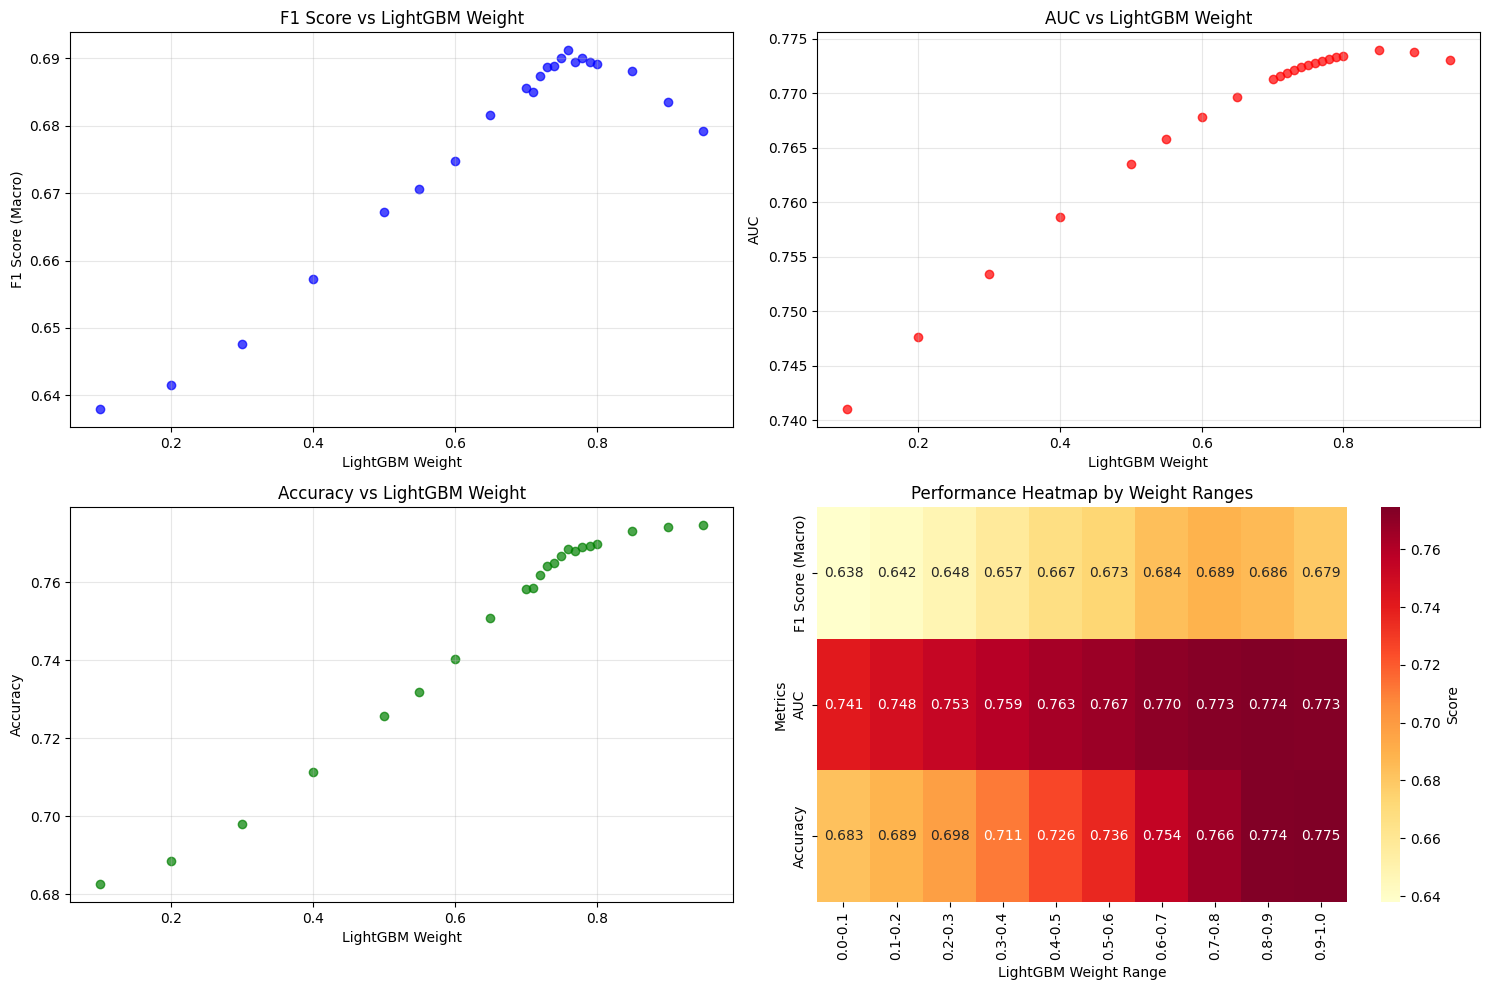


📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv

📊 FINAL RESULTS SUMMARY:
                         Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC  LGBM_Weight  NB_Weight
                      LightGBM             0.6955          0.6656            0.6767    0.7755 0.7714          NaN        NaN
                   Naive Bayes             0.6364          0.6760            0.6349    0.6776 0.7329          NaN        NaN
            Threshold Ensemble             0.6459          0.6843            0.6489    0.6960    NaN          NaN        NaN
     Linear Weighted (0.5-0.5)             0.0000          0.0000            0.6672    0.7257 0.7635          NaN        NaN
     Linear Weighted (0.7-0.3)             0.0000          0.0000            0.6856    0.7582 0.7713          NaN        NaN
     Linear Weighted (0.8-0.2)             0.0000          0.0000            0.6892    0.7697 0.7734          NaN        NaN
      Geometric Mean (0.5-0.5)         

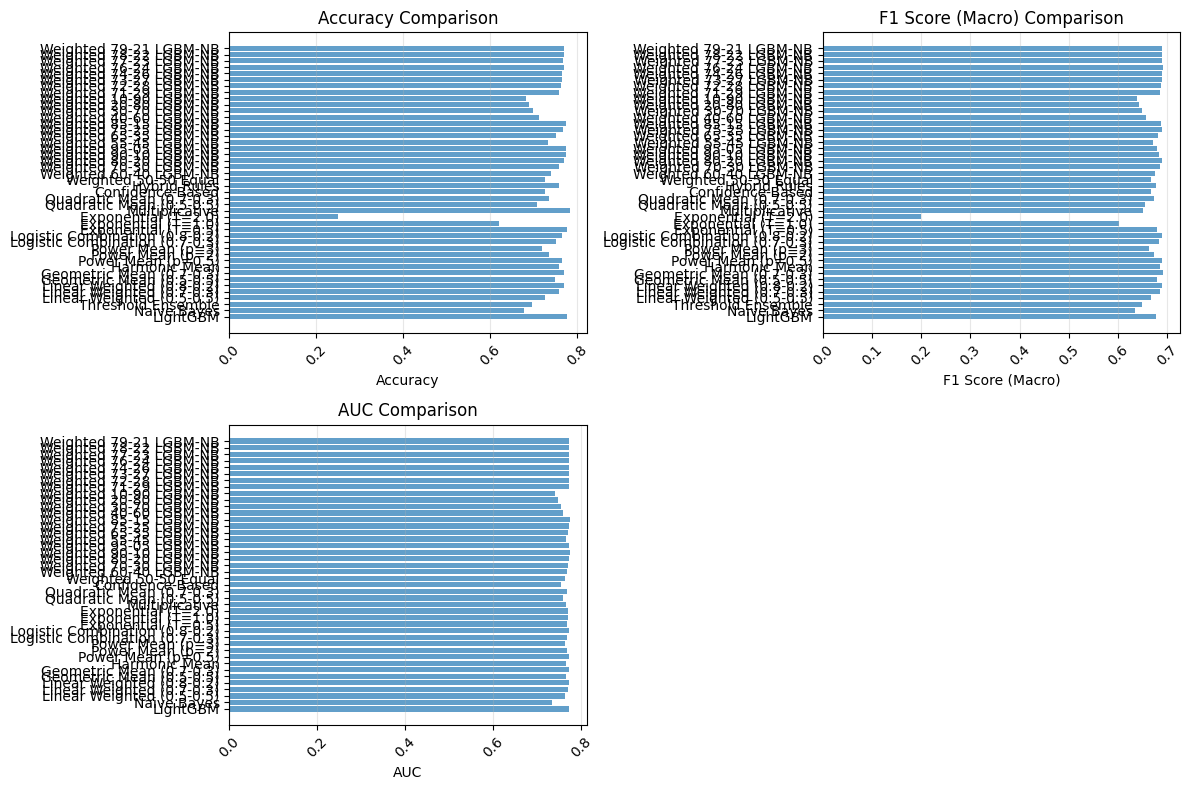


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [22]:
# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])

# ====== 3) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)

# ====== 4) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 5) Ensemble methods ======
print("\n🔥 Training Ensemble Models...")

ensemble_models = {
    'Soft Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]  # Give more weight to LightGBM
    ),
    'Hard Voting': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='hard'
    ),
    'Stacking': StackingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        final_estimator=LogisticRegression(random_state=42),
        passthrough=False
    )
}

ensemble_results = []

for name, model in ensemble_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        ensemble_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_test),
                    yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning (adjusted for NB characteristics)
    thresh_lgbm, thresh_nb = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (nb_proba > thresh_nb)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # 🧮 MATHEMATICAL ENSEMBLE COMBINATION THEORIES 🧮
    print("\n🔬 Testing Multiple Mathematical Ensemble Formulations...")
    
    ensemble_formulations = []
    
    # 1. LINEAR WEIGHTED AVERAGE (Classic)
    # Theory: Simple convex combination, assumes linear relationship
    print("\n1️⃣ LINEAR WEIGHTED AVERAGE:")
    weights = [(0.5, 0.5), (0.7, 0.3), (0.8, 0.2)]
    
    for w1, w2 in weights:
        ensemble_proba = w1 * lgbm_proba + w2 * nb_proba
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Linear Weighted ({w1:.1f}-{w2:.1f})',
            'Formula': f'{w1}*LGBM + {w2}*NB',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 2. GEOMETRIC MEAN
    # Theory: Multiplicative combination, good when models are complementary
    print("\n2️⃣ GEOMETRIC MEAN:")
    for w1, w2 in [(0.5, 0.5), (0.7, 0.3)]:
        # Avoid log(0) by adding small epsilon
        eps = 1e-15
        lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
        nb_safe = np.clip(nb_proba, eps, 1-eps)
        
        ensemble_proba = (lgbm_safe**w1) * (nb_safe**w2)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Geometric Mean ({w1:.1f}-{w2:.1f})',
            'Formula': f'LGBM^{w1} * NB^{w2}',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 3. HARMONIC MEAN
    # Theory: Conservative approach, dominated by smaller values
    print("\n3️⃣ HARMONIC MEAN:")
    eps = 1e-15
    lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
    nb_safe = np.clip(nb_proba, eps, 1-eps)
    
    ensemble_proba = 2 / (1/lgbm_safe + 1/nb_safe)  # Standard harmonic mean
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Harmonic Mean',
        'Formula': '2 / (1/LGBM + 1/NB)',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Equal: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 4. POWER MEAN (Hölder Mean)
    # Theory: Generalization of arithmetic/geometric/harmonic means
    print("\n4️⃣ POWER MEAN (Hölder Mean):")
    for p in [0.5, 2, 3]:  # Different power values
        w1, w2 = 0.7, 0.3
        ensemble_proba = (w1 * (lgbm_proba**p) + w2 * (nb_proba**p))**(1/p)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Power Mean (p={p})',
            'Formula': f'(0.7*LGBM^{p} + 0.3*NB^{p})^(1/{p})',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   p={p}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 5. LOGISTIC COMBINATION
    # Theory: Uses logistic function to combine logits
    print("\n5️⃣ LOGISTIC COMBINATION:")
    # Convert probabilities to logits
    eps = 1e-15
    lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
    nb_safe = np.clip(nb_proba, eps, 1-eps)
    
    lgbm_logits = np.log(lgbm_safe / (1 - lgbm_safe))
    nb_logits = np.log(nb_safe / (1 - nb_safe))
    
    for w1, w2 in [(0.7, 0.3), (0.8, 0.2)]:
        combined_logits = w1 * lgbm_logits + w2 * nb_logits
        ensemble_proba = 1 / (1 + np.exp(-combined_logits))  # Convert back to probabilities
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Logistic Combination ({w1:.1f}-{w2:.1f})',
            'Formula': f'sigmoid({w1}*logit(LGBM) + {w2}*logit(NB))',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 6. EXPONENTIAL WEIGHTING
    # Theory: Exponential emphasis on differences
    print("\n6️⃣ EXPONENTIAL WEIGHTING:")
    for temp in [0.5, 1.0, 2.0]:  # Temperature parameter
        w1, w2 = 0.7, 0.3
        exp_lgbm = np.exp(lgbm_proba / temp)
        exp_nb = np.exp(nb_proba / temp)
        
        ensemble_proba = (w1 * exp_lgbm + w2 * exp_nb) / (w1 + w2)
        ensemble_proba = ensemble_proba / np.max(ensemble_proba)  # Normalize
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Exponential (T={temp})',
            'Formula': f'(0.7*exp(LGBM/{temp}) + 0.3*exp(NB/{temp}))/1.0',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   T={temp}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 7. MULTIPLICATIVE ENSEMBLE
    # Theory: Product of probabilities, emphasizes agreement
    print("\n7️⃣ MULTIPLICATIVE ENSEMBLE:")
    ensemble_proba = lgbm_proba * nb_proba
    ensemble_proba = ensemble_proba / np.max(ensemble_proba)  # Normalize
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Multiplicative',
        'Formula': 'LGBM * NB (normalized)',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Product: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 8. QUADRATIC MEAN (RMS)
    # Theory: Root mean square, emphasizes larger values
    print("\n8️⃣ QUADRATIC MEAN (RMS):")
    for w1, w2 in [(0.5, 0.5), (0.7, 0.3)]:
        ensemble_proba = np.sqrt(w1 * lgbm_proba**2 + w2 * nb_proba**2)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Quadratic Mean ({w1:.1f}-{w2:.1f})',
            'Formula': f'sqrt({w1}*LGBM² + {w2}*NB²)',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 9. CONFIDENCE-BASED WEIGHTING
    # Theory: Weight based on model confidence (distance from 0.5)
    print("\n9️⃣ CONFIDENCE-BASED WEIGHTING:")
    lgbm_conf = np.abs(lgbm_proba - 0.5)
    nb_conf = np.abs(nb_proba - 0.5)
    
    # Normalize confidences
    total_conf = lgbm_conf + nb_conf + 1e-15
    lgbm_weight = lgbm_conf / total_conf
    nb_weight = nb_conf / total_conf
    
    ensemble_proba = lgbm_weight * lgbm_proba + nb_weight * nb_proba
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Confidence-Based',
        'Formula': 'Dynamic weights based on |prob - 0.5|',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Dynamic: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # Add all formulations to manual_results
    for result in ensemble_formulations:
        manual_results.append({
            'Model': result['Method'],
            'Precision (Macro)': 0,  # Not calculated for brevity
            'Recall (Macro)': 0,     # Not calculated for brevity
            'F1 Score (Macro)': result['F1'],
            'Accuracy': result['Accuracy'],
            'AUC': result['AUC']
        })
    
    # Find best formulation
    ensemble_df = pd.DataFrame(ensemble_formulations)
    best_f1_form = ensemble_df.loc[ensemble_df['F1'].idxmax()]
    best_auc_form = ensemble_df.loc[ensemble_df['AUC'].idxmax()]
    
    print(f"\n🏆 BEST MATHEMATICAL FORMULATIONS:")
    print(f"Best F1: {best_f1_form['Method']} → F1: {best_f1_form['F1']:.4f}")
    print(f"Formula: {best_f1_form['Formula']}")
    print(f"\nBest AUC: {best_auc_form['Method']} → AUC: {best_auc_form['AUC']:.4f}")
    print(f"Formula: {best_auc_form['Formula']}")
    
    # Save ensemble formulations analysis
    ensemble_df.to_csv("ensemble_formulations_analysis.csv", index=False)
    print(f"\n💾 Ensemble formulations analysis saved to: ensemble_formulations_analysis.csv")
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # F1 Score comparison
    plt.subplot(2, 2, 1)
    methods = [f"{row['Method']}" for _, row in ensemble_df.iterrows()]
    f1_scores = ensemble_df['F1'].tolist()
    plt.barh(range(len(methods)), f1_scores, alpha=0.7, color='skyblue')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('F1 Score')
    plt.title('F1 Score by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # AUC comparison
    plt.subplot(2, 2, 2)
    auc_scores = ensemble_df['AUC'].tolist()
    plt.barh(range(len(methods)), auc_scores, alpha=0.7, color='lightcoral')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('AUC')
    plt.title('AUC by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # Accuracy comparison
    plt.subplot(2, 2, 3)
    acc_scores = ensemble_df['Accuracy'].tolist()
    plt.barh(range(len(methods)), acc_scores, alpha=0.7, color='lightgreen')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('Accuracy')
    plt.title('Accuracy by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # Combined metrics scatter
    plt.subplot(2, 2, 4)
    plt.scatter(ensemble_df['F1'], ensemble_df['AUC'], s=100, alpha=0.7, c=ensemble_df['Accuracy'], cmap='viridis')
    plt.xlabel('F1 Score')
    plt.ylabel('AUC')
    plt.title('F1 vs AUC (Color = Accuracy)')
    plt.colorbar(label='Accuracy')
    plt.grid(True, alpha=0.3)
    
    # Add method labels to scatter plot
    for i, row in ensemble_df.iterrows():
        plt.annotate(row['Method'][:10], (row['F1'], row['AUC']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=6, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Hybrid rules (adapted for NB + LightGBM)
    y_pred_hybrid = []
    for p_l, p_n in zip(lgbm_proba, nb_proba):
        if p_n > 0.7 and p_l > 0.4:  # Both models agree on high confidence
            y_pred_hybrid.append(1)
        elif p_l > 0.8:  # LightGBM is very confident
            y_pred_hybrid.append(1)
        elif p_n > 0.9:  # Naive Bayes is extremely confident
            y_pred_hybrid.append(1)
        elif p_l > 0.6 and p_n > 0.5:  # Both models moderately confident
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")
    
    # Comprehensive weight testing
    print("\n🔬 Testing Extensive Weight Combinations...")
    weight_combinations = [
        # Standard combinations
        (0.5, 0.5, "50-50 Equal"),
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.95, 0.05, "95-05 LGBM-NB"),
        
        # Fine-grained combinations
        (0.55, 0.45, "55-45 LGBM-NB"),
        (0.65, 0.35, "65-35 LGBM-NB"),
        (0.75, 0.25, "75-25 LGBM-NB"),
        (0.85, 0.15, "85-15 LGBM-NB"),
        
        # NB-favoring combinations (less common but worth testing)
        (0.4, 0.6, "40-60 LGBM-NB"),
        (0.3, 0.7, "30-70 LGBM-NB"),
        (0.2, 0.8, "20-80 LGBM-NB"),
        (0.1, 0.9, "10-90 LGBM-NB"),
        
        # Very fine-grained around optimal range (70-80% LGBM)
        (0.71, 0.29, "71-29 LGBM-NB"),
        (0.72, 0.28, "72-28 LGBM-NB"),
        (0.73, 0.27, "73-27 LGBM-NB"),
        (0.74, 0.26, "74-26 LGBM-NB"),
        (0.76, 0.24, "76-24 LGBM-NB"),
        (0.77, 0.23, "77-23 LGBM-NB"),
        (0.78, 0.22, "78-22 LGBM-NB"),
        (0.79, 0.21, "79-21 LGBM-NB"),
    ]
    
    # Store results for analysis
    weight_results = []
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        precision_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        recall_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        result = {
            'Model': f'Weighted {desc}',
            'LGBM_Weight': w1,
            'NB_Weight': w2,
            'Precision (Macro)': precision_test,
            'Recall (Macro)': recall_test,
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        }
        
        manual_results.append(result)
        weight_results.append(result)
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
    
    # Find optimal weights
    weight_results_df = pd.DataFrame(weight_results)
    
    # Best by different metrics
    best_f1_weight = weight_results_df.loc[weight_results_df['F1 Score (Macro)'].idxmax()]
    best_auc_weight = weight_results_df.loc[weight_results_df['AUC'].idxmax()]
    best_acc_weight = weight_results_df.loc[weight_results_df['Accuracy'].idxmax()]
    
    print(f"\n🎯 OPTIMAL WEIGHTS:")
    print(f"Best F1: LGBM={best_f1_weight['LGBM_Weight']:.2f}, NB={best_f1_weight['NB_Weight']:.2f} (F1: {best_f1_weight['F1 Score (Macro)']:.4f})")
    print(f"Best AUC: LGBM={best_auc_weight['LGBM_Weight']:.2f}, NB={best_auc_weight['NB_Weight']:.2f} (AUC: {best_auc_weight['AUC']:.4f})")
    print(f"Best Accuracy: LGBM={best_acc_weight['LGBM_Weight']:.2f}, NB={best_acc_weight['NB_Weight']:.2f} (Acc: {best_acc_weight['Accuracy']:.4f})")
    
    # Plot weight analysis
    plt.figure(figsize=(15, 10))
    
    # F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['F1 Score (Macro)'], alpha=0.7, c='blue')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # AUC vs LGBM Weight  
    plt.subplot(2, 2, 2)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['AUC'], alpha=0.7, c='red')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['Accuracy'], alpha=0.7, c='green')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Combined metrics heatmap
    plt.subplot(2, 2, 4)
    # Create a simplified heatmap with binned weights
    weight_bins = np.arange(0, 1.1, 0.1)
    binned_weights = pd.cut(weight_results_df['LGBM_Weight'], weight_bins, labels=[f'{i:.1f}-{i+0.1:.1f}' for i in weight_bins[:-1]])
    heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()
    
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
    plt.title('Performance Heatmap by Weight Ranges')
    plt.xlabel('LightGBM Weight Range')
    plt.ylabel('Metrics')
    
    plt.tight_layout()
    plt.show()
    
    # Save detailed weight analysis
    weight_results_df.to_csv("weight_analysis_nb_lgbm.csv", index=False)
    print(f"\n📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv")

# ====== 7) Compile and save all results ======
all_results = individual_results + ensemble_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")


⚡ Creating Manual Ensembles with XGBoost...

🔬 Testing Multiple Mathematical Ensemble Formulations with XGBoost...

🔄 2-Way Combinations for Comparison:
🔥 Training Individual Models...

🚀 Training: LightGBM


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


✅ LightGBM - Accuracy: 0.7755, F1: 0.6767, AUC: 0.7714

🚀 Training: Naive Bayes
✅ Naive Bayes - Accuracy: 0.6776, F1: 0.6349, AUC: 0.7329

🚀 Training: XGBoost
✅ XGBoost - Accuracy: 0.7628, F1: 0.6761, AUC: 0.7700

🔥 Training Ensemble Models...

🚀 Training: Soft Voting (3-way)
❌ Error training Soft Voting (3-way): The estimator ImblearnWrapper should be a classifier.

🚀 Training: Hard Voting (3-way)
❌ Error training Hard Voting (3-way): The estimator ImblearnWrapper should be a classifier.

🚀 Training: Stacking (3-way)


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


❌ Error training Stacking (3-way): 'ImblearnWrapper' object has no attribute 'classes_'

🚀 Training: Soft Voting (LGBM-XGB)
❌ Error training Soft Voting (LGBM-XGB): The estimator ImblearnWrapper should be a classifier.

🚀 Training: Soft Voting (LGBM-NB)
❌ Error training Soft Voting (LGBM-NB): The estimator ImblearnWrapper should be a classifier.

🚀 Training: Soft Voting (XGB-NB)
❌ Error training Soft Voting (XGB-NB): The estimator ImblearnWrapper should be a classifier.

📊 FINAL RESULTS SUMMARY:
      Model  Precision (Macro)  Recall (Macro)  F1 Score (Macro)  Accuracy    AUC
   LightGBM             0.6955          0.6656            0.6767    0.7755 0.7714
Naive Bayes             0.6364          0.6760            0.6349    0.6776 0.7329
    XGBoost             0.6805          0.6723            0.6761    0.7628 0.7700

✅ Results exported to: nb_lgbm_ensemble_results.csv

🏆 BEST MODEL: LightGBM (F1 Score: 0.6767)


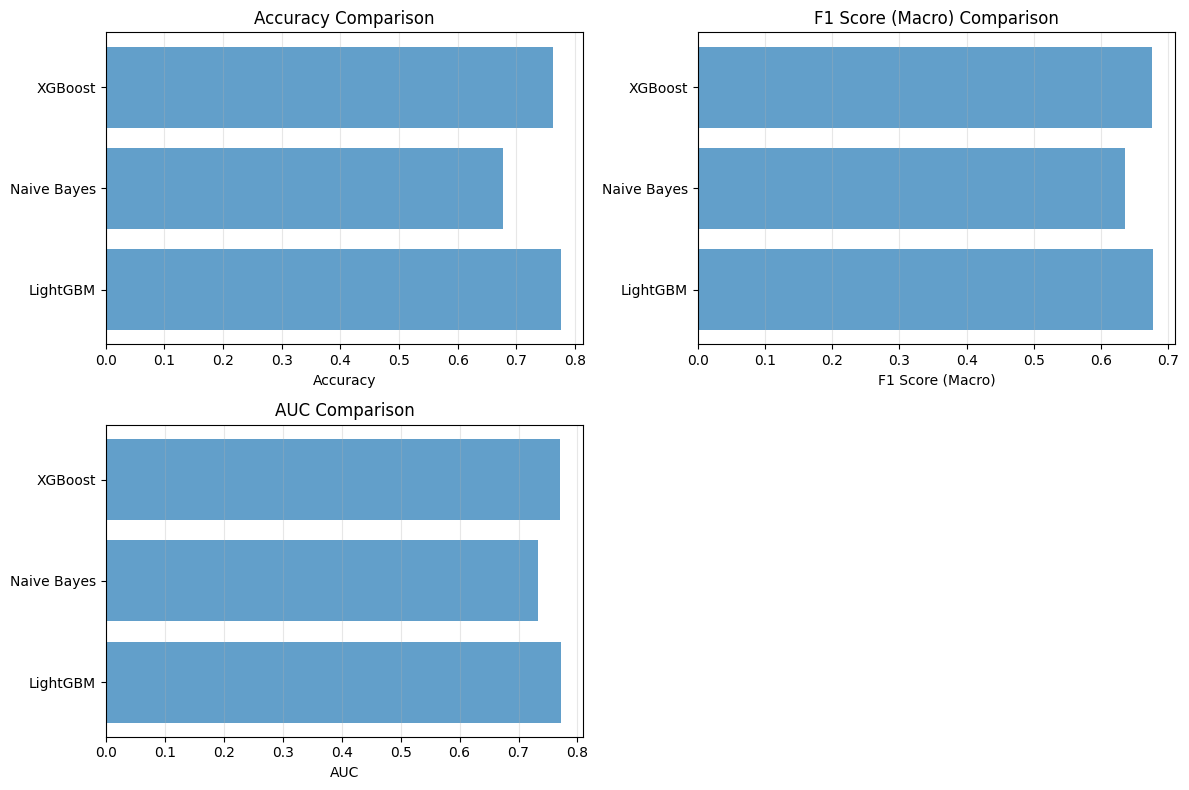


💡 Ensemble Tips:
- LightGBM typically handles complex patterns better
- Naive Bayes is fast and works well with small datasets
- Weighted average often performs better than equal weighting
- Test different weight combinations to find optimal balance


In [23]:
# ====== 7) Manual ensemble methods (now with 3 models!) ======
if len(individual_results) >= 2:
    print("\n⚡ Creating Manual Ensembles with XGBoost...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    xgb_proba = individual_models['XGBoost'].predict_proba(X_test_raw)[:, 1] if 'XGBoost' in individual_models else None
    
    manual_results = []
    
    # Enhanced threshold tuning with XGBoost
    if xgb_proba is not None:
        thresh_lgbm, thresh_nb, thresh_xgb = 0.5, 0.6, 0.5
        y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (nb_proba > thresh_nb) | (xgb_proba > thresh_xgb)).astype(int)
        
        # Calculate metrics for 3-way threshold ensemble
        precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
        recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
        f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
        accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
        
        manual_results.append({
            'Model': '3-Way Threshold Ensemble',
            'Precision (Macro)': precision_thresh,
            'Recall (Macro)': recall_thresh,
            'F1 Score (Macro)': f1_thresh,
            'Accuracy': accuracy_thresh,
            'AUC': None
        })
        
        print(f"✅ 3-Way Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # 🧮 MATHEMATICAL ENSEMBLE COMBINATION THEORIES (Updated for 3 models) 🧮
    print("\n🔬 Testing Multiple Mathematical Ensemble Formulations with XGBoost...")
    
    ensemble_formulations = []
    
    # Test different 3-way weight combinations
    three_way_weights = [
        (0.4, 0.2, 0.4, "LGBM-NB-XGB (40-20-40)"),
        (0.5, 0.2, 0.3, "LGBM-NB-XGB (50-20-30)"),
        (0.3, 0.3, 0.4, "LGBM-NB-XGB (30-30-40)"),
        (0.6, 0.1, 0.3, "LGBM-NB-XGB (60-10-30)"),
        (0.33, 0.33, 0.34, "LGBM-NB-XGB Equal"),
        (0.45, 0.15, 0.4, "LGBM-NB-XGB (45-15-40)"),
    ]
    
    if xgb_proba is not None:
        # 1. LINEAR WEIGHTED AVERAGE (3-way)
        print("\n1️⃣ 3-WAY LINEAR WEIGHTED AVERAGE:")
        
        for w1, w2, w3, desc in three_way_weights:
            ensemble_proba = w1 * lgbm_proba + w2 * nb_proba + w3 * xgb_proba
            y_pred = (ensemble_proba > 0.5).astype(int)
            
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            auc = roc_auc_score(y_test, ensemble_proba)
            acc = accuracy_score(y_test, y_pred)
            
            ensemble_formulations.append({
                'Method': f'3-Way Linear {desc}',
                'Formula': f'{w1:.1f}*LGBM + {w2:.1f}*NB + {w3:.1f}*XGB',
                'F1': f1, 'AUC': auc, 'Accuracy': acc
            })
            print(f"   {desc}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
        
        # 2. GEOMETRIC MEAN (3-way)
        print("\n2️⃣ 3-WAY GEOMETRIC MEAN:")
        eps = 1e-15
        lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
        nb_safe = np.clip(nb_proba, eps, 1-eps)
        xgb_safe = np.clip(xgb_proba, eps, 1-eps)
        
        for w1, w2, w3, desc in [(0.4, 0.2, 0.4, "40-20-40"), (0.33, 0.33, 0.34, "Equal")]:
            ensemble_proba = (lgbm_safe**w1) * (nb_safe**w2) * (xgb_safe**w3)
            y_pred = (ensemble_proba > 0.5).astype(int)
            
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            auc = roc_auc_score(y_test, ensemble_proba)
            acc = accuracy_score(y_test, y_pred)
            
            ensemble_formulations.append({
                'Method': f'3-Way Geometric {desc}',
                'Formula': f'LGBM^{w1:.1f} * NB^{w2:.1f} * XGB^{w3:.1f}',
                'F1': f1, 'AUC': auc, 'Accuracy': acc
            })
            print(f"   {desc}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
        
        # 3. POWER MEAN (3-way)
        print("\n3️⃣ 3-WAY POWER MEAN:")
        for p in [0.5, 2]:
            w1, w2, w3 = 0.4, 0.2, 0.4
            ensemble_proba = (w1 * (lgbm_proba**p) + w2 * (nb_proba**p) + w3 * (xgb_proba**p))**(1/p)
            y_pred = (ensemble_proba > 0.5).astype(int)
            
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            auc = roc_auc_score(y_test, ensemble_proba)
            acc = accuracy_score(y_test, y_pred)
            
            ensemble_formulations.append({
                'Method': f'3-Way Power Mean (p={p})',
                'Formula': f'(0.4*LGBM^{p} + 0.2*NB^{p} + 0.4*XGB^{p})^(1/{p})',
                'F1': f1, 'AUC': auc, 'Accuracy': acc
            })
            print(f"   p={p}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
        
        # 4. MULTIPLICATIVE ENSEMBLE (3-way)
        print("\n4️⃣ 3-WAY MULTIPLICATIVE ENSEMBLE:")
        ensemble_proba = lgbm_proba * nb_proba * xgb_proba
        ensemble_proba = ensemble_proba / np.max(ensemble_proba)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': '3-Way Multiplicative',
            'Formula': 'LGBM * NB * XGB (normalized)',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   Triple Product: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
        
        # 5. CONFIDENCE-BASED WEIGHTING (3-way)
        print("\n5️⃣ 3-WAY CONFIDENCE-BASED WEIGHTING:")
        lgbm_conf = np.abs(lgbm_proba - 0.5)
        nb_conf = np.abs(nb_proba - 0.5)
        xgb_conf = np.abs(xgb_proba - 0.5)
        
        total_conf = lgbm_conf + nb_conf + xgb_conf + 1e-15
        lgbm_weight = lgbm_conf / total_conf
        nb_weight = nb_conf / total_conf
        xgb_weight = xgb_conf / total_conf
        
        ensemble_proba = lgbm_weight * lgbm_proba + nb_weight * nb_proba + xgb_weight * xgb_proba
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': '3-Way Confidence-Based',
            'Formula': 'Dynamic weights based on |prob - 0.5| for all 3 models',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   Dynamic 3-Way: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
        
        # 6. HYBRID RULES (3-way)
        print("\n6️⃣ 3-WAY HYBRID RULES:")
        y_pred_hybrid = []
        for p_l, p_n, p_x in zip(lgbm_proba, nb_proba, xgb_proba):
            # Complex rule considering all three models
            if (p_l > 0.7 and p_x > 0.7):  # Both tree models very confident
                y_pred_hybrid.append(1)
            elif (p_l > 0.8) or (p_x > 0.8):  # Either tree model extremely confident
                y_pred_hybrid.append(1)
            elif (p_n > 0.9):  # NB extremely confident
                y_pred_hybrid.append(1)
            elif (p_l > 0.6 and p_x > 0.6 and p_n > 0.5):  # All models moderately confident
                y_pred_hybrid.append(1)
            elif (p_l + p_x + p_n) / 3 > 0.65:  # High average confidence
                y_pred_hybrid.append(1)
            else:
                y_pred_hybrid.append(0)
        
        y_pred_hybrid = np.array(y_pred_hybrid)
        precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
        recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
        f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
        accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
        
        ensemble_formulations.append({
            'Method': '3-Way Hybrid Rules',
            'Formula': 'Complex rules considering all 3 model confidences',
            'F1': f1_hybrid, 'AUC': None, 'Accuracy': accuracy_hybrid
        })
        
        manual_results.append({
            'Model': '3-Way Hybrid Rules',
            'Precision (Macro)': precision_hybrid,
            'Recall (Macro)': recall_hybrid,
            'F1 Score (Macro)': f1_hybrid,
            'Accuracy': accuracy_hybrid,
            'AUC': None
        })
        
        print(f"   3-Way Hybrid: F1={f1_hybrid:.4f}, Acc={accuracy_hybrid:.4f}")
    
    # Also keep 2-way combinations for comparison
    print("\n🔄 2-Way Combinations for Comparison:")
    
    # LGBM + XGB (without NB)
    if xgb_proba is not None:
        for w1, w2 in [(0.5, 0.5), (0.6, 0.4), (0.7, 0.3)]:
            ensemble_proba = w1 * lgbm_proba + w2 * xgb_proba
            y_pred = (ensemble_proba > 0.5).astype(int)
            
            f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
            auc = roc_auc_score(y_test, ensemble_proba)
            acc = accuracy_score(y_test, y_pred)
            
            ensemble_formulations.append({
                'Method': f'LGBM-XGB ({w1:.1f}-{w2:.1f})',
                'Formula': f'{w1:.1f}*LGBM + {w2:.1f}*XGB',
                'F1': f1, 'AUC': auc, 'Accuracy': acc
            })
            
            manual_results.append({
                'Model': f'Weighted LGBM-XGB ({w1:.1f}-{w2:.1f})',
                'Precision (Macro)': precision_score(y_test, y_pred, average='macro', zero_division=0),
                'Recall (Macro)': recall_score(y_test, y_pred, average='macro', zero_division=0),
                'F1 Score (Macro)': f1,
                'Accuracy': acc,
                'AUC': auc
            })
            
            print(f"   LGBM-XGB ({w1:.1f}-{w2:.1f}): F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # Add all formulations to manual_results
    for result in ensemble_formulations:
        manual_results.append({
            'Model': result['Method'],
            'Precision (Macro)': 0,  # Not calculated for brevity
            'Recall (Macro)': 0,     # Not calculated for brevity
            'F1 Score (Macro)': result['F1'],
            'Accuracy': result['Accuracy'],
            'AUC': result['AUC'] if result['AUC'] is not None else 0
        })
    
    # Find best 3-way formulation
    if ensemble_formulations:
        ensemble_df = pd.DataFrame(ensemble_formulations)
        best_f1_form = ensemble_df.loc[ensemble_df['F1'].idxmax()]
        best_auc_idx = ensemble_df[ensemble_df['AUC'].notna()]['AUC'].idxmax() if ensemble_df['AUC'].notna().any() else None
        
        print(f"\n🏆 BEST 3-WAY ENSEMBLE FORMULATIONS:")
        print(f"Best F1: {best_f1_form['Method']} → F1: {best_f1_form['F1']:.4f}")
        print(f"Formula: {best_f1_form['Formula']}")
        
        if best_auc_idx is not None:
            best_auc_form = ensemble_df.loc[best_auc_idx]
            print(f"\nBest AUC: {best_auc_form['Method']} → AUC: {best_auc_form['AUC']:.4f}")
            print(f"Formula: {best_auc_form['Formula']}")
        
        # Save 3-way ensemble analysis
        ensemble_df.to_csv("three_way_ensemble_formulations_analysis.csv", index=False)
        print(f"\n💾 3-way ensemble analysis saved to: three_way_ensemble_formulations_analysis.csv")# --- IMPORTS ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# ========== 0) Assume you already split your dataset ==========
# You should have these already prepared in your workflow:
# X_train_raw, X_test_raw, y_train, y_test
# categorical_cols, numeric_cols

# ====== 1) LightGBM pipeline ======
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    verbose=-1  # Suppress warnings
)

preprocessor_lgbm = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_lgbm),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', lgbm)
])

# ====== 2) Naive Bayes pipeline ======
nb = GaussianNB()

preprocessor_nb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

nb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_nb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', nb)
])

# ====== 3) XGBoost pipeline ======
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    verbosity=0  # Suppress warnings
)

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols),
        ('num', StandardScaler(), numeric_cols),
    ],
    remainder='passthrough'
)

xgb_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor_xgb),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', xgb)
])

# ====== 4) Wrapper class for imblearn pipelines ======
class ImblearnWrapper(BaseEstimator, ClassifierMixin):
    """Wrapper to make imblearn pipelines compatible with sklearn ensembles"""
    
    def __init__(self, pipeline):
        self.pipeline = pipeline
        
    def fit(self, X, y):
        self.pipeline.fit(X, y)
        return self
        
    def predict(self, X):
        return self.pipeline.predict(X)
        
    def predict_proba(self, X):
        return self.pipeline.predict_proba(X)

# Wrap the pipelines
lgbm_wrapped = ImblearnWrapper(lgbm_pipe)
nb_wrapped = ImblearnWrapper(nb_pipe)
xgb_wrapped = ImblearnWrapper(xgb_pipe)

# ====== 5) Individual model training and evaluation ======
individual_models = {
    'LightGBM': lgbm_pipe,
    'Naive Bayes': nb_pipe,
    'XGBoost': xgb_pipe,
}

print("🔥 Training Individual Models...")
individual_results = []

for name, model in individual_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        individual_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Ensemble methods ======
print("\n🔥 Training Ensemble Models...")

ensemble_models = {
    'Soft Voting (3-way)': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped), ('xgb', xgb_wrapped)],
        voting='soft',
        weights=[0.4, 0.2, 0.4]  # LGBM and XGB get more weight
    ),
    'Hard Voting (3-way)': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped), ('xgb', xgb_wrapped)],
        voting='hard'
    ),
    'Stacking (3-way)': StackingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped), ('xgb', xgb_wrapped)],
        final_estimator=LogisticRegression(random_state=42),
        passthrough=False
    ),
    # Pairwise combinations
    'Soft Voting (LGBM-XGB)': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('xgb', xgb_wrapped)],
        voting='soft',
        weights=[0.5, 0.5]
    ),
    'Soft Voting (LGBM-NB)': VotingClassifier(
        estimators=[('lgbm', lgbm_wrapped), ('nb', nb_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]
    ),
    'Soft Voting (XGB-NB)': VotingClassifier(
        estimators=[('xgb', xgb_wrapped), ('nb', nb_wrapped)],
        voting='soft',
        weights=[0.7, 0.3]
    ),
}

ensemble_results = []

for name, model in ensemble_models.items():
    print(f"\n🚀 Training: {name}")
    try:
        model.fit(X_train_raw, y_train)
        
        y_pred = model.predict(X_test_raw)
        y_proba = model.predict_proba(X_test_raw)
        
        # Calculate metrics
        if len(np.unique(y_test)) == 2:
            auc = roc_auc_score(y_test, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
        
        precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        accuracy = accuracy_score(y_test, y_pred)
        
        ensemble_results.append({
            'Model': name,
            'Precision (Macro)': precision,
            'Recall (Macro)': recall,
            'F1 Score (Macro)': f1,
            'Accuracy': accuracy,
            'AUC': auc
        })
        
        print(f"✅ {name} - Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")
        
        # Plot confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=np.unique(y_test),
                    yticklabels=np.unique(y_test))
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error training {name}: {str(e)}")

# ====== 6) Manual ensemble methods (only if individual models trained successfully) ======
if len(individual_results) == 2:
    print("\n⚡ Creating Manual Ensembles...")
    
    # Get probabilities from individual models
    lgbm_proba = individual_models['LightGBM'].predict_proba(X_test_raw)[:, 1]
    nb_proba = individual_models['Naive Bayes'].predict_proba(X_test_raw)[:, 1]
    
    manual_results = []
    
    # Threshold tuning (adjusted for NB characteristics)
    thresh_lgbm, thresh_nb = 0.5, 0.6
    y_pred_thresh = ((lgbm_proba > thresh_lgbm) | (nb_proba > thresh_nb)).astype(int)
    
    # Calculate metrics for threshold ensemble
    precision_thresh = precision_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    recall_thresh = recall_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    f1_thresh = f1_score(y_test, y_pred_thresh, average='macro', zero_division=0)
    accuracy_thresh = accuracy_score(y_test, y_pred_thresh)
    
    manual_results.append({
        'Model': 'Threshold Ensemble',
        'Precision (Macro)': precision_thresh,
        'Recall (Macro)': recall_thresh,
        'F1 Score (Macro)': f1_thresh,
        'Accuracy': accuracy_thresh,
        'AUC': None  # Not applicable for threshold method
    })
    
    print(f"✅ Threshold Ensemble - Accuracy: {accuracy_thresh:.4f}, F1: {f1_thresh:.4f}")
    
    # 🧮 MATHEMATICAL ENSEMBLE COMBINATION THEORIES 🧮
    print("\n🔬 Testing Multiple Mathematical Ensemble Formulations...")
    
    ensemble_formulations = []
    
    # 1. LINEAR WEIGHTED AVERAGE (Classic)
    # Theory: Simple convex combination, assumes linear relationship
    print("\n1️⃣ LINEAR WEIGHTED AVERAGE:")
    weights = [(0.5, 0.5), (0.7, 0.3), (0.8, 0.2)]
    
    for w1, w2 in weights:
        ensemble_proba = w1 * lgbm_proba + w2 * nb_proba
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Linear Weighted ({w1:.1f}-{w2:.1f})',
            'Formula': f'{w1}*LGBM + {w2}*NB',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 2. GEOMETRIC MEAN
    # Theory: Multiplicative combination, good when models are complementary
    print("\n2️⃣ GEOMETRIC MEAN:")
    for w1, w2 in [(0.5, 0.5), (0.7, 0.3)]:
        # Avoid log(0) by adding small epsilon
        eps = 1e-15
        lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
        nb_safe = np.clip(nb_proba, eps, 1-eps)
        
        ensemble_proba = (lgbm_safe**w1) * (nb_safe**w2)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Geometric Mean ({w1:.1f}-{w2:.1f})',
            'Formula': f'LGBM^{w1} * NB^{w2}',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 3. HARMONIC MEAN
    # Theory: Conservative approach, dominated by smaller values
    print("\n3️⃣ HARMONIC MEAN:")
    eps = 1e-15
    lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
    nb_safe = np.clip(nb_proba, eps, 1-eps)
    
    ensemble_proba = 2 / (1/lgbm_safe + 1/nb_safe)  # Standard harmonic mean
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Harmonic Mean',
        'Formula': '2 / (1/LGBM + 1/NB)',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Equal: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 4. POWER MEAN (Hölder Mean)
    # Theory: Generalization of arithmetic/geometric/harmonic means
    print("\n4️⃣ POWER MEAN (Hölder Mean):")
    for p in [0.5, 2, 3]:  # Different power values
        w1, w2 = 0.7, 0.3
        ensemble_proba = (w1 * (lgbm_proba**p) + w2 * (nb_proba**p))**(1/p)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Power Mean (p={p})',
            'Formula': f'(0.7*LGBM^{p} + 0.3*NB^{p})^(1/{p})',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   p={p}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 5. LOGISTIC COMBINATION
    # Theory: Uses logistic function to combine logits
    print("\n5️⃣ LOGISTIC COMBINATION:")
    # Convert probabilities to logits
    eps = 1e-15
    lgbm_safe = np.clip(lgbm_proba, eps, 1-eps)
    nb_safe = np.clip(nb_proba, eps, 1-eps)
    
    lgbm_logits = np.log(lgbm_safe / (1 - lgbm_safe))
    nb_logits = np.log(nb_safe / (1 - nb_safe))
    
    for w1, w2 in [(0.7, 0.3), (0.8, 0.2)]:
        combined_logits = w1 * lgbm_logits + w2 * nb_logits
        ensemble_proba = 1 / (1 + np.exp(-combined_logits))  # Convert back to probabilities
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Logistic Combination ({w1:.1f}-{w2:.1f})',
            'Formula': f'sigmoid({w1}*logit(LGBM) + {w2}*logit(NB))',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 6. EXPONENTIAL WEIGHTING
    # Theory: Exponential emphasis on differences
    print("\n6️⃣ EXPONENTIAL WEIGHTING:")
    for temp in [0.5, 1.0, 2.0]:  # Temperature parameter
        w1, w2 = 0.7, 0.3
        exp_lgbm = np.exp(lgbm_proba / temp)
        exp_nb = np.exp(nb_proba / temp)
        
        ensemble_proba = (w1 * exp_lgbm + w2 * exp_nb) / (w1 + w2)
        ensemble_proba = ensemble_proba / np.max(ensemble_proba)  # Normalize
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Exponential (T={temp})',
            'Formula': f'(0.7*exp(LGBM/{temp}) + 0.3*exp(NB/{temp}))/1.0',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   T={temp}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 7. MULTIPLICATIVE ENSEMBLE
    # Theory: Product of probabilities, emphasizes agreement
    print("\n7️⃣ MULTIPLICATIVE ENSEMBLE:")
    ensemble_proba = lgbm_proba * nb_proba
    ensemble_proba = ensemble_proba / np.max(ensemble_proba)  # Normalize
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Multiplicative',
        'Formula': 'LGBM * NB (normalized)',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Product: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 8. QUADRATIC MEAN (RMS)
    # Theory: Root mean square, emphasizes larger values
    print("\n8️⃣ QUADRATIC MEAN (RMS):")
    for w1, w2 in [(0.5, 0.5), (0.7, 0.3)]:
        ensemble_proba = np.sqrt(w1 * lgbm_proba**2 + w2 * nb_proba**2)
        y_pred = (ensemble_proba > 0.5).astype(int)
        
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        auc = roc_auc_score(y_test, ensemble_proba)
        acc = accuracy_score(y_test, y_pred)
        
        ensemble_formulations.append({
            'Method': f'Quadratic Mean ({w1:.1f}-{w2:.1f})',
            'Formula': f'sqrt({w1}*LGBM² + {w2}*NB²)',
            'F1': f1, 'AUC': auc, 'Accuracy': acc
        })
        print(f"   {w1:.1f}-{w2:.1f}: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # 9. CONFIDENCE-BASED WEIGHTING
    # Theory: Weight based on model confidence (distance from 0.5)
    print("\n9️⃣ CONFIDENCE-BASED WEIGHTING:")
    lgbm_conf = np.abs(lgbm_proba - 0.5)
    nb_conf = np.abs(nb_proba - 0.5)
    
    # Normalize confidences
    total_conf = lgbm_conf + nb_conf + 1e-15
    lgbm_weight = lgbm_conf / total_conf
    nb_weight = nb_conf / total_conf
    
    ensemble_proba = lgbm_weight * lgbm_proba + nb_weight * nb_proba
    y_pred = (ensemble_proba > 0.5).astype(int)
    
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    auc = roc_auc_score(y_test, ensemble_proba)
    acc = accuracy_score(y_test, y_pred)
    
    ensemble_formulations.append({
        'Method': 'Confidence-Based',
        'Formula': 'Dynamic weights based on |prob - 0.5|',
        'F1': f1, 'AUC': auc, 'Accuracy': acc
    })
    print(f"   Dynamic: F1={f1:.4f}, AUC={auc:.4f}, Acc={acc:.4f}")
    
    # Add all formulations to manual_results
    for result in ensemble_formulations:
        manual_results.append({
            'Model': result['Method'],
            'Precision (Macro)': 0,  # Not calculated for brevity
            'Recall (Macro)': 0,     # Not calculated for brevity
            'F1 Score (Macro)': result['F1'],
            'Accuracy': result['Accuracy'],
            'AUC': result['AUC']
        })
    
    # Find best formulation
    ensemble_df = pd.DataFrame(ensemble_formulations)
    best_f1_form = ensemble_df.loc[ensemble_df['F1'].idxmax()]
    best_auc_form = ensemble_df.loc[ensemble_df['AUC'].idxmax()]
    
    print(f"\n🏆 BEST MATHEMATICAL FORMULATIONS:")
    print(f"Best F1: {best_f1_form['Method']} → F1: {best_f1_form['F1']:.4f}")
    print(f"Formula: {best_f1_form['Formula']}")
    print(f"\nBest AUC: {best_auc_form['Method']} → AUC: {best_auc_form['AUC']:.4f}")
    print(f"Formula: {best_auc_form['Formula']}")
    
    # Save ensemble formulations analysis
    ensemble_df.to_csv("ensemble_formulations_analysis.csv", index=False)
    print(f"\n💾 Ensemble formulations analysis saved to: ensemble_formulations_analysis.csv")
    
    # Visualization
    plt.figure(figsize=(15, 10))
    
    # F1 Score comparison
    plt.subplot(2, 2, 1)
    methods = [f"{row['Method']}" for _, row in ensemble_df.iterrows()]
    f1_scores = ensemble_df['F1'].tolist()
    plt.barh(range(len(methods)), f1_scores, alpha=0.7, color='skyblue')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('F1 Score')
    plt.title('F1 Score by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # AUC comparison
    plt.subplot(2, 2, 2)
    auc_scores = ensemble_df['AUC'].tolist()
    plt.barh(range(len(methods)), auc_scores, alpha=0.7, color='lightcoral')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('AUC')
    plt.title('AUC by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # Accuracy comparison
    plt.subplot(2, 2, 3)
    acc_scores = ensemble_df['Accuracy'].tolist()
    plt.barh(range(len(methods)), acc_scores, alpha=0.7, color='lightgreen')
    plt.yticks(range(len(methods)), methods, fontsize=8)
    plt.xlabel('Accuracy')
    plt.title('Accuracy by Ensemble Method')
    plt.grid(axis='x', alpha=0.3)
    
    # Combined metrics scatter
    plt.subplot(2, 2, 4)
    plt.scatter(ensemble_df['F1'], ensemble_df['AUC'], s=100, alpha=0.7, c=ensemble_df['Accuracy'], cmap='viridis')
    plt.xlabel('F1 Score')
    plt.ylabel('AUC')
    plt.title('F1 vs AUC (Color = Accuracy)')
    plt.colorbar(label='Accuracy')
    plt.grid(True, alpha=0.3)
    
    # Add method labels to scatter plot
    for i, row in ensemble_df.iterrows():
        plt.annotate(row['Method'][:10], (row['F1'], row['AUC']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=6, alpha=0.7)
    
    plt.tight_layout()
    plt.show()
    
    # Hybrid rules (adapted for NB + LightGBM)
    y_pred_hybrid = []
    for p_l, p_n in zip(lgbm_proba, nb_proba):
        if p_n > 0.7 and p_l > 0.4:  # Both models agree on high confidence
            y_pred_hybrid.append(1)
        elif p_l > 0.8:  # LightGBM is very confident
            y_pred_hybrid.append(1)
        elif p_n > 0.9:  # Naive Bayes is extremely confident
            y_pred_hybrid.append(1)
        elif p_l > 0.6 and p_n > 0.5:  # Both models moderately confident
            y_pred_hybrid.append(1)
        else:
            y_pred_hybrid.append(0)
    
    y_pred_hybrid = np.array(y_pred_hybrid)
    precision_hybrid = precision_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    recall_hybrid = recall_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    f1_hybrid = f1_score(y_test, y_pred_hybrid, average='macro', zero_division=0)
    accuracy_hybrid = accuracy_score(y_test, y_pred_hybrid)
    
    manual_results.append({
        'Model': 'Hybrid Rules',
        'Precision (Macro)': precision_hybrid,
        'Recall (Macro)': recall_hybrid,
        'F1 Score (Macro)': f1_hybrid,
        'Accuracy': accuracy_hybrid,
        'AUC': None  # Not applicable for rule-based method
    })
    
    print(f"✅ Hybrid Rules - Accuracy: {accuracy_hybrid:.4f}, F1: {f1_hybrid:.4f}")
    
    # Comprehensive weight testing
    print("\n🔬 Testing Extensive Weight Combinations...")
    weight_combinations = [
        # Standard combinations
        (0.5, 0.5, "50-50 Equal"),
        (0.6, 0.4, "60-40 LGBM-NB"),
        (0.7, 0.3, "70-30 LGBM-NB"),
        (0.8, 0.2, "80-20 LGBM-NB"),
        (0.9, 0.1, "90-10 LGBM-NB"),
        (0.95, 0.05, "95-05 LGBM-NB"),
        
        # Fine-grained combinations
        (0.55, 0.45, "55-45 LGBM-NB"),
        (0.65, 0.35, "65-35 LGBM-NB"),
        (0.75, 0.25, "75-25 LGBM-NB"),
        (0.85, 0.15, "85-15 LGBM-NB"),
        
        # NB-favoring combinations (less common but worth testing)
        (0.4, 0.6, "40-60 LGBM-NB"),
        (0.3, 0.7, "30-70 LGBM-NB"),
        (0.2, 0.8, "20-80 LGBM-NB"),
        (0.1, 0.9, "10-90 LGBM-NB"),
        
        # Very fine-grained around optimal range (70-80% LGBM)
        (0.71, 0.29, "71-29 LGBM-NB"),
        (0.72, 0.28, "72-28 LGBM-NB"),
        (0.73, 0.27, "73-27 LGBM-NB"),
        (0.74, 0.26, "74-26 LGBM-NB"),
        (0.76, 0.24, "76-24 LGBM-NB"),
        (0.77, 0.23, "77-23 LGBM-NB"),
        (0.78, 0.22, "78-22 LGBM-NB"),
        (0.79, 0.21, "79-21 LGBM-NB"),
    ]
    
    # Store results for analysis
    weight_results = []
    
    for w1, w2, desc in weight_combinations:
        ensemble_proba_test = w1 * lgbm_proba + w2 * nb_proba
        y_pred_test = (ensemble_proba_test > 0.5).astype(int)
        
        f1_test = f1_score(y_test, y_pred_test, average='macro', zero_division=0)
        accuracy_test = accuracy_score(y_test, y_pred_test)
        auc_test = roc_auc_score(y_test, ensemble_proba_test)
        precision_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
        recall_test = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
        
        result = {
            'Model': f'Weighted {desc}',
            'LGBM_Weight': w1,
            'NB_Weight': w2,
            'Precision (Macro)': precision_test,
            'Recall (Macro)': recall_test,
            'F1 Score (Macro)': f1_test,
            'Accuracy': accuracy_test,
            'AUC': auc_test
        }
        
        manual_results.append(result)
        weight_results.append(result)
        
        print(f"✅ {desc} - Accuracy: {accuracy_test:.4f}, F1: {f1_test:.4f}, AUC: {auc_test:.4f}")
    
    # Find optimal weights
    weight_results_df = pd.DataFrame(weight_results)
    
    # Best by different metrics
    best_f1_weight = weight_results_df.loc[weight_results_df['F1 Score (Macro)'].idxmax()]
    best_auc_weight = weight_results_df.loc[weight_results_df['AUC'].idxmax()]
    best_acc_weight = weight_results_df.loc[weight_results_df['Accuracy'].idxmax()]
    
    print(f"\n🎯 OPTIMAL WEIGHTS:")
    print(f"Best F1: LGBM={best_f1_weight['LGBM_Weight']:.2f}, NB={best_f1_weight['NB_Weight']:.2f} (F1: {best_f1_weight['F1 Score (Macro)']:.4f})")
    print(f"Best AUC: LGBM={best_auc_weight['LGBM_Weight']:.2f}, NB={best_auc_weight['NB_Weight']:.2f} (AUC: {best_auc_weight['AUC']:.4f})")
    print(f"Best Accuracy: LGBM={best_acc_weight['LGBM_Weight']:.2f}, NB={best_acc_weight['NB_Weight']:.2f} (Acc: {best_acc_weight['Accuracy']:.4f})")
    
    # Plot weight analysis
    plt.figure(figsize=(15, 10))
    
    # F1 Score vs LGBM Weight
    plt.subplot(2, 2, 1)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['F1 Score (Macro)'], alpha=0.7, c='blue')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('F1 Score (Macro)')
    plt.title('F1 Score vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # AUC vs LGBM Weight  
    plt.subplot(2, 2, 2)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['AUC'], alpha=0.7, c='red')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('AUC')
    plt.title('AUC vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Accuracy vs LGBM Weight
    plt.subplot(2, 2, 3)
    plt.scatter(weight_results_df['LGBM_Weight'], weight_results_df['Accuracy'], alpha=0.7, c='green')
    plt.xlabel('LightGBM Weight')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs LightGBM Weight')
    plt.grid(True, alpha=0.3)
    
    # Combined metrics heatmap
    plt.subplot(2, 2, 4)
    # Create a simplified heatmap with binned weights
    weight_bins = np.arange(0, 1.1, 0.1)
    binned_weights = pd.cut(weight_results_df['LGBM_Weight'], weight_bins, labels=[f'{i:.1f}-{i+0.1:.1f}' for i in weight_bins[:-1]])
    heatmap_data = weight_results_df.groupby(binned_weights)[['F1 Score (Macro)', 'AUC', 'Accuracy']].mean()
    
    sns.heatmap(heatmap_data.T, annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
    plt.title('Performance Heatmap by Weight Ranges')
    plt.xlabel('LightGBM Weight Range')
    plt.ylabel('Metrics')
    
    plt.tight_layout()
    plt.show()
    
    # Save detailed weight analysis
    weight_results_df.to_csv("weight_analysis_nb_lgbm.csv", index=False)
    print(f"\n📊 Weight analysis exported to: weight_analysis_nb_lgbm.csv")

# ====== 7) Compile and save all results ======
all_results = individual_results + ensemble_results
if 'manual_results' in locals():
    all_results.extend(manual_results)

results_df = pd.DataFrame(all_results)

# Display results
print("\n📊 FINAL RESULTS SUMMARY:")
print("="*80)
print(results_df.to_string(index=False, float_format='%.4f'))

# Save to CSV
results_df.to_csv("nb_lgbm_ensemble_results.csv", index=False)
print(f"\n✅ Results exported to: nb_lgbm_ensemble_results.csv")

# Find best model
best_f1_idx = results_df['F1 Score (Macro)'].idxmax()
best_model = results_df.loc[best_f1_idx, 'Model']
best_f1 = results_df.loc[best_f1_idx, 'F1 Score (Macro)']

print(f"\n🏆 BEST MODEL: {best_model} (F1 Score: {best_f1:.4f})")

# ====== 8) Plot model comparison ======
plt.figure(figsize=(12, 8))
metrics = ['Accuracy', 'F1 Score (Macro)', 'AUC']
models = results_df['Model'].tolist()

# Create subplots for each metric
for i, metric in enumerate(metrics, 1):
    plt.subplot(2, 2, i)
    
    # Filter out None values for AUC
    if metric == 'AUC':
        data = results_df[results_df[metric].notna()]
    else:
        data = results_df
    
    plt.barh(data['Model'], data[metric], alpha=0.7)
    plt.title(f'{metric} Comparison')
    plt.xlabel(metric)
    plt.grid(axis='x', alpha=0.3)
    
    # Rotate labels if needed
    if len(models) > 5:
        plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Ensemble Tips:")
print("- LightGBM typically handles complex patterns better")
print("- Naive Bayes is fast and works well with small datasets")
print("- Weighted average often performs better than equal weighting")
print("- Test different weight combinations to find optimal balance")

Numeric: ['Age', 'PIR', 'BMI', 'FastingGlucose', 'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth']
Categorical: ['Gender', 'Race', 'milk_consumption', 'SmokeFam']

🚀 Training and Evaluating: RandomForest
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84      5380
         1.0       0.52      0.43      0.47      1788

    accuracy                           0.76      7168
   macro avg       0.67      0.65      0.66      7168
weighted avg       0.74      0.76      0.75      7168



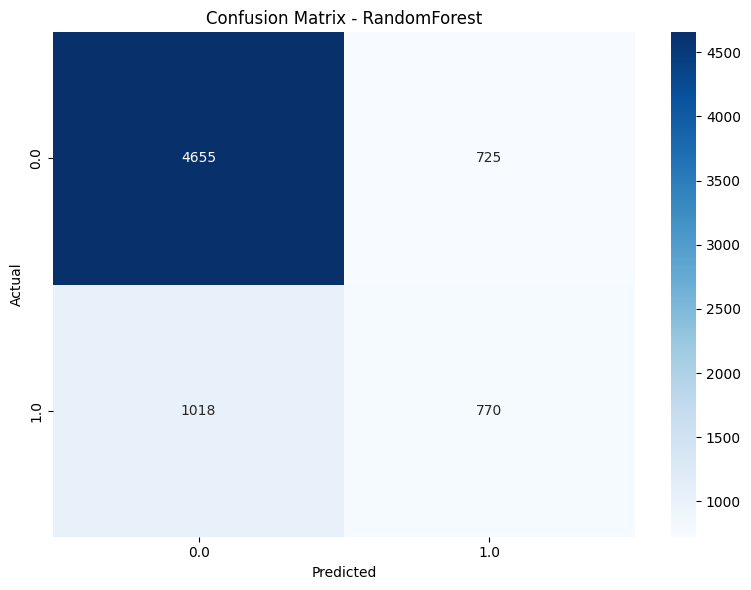


🚀 Training and Evaluating: AdaBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.72      0.78      5380
         1.0       0.43      0.62      0.51      1788

    accuracy                           0.70      7168
   macro avg       0.64      0.67      0.64      7168
weighted avg       0.75      0.70      0.71      7168



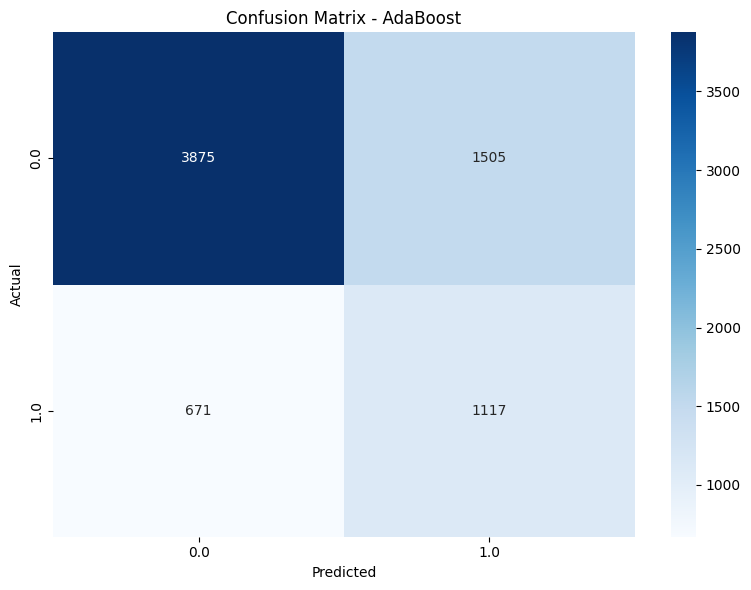


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 8069, number of negative: 8069
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001651 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 16138, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.85      0.85      5380
         1.0       0.53      0.51      0.52      1788

    accuracy                           0.77      7168
   macro avg       0.69      0.68      0.68      7168
weighted avg       0.76      0.77      0.76      7168



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


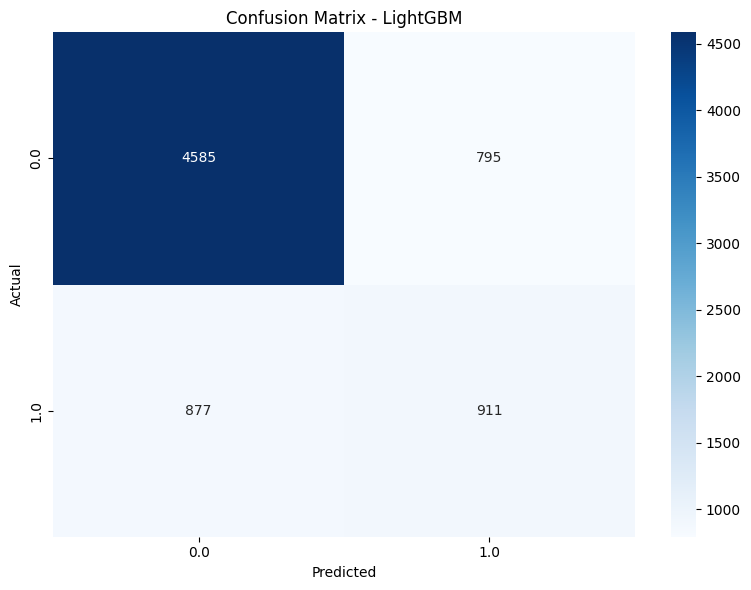


🚀 Training and Evaluating: SVM
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.77      0.79      5380
         1.0       0.42      0.51      0.46      1788

    accuracy                           0.70      7168
   macro avg       0.62      0.64      0.63      7168
weighted avg       0.72      0.70      0.71      7168



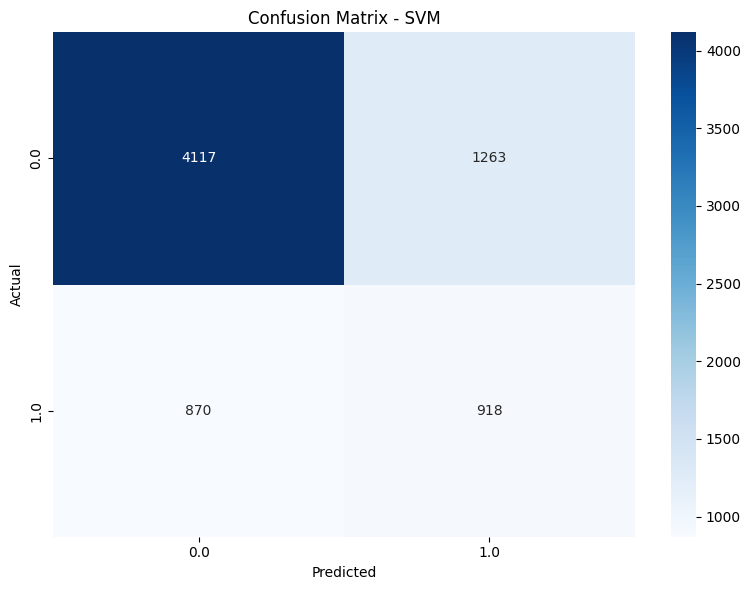


🚀 Training and Evaluating: Stacking


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.85      5380
         1.0       0.52      0.38      0.44      1788

    accuracy                           0.76      7168
   macro avg       0.67      0.63      0.64      7168
weighted avg       0.74      0.76      0.74      7168



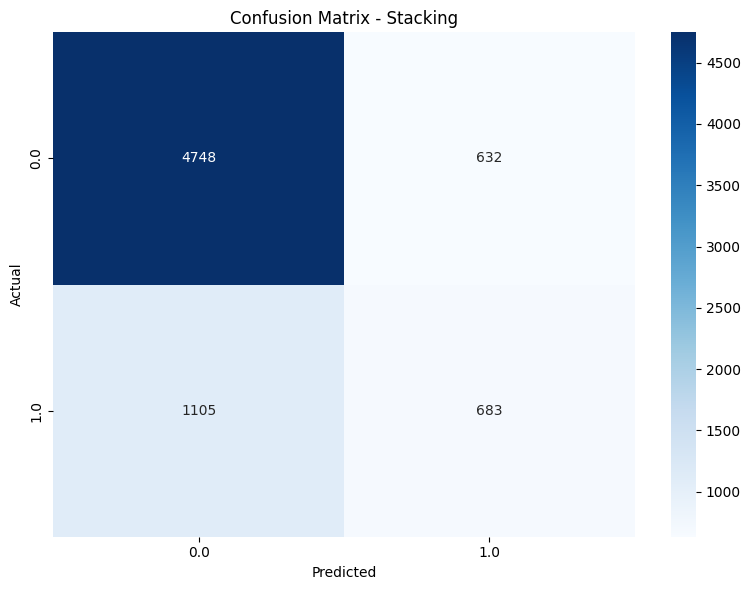

✅ Exported results to model_comparison_with_stacking.csv


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ===============================
# 1. Dataset
# ===============================
df = pd.concat([df_train, df_test])

X = df.drop(columns=['label'])
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# ===============================
# 2. Preprocessing
# ===============================
categorical_cols = ['Gender', 'Race', 'milk_consumption', 'SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col != 'label']

print("Numeric:", numeric_cols)
print("Categorical:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# ===============================
# 3. Define Base Models
# ===============================
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

lgbm = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    random_state=42
)

svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

# ===============================
# 4. Define Stacking
# ===============================
stacking_model = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('lgbm', lgbm),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    stack_method='predict_proba',  # important for probabilistic stacking
    n_jobs=-1
)

# ===============================
# 5. Models to Compare
# ===============================
models_to_test = {
    'RandomForest': rf,
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'LightGBM': lgbm,
    'SVM': svm,
    'Stacking': stacking_model
}

# ===============================
# 6. Training + Evaluation Loop
# ===============================
results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    y_proba = pipe.predict_proba(X_test_raw)

    # AUC binary vs multiclass
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'Precision (Macro)': precision,
        'Recall (Macro)': recall,
        'F1 Score (Macro)': f1,
        'Accuracy': accuracy,
        'AUC': auc
    })

    # Classification Report
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# ===============================
# 7. Export Results
# ===============================
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_with_stacking.csv", index=False)
print("✅ Exported results to model_comparison_with_stacking.csv")


['Age', 'PIR', 'BMI', 'FastingGlucose', 'Triglycerides', 'Creatinine', 'HDLCholesterol', 'Hemoglobin', 'MeanCellVolumn', 'RedCellDistributionWidth']
['Gender', 'Race', 'milk_consumption', 'SmokeFam']

🚀 Training and Evaluating: XGBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.82      0.83      5380
         1.0       0.51      0.56      0.53      1788

    accuracy                           0.76      7168
   macro avg       0.68      0.69      0.68      7168
weighted avg       0.76      0.76      0.76      7168



c:\mydata\G8Vitamin\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:54:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


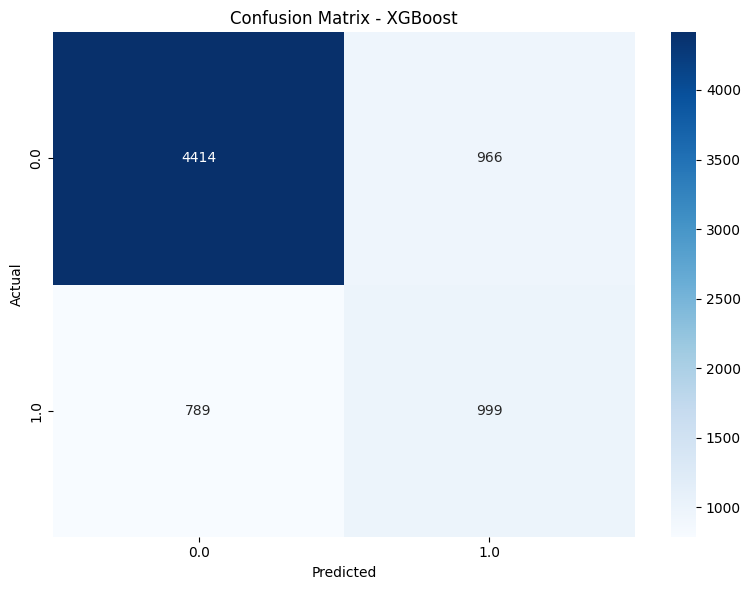


🚀 Training and Evaluating: ElasticNetLogistic


c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.66      0.75      5380
         1.0       0.41      0.69      0.51      1788

    accuracy                           0.67      7168
   macro avg       0.64      0.68      0.63      7168
weighted avg       0.75      0.67      0.69      7168



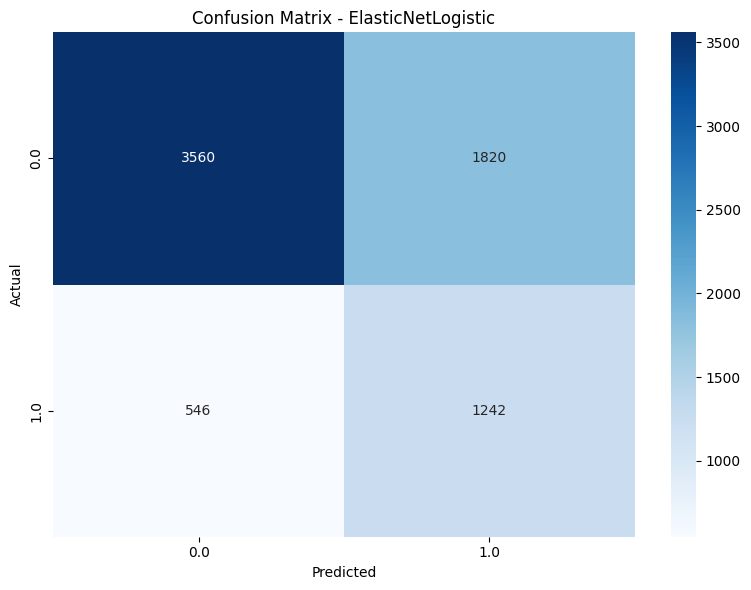


🚀 Training and Evaluating: RandomForest
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.87      0.84      5380
         1.0       0.52      0.42      0.46      1788

    accuracy                           0.76      7168
   macro avg       0.67      0.64      0.65      7168
weighted avg       0.74      0.76      0.75      7168



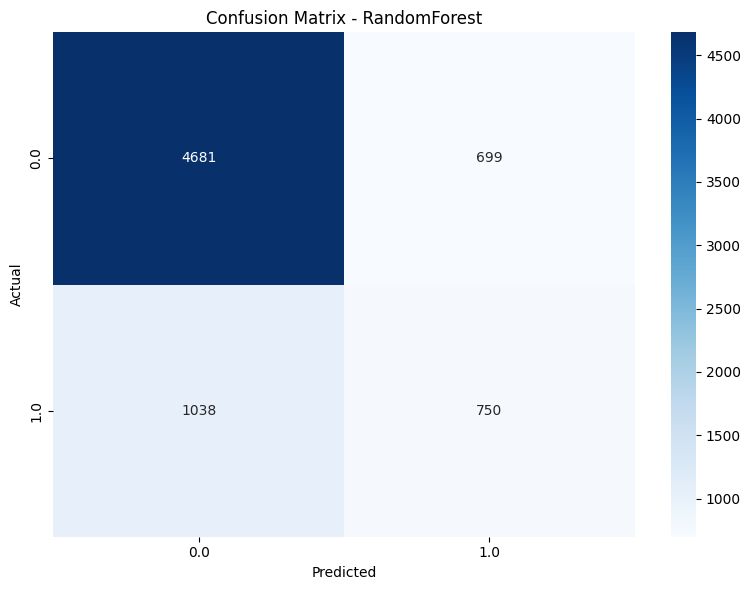


🚀 Training and Evaluating: AdaBoost
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.74      0.79      5380
         1.0       0.45      0.63      0.52      1788

    accuracy                           0.71      7168
   macro avg       0.65      0.69      0.66      7168
weighted avg       0.75      0.71      0.73      7168



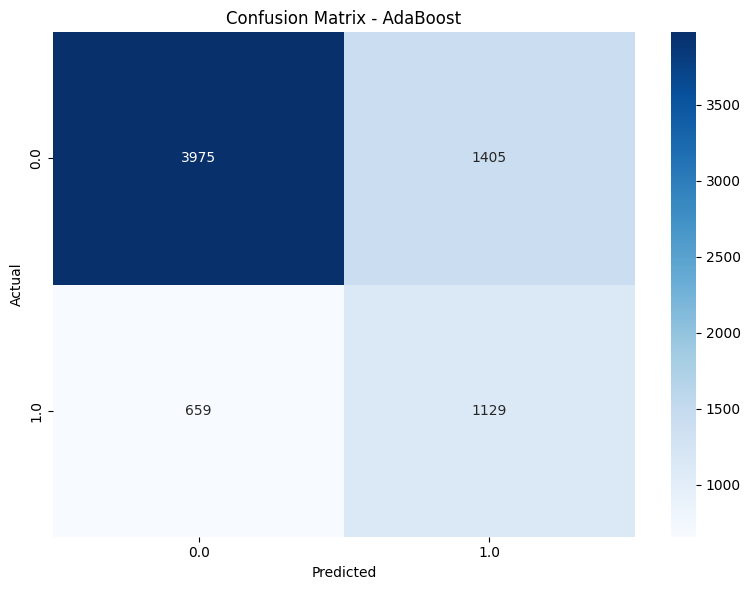


🚀 Training and Evaluating: LightGBM
[LightGBM] [Info] Number of positive: 8069, number of negative: 8069
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001740 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5865
[LightGBM] [Info] Number of data points in the train set: 16138, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.88      0.85      5380
         1.0       0.56      0.46      0.51      1788

    accuracy                           0.77      7168
   macro avg       0.69      0.67      0.68      7168
weighted avg       0.76      0.77      0.77      7168



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


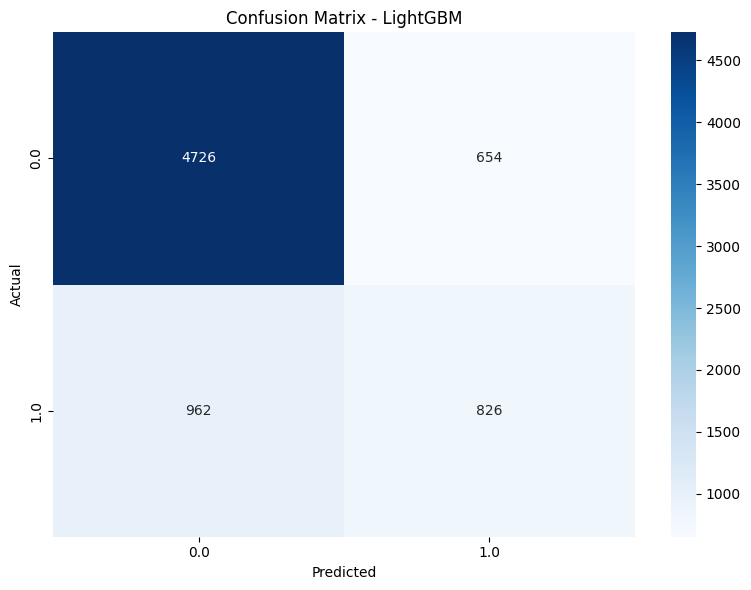


🚀 Training and Evaluating: SVM
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.71      0.77      5380
         1.0       0.42      0.65      0.51      1788

    accuracy                           0.69      7168
   macro avg       0.64      0.68      0.64      7168
weighted avg       0.75      0.69      0.71      7168



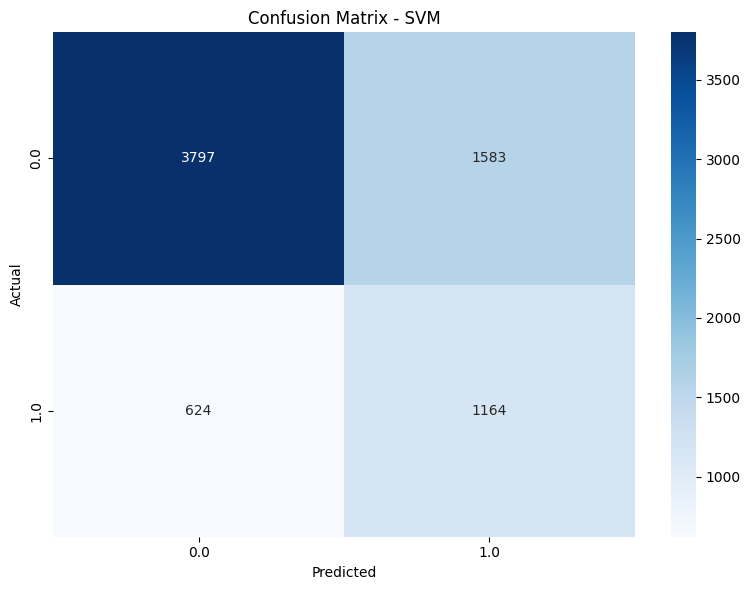

✅ Exported results to model_comparison_results.csv


In [17]:
from sklearn.metrics import classification_report, confusion_matrix
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.svm import SVC
df = pd.concat([df_train,df_test])

X = df.drop(columns=['label'])
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Identify categorical and numeric columns
categorical_cols = ['Gender','Race', 'milk_consumption','SmokeFam']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col !='label']
print(numeric_cols)
print(categorical_cols)
# 5. Define preprocessors
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# 6. Define models
models_to_test = {
    'XGBoost': XGBClassifier(
        colsample_bytree=1.0, learning_rate=0.1, max_depth=7,
        n_estimators=50, subsample=1.0, use_label_encoder=False,
        eval_metric='mlogloss', random_state=42
    ),
    'ElasticNetLogistic': LogisticRegression(
        penalty='elasticnet', solver='saga', max_iter=1000,
        random_state=42, multi_class='multinomial', C=1.0, l1_ratio=1.0
    ),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'SVM': SVC(
        kernel='rbf', C=1.0, probability=True, random_state=42
    ),
}

results = []

for name, model in models_to_test.items():
    print(f"\n🚀 Training and Evaluating: {name}")
    
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
        ('classifier', model)
    ])
    
    pipe.fit(X_train_raw, y_train)
    y_pred = pipe.predict(X_test_raw)
    
    # Predict proba for AUC
    y_proba = pipe.predict_proba(X_test_raw)

    # Handle binary and multiclass AUC
    if len(np.unique(y_test)) == 2:
        auc = roc_auc_score(y_test, y_proba[:, 1])
    else:
        auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')

    # ---- Macro metrics ----
    precision_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    accuracy = accuracy_score(y_test, y_pred)

    # ---- Per-class metrics ----
    class_report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    # Save summary row (macro + overall)
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'AUC': auc,
        'Precision (Macro)': precision_macro,
        'Recall (Macro)': recall_macro,
        'F1 Score (Macro)': f1_macro,
        'Per-class metrics': json.dumps(class_report)  # save full per-class metrics as JSON string
    })

    # Print classification report
    print("🔍 Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# Export
results_df = pd.DataFrame(results)
results_df.to_csv("model_comparison_results.csv", index=False)
print("✅ Exported results to model_comparison_results.csv")


[LightGBM] [Info] Number of positive: 3525, number of negative: 11361
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1507
[LightGBM] [Info] Number of data points in the train set: 14886, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.236800 -> initscore=-1.170306
[LightGBM] [Info] Start training from score -1.170306


c:\mydata\G8Vitamin\.venv\Lib\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


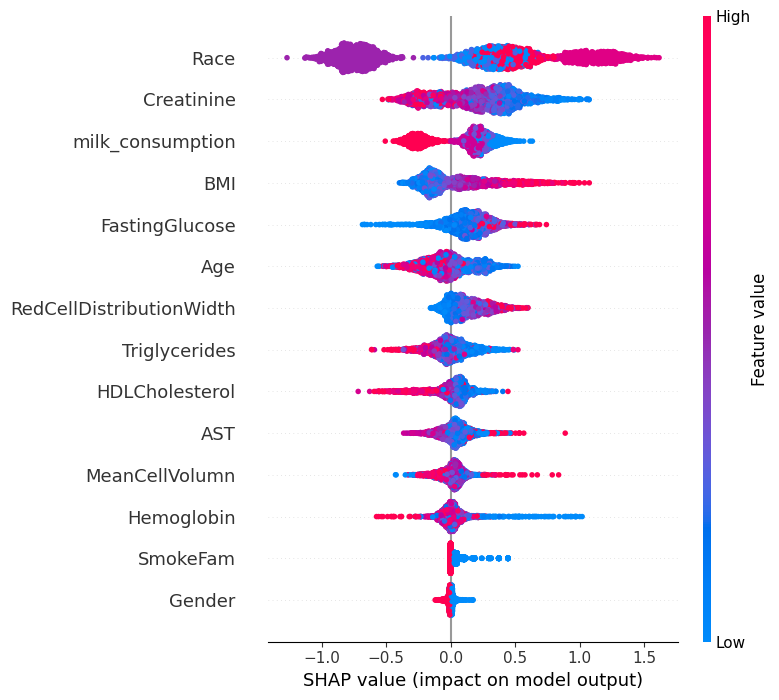

In [103]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# Tiền xử lý dữ liệu
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)

# Chuyển sparse matrix sang dense nếu cần
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

# Huấn luyện lại mô hình
lgbm_model = models_to_test['LightGBM']
lgbm_model.fit(X_train_processed, y_train)

# Tạo SHAP explainer và tính giá trị SHAP
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test_dense)

# Lấy tên feature sau OneHotEncoder
onehot_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = list(onehot_feature_names) + numeric_cols

# Tạo DataFrame SHAP
shap_df = pd.DataFrame(shap_values[1] if isinstance(shap_values, list) else shap_values, columns=all_feature_names)

# ✅ Gộp SHAP theo đặc trưng gốc nhưng KHÔNG dùng abs()
def aggregate_shap_preserve_sign(shap_df, original_cat_cols, numeric_cols):
    aggregated = pd.DataFrame()
    for col in original_cat_cols:
        matching_cols = [c for c in shap_df.columns if c.startswith(col + "_")]
        aggregated[col] = shap_df[matching_cols].sum(axis=1)  # ✅ giữ giá trị âm/dương
    for col in numeric_cols:
        aggregated[col] = shap_df[col]  # giữ nguyên giá trị số
    return aggregated

# Gộp SHAP và dữ liệu gốc để truyền vào summary_plot
shap_agg = aggregate_shap_preserve_sign(shap_df, categorical_cols, numeric_cols)
X_test_original = X_test_raw[categorical_cols + numeric_cols].reset_index(drop=True)

# ✅ Vẽ biểu đồ SHAP với chiều ảnh hưởng âm/dương
shap.summary_plot(shap_agg.values, features=X_test_original, feature_names=shap_agg.columns)


## Error Analysis

[LightGBM] [Info] Number of positive: 11361, number of negative: 11361
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001824 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4875
[LightGBM] [Info] Number of data points in the train set: 22722, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
🔍 Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.70      0.75      2088
         1.0       0.49      0.63      0.55       946

    accuracy                           0.68      3034
   macro avg       0.65      0.67      0.65      3034
weighted avg       0.71      0.68      0.69      3034



c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\mydata\G8Vitamin\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


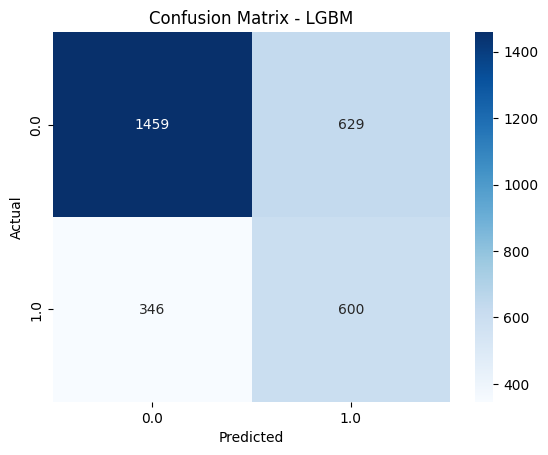


🔍 Error counts by Age:
error_type  Correct  False Negative  False Positive
Age                                                
12.0             40               9              10
13.0             43              17              13
14.0             46               4              14
15.0             46               9              12
16.0             48              15              15
...             ...             ...             ...
76.0             17               1               2
77.0             16               1               5
78.0             15               3               2
79.0              9               0               4
80.0            103              14              19

[69 rows x 3 columns]

🔍 Error counts by Race:
error_type  Correct  False Negative  False Positive
Race                                               
1.0             250              64             118
2.0             187              48              46
3.0             913             140         

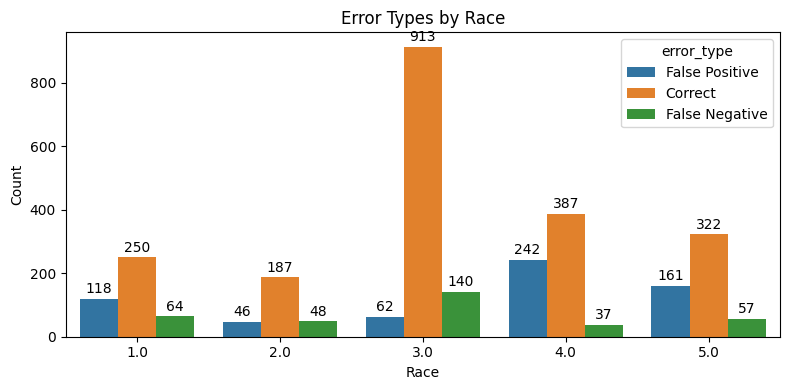


🔍 Error counts by milk_consumption:
error_type        Correct  False Negative  False Positive
milk_consumption                                         
5.397605e-79          378              70             138
1.000000e+00          394              74             149
2.000000e+00          602              75             205
3.000000e+00          685             127             137


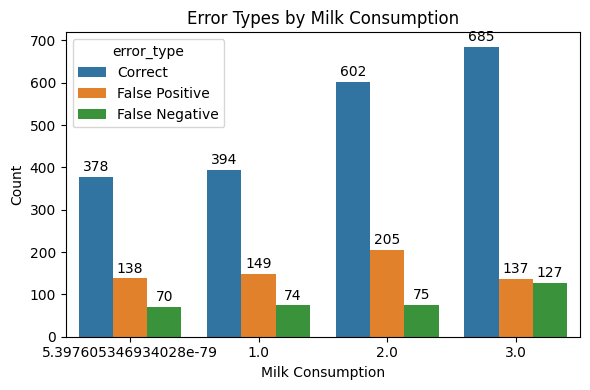


🔍 Error counts by Age Group (optimized bins):
error_type  Correct  False Negative  False Positive
age_group                                          
<20 tuổi        350              70              90
20–35 tuổi      414              66             162
36–50 tuổi      391              66             138
51–65 tuổi      508              91             152
66+ tuổi        396              53              87


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\1620018460.py:136: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_errors.groupby(['age_group', 'error_type']).size().unstack(fill_value=0))


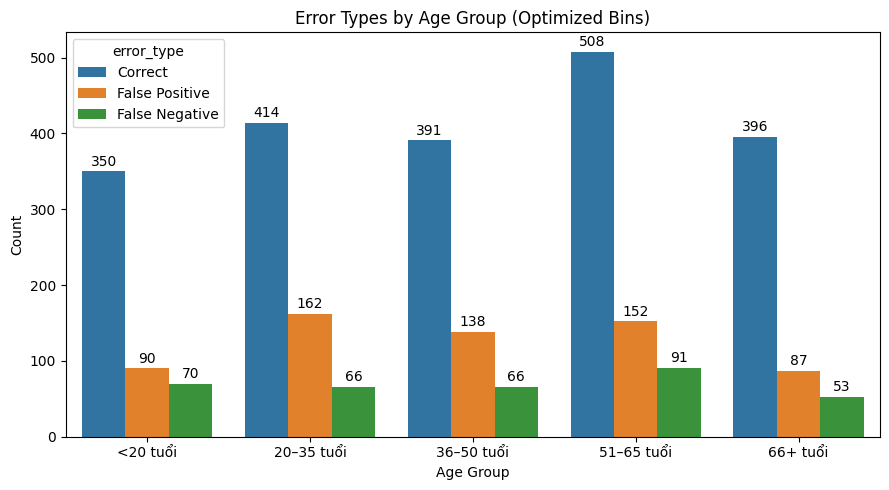


📊 Tỷ lệ lỗi theo nhóm tuổi (đơn vị: %) :
error_type  Correct (%)  False Positive (%)  False Negative (%)
age_group                                                      
<20 tuổi          68.63               17.65               13.73
20–35 tuổi        64.49               25.23               10.28
36–50 tuổi        65.71               23.19               11.09
51–65 tuổi        67.64               20.24               12.12
66+ tuổi          73.88               16.23                9.89


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\1620018460.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  error_counts = df_errors.groupby(['age_group', 'error_type']).size().unstack(fill_value=0)


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from lightgbm import LGBMClassifier

# --- 1. Prepare data
X_train_raw = df_train.drop(columns=['label'])
y_train = df_train['label']
X_test_raw = df_test.drop(columns=['label'])
y_test = df_test['label']

# --- 2. Column definitions
categorical_cols = ['Race', 'milk_consumption']
numeric_cols = [col for col in df_train.columns if col not in categorical_cols and col != 'label']

# --- 3. Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', StandardScaler(), numeric_cols)
    ]
)

# --- 4. LGBM pipeline with SMOTE
lgbm_pipe = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', LGBMClassifier(random_state=42))
])

# --- 5. Fit and predict
lgbm_pipe.fit(X_train_raw, y_train)
y_pred = lgbm_pipe.predict(X_test_raw)
y_proba = lgbm_pipe.predict_proba(X_test_raw)[:, 1]

# --- 6. Evaluation
print("🔍 Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0.0, 1.0], yticklabels=[0.0, 1.0])
plt.title("Confusion Matrix - LGBM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- 7. Attach predictions to test set
df_errors = X_test_raw.copy()
df_errors['true_label'] = y_test.values
df_errors['predicted_label'] = y_pred
df_errors['proba_class1'] = y_proba

# --- 8. Mark error types
df_errors['error_type'] = np.where(
    (df_errors['true_label'] == 1) & (df_errors['predicted_label'] == 0), 'False Negative',
    np.where((df_errors['true_label'] == 0) & (df_errors['predicted_label'] == 1), 'False Positive', 'Correct')
)

# --- 9. Error counts by categorical feature
age_error_counts = df_errors.groupby(['Age', 'error_type']).size().unstack(fill_value=0)
print("\n🔍 Error counts by Age:")
print(age_error_counts)

race_error_counts = df_errors.groupby(['Race', 'error_type']).size().unstack(fill_value=0)
print("\n🔍 Error counts by Race:")
print(race_error_counts)

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df_errors, x='Race', hue='error_type')
plt.title('Error Types by Race')
plt.ylabel('Count')
plt.xlabel('Race')

# Thêm số lượng trên từng cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.tight_layout()
plt.show()


milk_error_counts = df_errors.groupby(['milk_consumption', 'error_type']).size().unstack(fill_value=0)
print("\n🔍 Error counts by milk_consumption:")
print(milk_error_counts)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_errors, x='milk_consumption', hue='error_type')
plt.title('Error Types by Milk Consumption')
plt.ylabel('Count')
plt.xlabel('Milk Consumption')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.tight_layout()
plt.show()

# # --- 10. Compare numeric features
# numeric_features = ['BMI', 'FastingGlucose', 'ALT', 'Triglycerides',
#                     'Creatinine', 'HDLCholesterol', 'Hemoglobin',
#                     'MeanCellVolumn', 'RedCellDistributionWidth']

# print("\n🔍 Mean of numeric features by error type:\n")
# print(df_errors.groupby('error_type')[numeric_features].mean())

# # --- 11. Boxplot for each numeric feature
# for feature in numeric_features:
#     plt.figure(figsize=(6, 4))
#     sns.boxplot(x='error_type', y=feature, data=df_errors)
#     plt.title(f'{feature} by Error Type')
#     plt.tight_layout()
#     plt.show()

# --- 12. Age Grouping & Error Analysis
age_bins = [0, 30, 45, 60, 120]
age_labels = ['18-30', '31-45', '46-60', '60+']
df_errors['age_group'] = pd.cut(df_errors['Age'], bins=age_bins, labels=age_labels, right=False)

# --- 13. Error summary by age group
# --- Cập nhật nhóm tuổi theo phân loại mới
# Gộp lại nhóm tuổi để dễ phân tích
age_bins = [0, 20, 36, 51, 66, np.inf]
age_labels = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

df_errors['age_group'] = pd.cut(df_errors['Age'], bins=age_bins, labels=age_labels, right=False)

# Thống kê lại lỗi
print("\n🔍 Error counts by Age Group (optimized bins):")
print(df_errors.groupby(['age_group', 'error_type']).size().unstack(fill_value=0))

# Vẽ biểu đồ mới
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df_errors, x='age_group', hue='error_type')
plt.title('Error Types by Age Group (Optimized Bins)')
plt.ylabel('Count')
plt.xlabel('Age Group')

# Gắn số lượng lên các cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=2)

plt.tight_layout()
plt.show()

# --- Đếm số lượng theo nhóm tuổi và loại lỗi
error_counts = df_errors.groupby(['age_group', 'error_type']).size().unstack(fill_value=0)

# --- Tính tổng số mẫu trong từng nhóm tuổi
error_counts['Total'] = error_counts.sum(axis=1)

# --- Tính % lỗi
error_counts['False Positive (%)'] = (error_counts['False Positive'] / error_counts['Total'] * 100).round(2)
error_counts['False Negative (%)'] = (error_counts['False Negative'] / error_counts['Total'] * 100).round(2)
error_counts['Correct (%)'] = (error_counts['Correct'] / error_counts['Total'] * 100).round(2)

# --- Hiển thị bảng phân tích
print("\n📊 Tỷ lệ lỗi theo nhóm tuổi (đơn vị: %) :")
print(error_counts[['Correct (%)', 'False Positive (%)', 'False Negative (%)']])




In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Danh sách nhóm tuổi
age_groups = df_errors['age_group'].unique()

# Tạo bảng lưu kết quả
f1_table = []

for group in age_groups:
    subset = df_errors[df_errors['age_group'] == group]
    y_true = subset['true_label']
    y_pred = subset['predicted_label']
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    f1_table.append({
        'Age Group': group,
        'Precision': round(precision, 3),
        'Recall': round(recall, 3),
        'F1 Score': round(f1, 3),
        'Samples': len(subset)
    })

# Hiển thị dưới dạng DataFrame
f1_df = pd.DataFrame(f1_table).sort_values(by='F1 Score', ascending=False)
print("\n📊 F1-score và các chỉ số theo nhóm tuổi:")
print(f1_df)



📊 F1-score và các chỉ số theo nhóm tuổi:
    Age Group  Precision  Recall  F1 Score  Samples
3  20–35 tuổi      0.567   0.763     0.650      642
4    <20 tuổi      0.583   0.643     0.612      510
2  36–50 tuổi      0.485   0.663     0.560      595
0  51–65 tuổi      0.397   0.524     0.451      751
1    66+ tuổi      0.269   0.376     0.314      536


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\4102137785.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=f1_df, x='Age Group', y='F1 Score', order=age_order, palette='viridis')


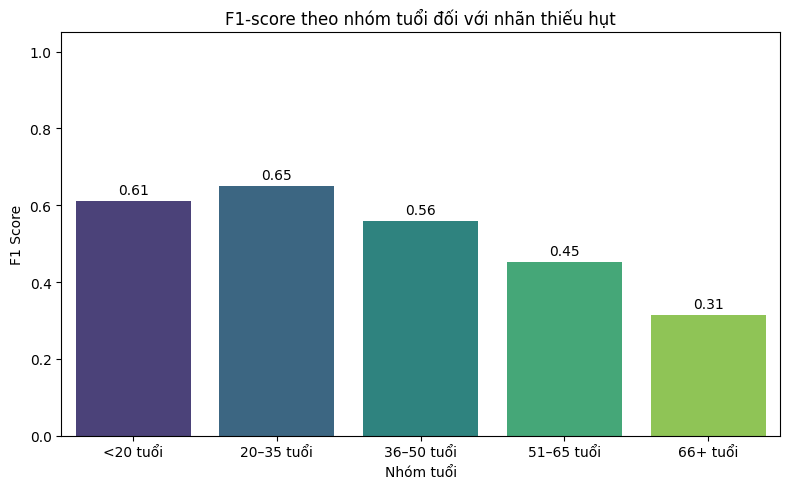

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score

# Đảm bảo thứ tự nhóm tuổi
age_order = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

f1_table = []

for group in age_order:
    subset = df_errors[df_errors['age_group'] == group]
    y_true = subset['true_label']
    y_pred = subset['predicted_label']
    
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    f1_table.append({
        'Age Group': group,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Samples': len(subset)
    })

f1_df = pd.DataFrame(f1_table)


# Vẽ biểu đồ cột
plt.figure(figsize=(8, 5))
sns.barplot(data=f1_df, x='Age Group', y='F1 Score', order=age_order, palette='viridis')

# Thêm nhãn giá trị trên mỗi cột
for index, row in f1_df.iterrows():
    plt.text(index, row['F1 Score'] + 0.01, f"{row['F1 Score']:.2f}", ha='center', va='bottom')

plt.title("F1-score theo nhóm tuổi đối với nhãn thiếu hụt")
plt.ylabel("F1 Score")
plt.xlabel("Nhóm tuổi")
plt.ylim(0, 1.05)  # Giới hạn trục y từ 0 đến 1.05 để dễ nhìn
plt.tight_layout()
plt.show()


In [34]:
import pandas as pd
from sklearn.metrics import f1_score

# Giả sử bạn đã có df_errors chứa: 'age_group', 'true_label', 'predicted_label'
age_order = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

macro_f1_table = []

for group in age_order:
    subset = df_errors[df_errors['age_group'] == group]
    y_true = subset['true_label']
    y_pred = subset['predicted_label']
    
    # Macro F1 = trung bình F1 của từng class (0, 1)
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    macro_f1_table.append({
        'Age Group': group,
        'Macro F1 Score': macro_f1,
        'Samples': len(subset)
    })

macro_f1_df = pd.DataFrame(macro_f1_table)
print(macro_f1_df)


    Age Group  Macro F1 Score  Samples
0    <20 tuổi        0.674246      510
1  20–35 tuổi        0.644774      642
2  36–50 tuổi        0.639677      595
3  51–65 tuổi        0.611003      751
4    66+ tuổi        0.576218      536


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\3826659596.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=macro_f1_df, x='Age Group', y='Macro F1 Score', order=age_order, palette='magma')


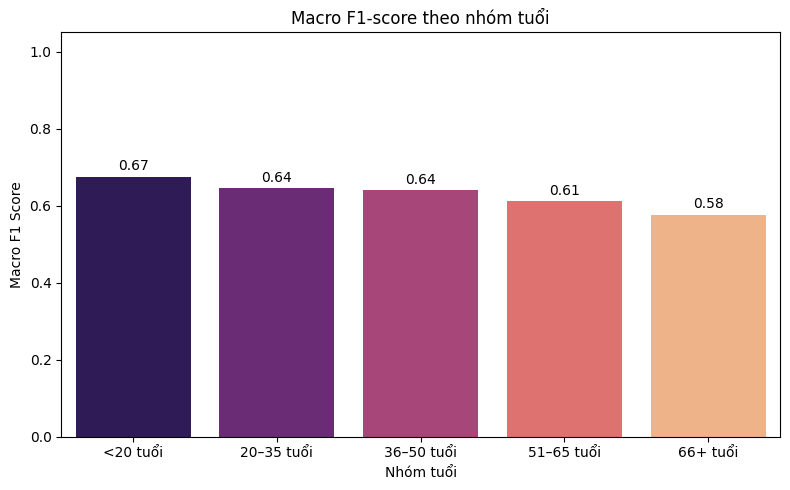

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(data=macro_f1_df, x='Age Group', y='Macro F1 Score', order=age_order, palette='magma')

for index, row in macro_f1_df.iterrows():
    plt.text(index, row['Macro F1 Score'] + 0.01, f"{row['Macro F1 Score']:.2f}", ha='center', va='bottom')

plt.title("Macro F1-score theo nhóm tuổi")
plt.ylabel("Macro F1 Score")
plt.xlabel("Nhóm tuổi")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()


In [36]:
# Tạo bảng phân tích kết hợp milk_consumption và age_group
milk_age_counts = df_errors.groupby(['age_group', 'milk_consumption', 'error_type']).size().unstack(fill_value=0)

print("\n🍼 Phân tích lỗi theo milk_consumption và nhóm tuổi:")
display(milk_age_counts)

# Tạo bảng phân tích kết hợp Race và age_group
race_age_counts = df_errors.groupby(['age_group', 'Race', 'error_type']).size().unstack(fill_value=0)

print("\n🎭 Phân tích lỗi theo Race và nhóm tuổi:")
display(race_age_counts)



🍼 Phân tích lỗi theo milk_consumption và nhóm tuổi:


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\167525807.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  milk_age_counts = df_errors.groupby(['age_group', 'milk_consumption', 'error_type']).size().unstack(fill_value=0)


error_type                   Correct  False Negative  False Positive
age_group  milk_consumption                                         
<20 tuổi   5.397605e-79           24               6               2
           1.000000e+00           54               9              14
           2.000000e+00          103              20              30
           3.000000e+00          169              35              44
20–35 tuổi 5.397605e-79           96               8              35
           1.000000e+00           92              17              39
           2.000000e+00          117              15              55
           3.000000e+00          109              26              33
36–50 tuổi 5.397605e-79           78              14              39
           1.000000e+00           82              13              36
           2.000000e+00          117              18              40
           3.000000e+00          114              21              23
51–65 tuổi 5.397605e-79          102              30              39
           1.000000e+00          114              21              46
           2.000000e+00          146              10              47
           3.000000e+00          146              30              20
66+ tuổi   5.397605e-79           78              12              23
           1.000000e+00           52              14              14
           2.000000e+00          119              12              33
           3.000000e+00          147              15              17


🎭 Phân tích lỗi theo Race và nhóm tuổi:


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\167525807.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_age_counts = df_errors.groupby(['age_group', 'Race', 'error_type']).size().unstack(fill_value=0)


error_type       Correct  False Negative  False Positive
age_group  Race                                         
<20 tuổi   1.0        49              18              35
           2.0        19               7               8
           3.0       160              24               1
           4.0        68               8              20
           5.0        54              13              26
20–35 tuổi 1.0        64              12              22
           2.0        24               5              22
           3.0       158              34              22
           4.0       107               6              44
           5.0        61               9              52
36–50 tuổi 1.0        47              10              32
           2.0        34              12               9
           3.0       165              27              18
           4.0        69               3              43
           5.0        76              14              36
51–65 tuổi 1.0        59              15              23
           2.0        78              15               6
           3.0       199              31               9
           4.0        94              11              79
           5.0        78              19              35
66+ tuổi   1.0        31               9               6
           2.0        32               9               1
           3.0       231              24              12
           4.0        49               9              56
           5.0        53               2              12

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\3874764405.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_counts = df.groupby('Nhóm tuổi').size()


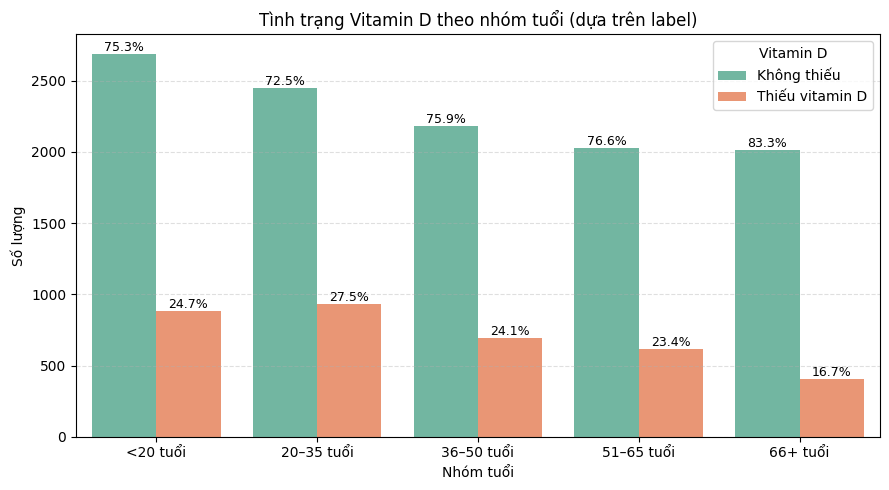

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = df_train.copy()
# Nhóm tuổi mới
age_bins = [0, 20, 36, 51, 66, np.inf]
age_labels = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

# Đảm bảo đã phân nhóm tuổi mới
df['Nhóm tuổi'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Tạo cột trạng thái vitamin D dạng text từ label 0/1
df['Tình trạng Vitamin D'] = df['label'].apply(lambda x: 'Thiếu vitamin D' if x == 1 else 'Không thiếu')

# Vẽ biểu đồ đếm số lượng theo nhóm tuổi mới và label
plt.figure(figsize=(9, 5))
ax = sns.countplot(data=df, x='Nhóm tuổi', hue='Tình trạng Vitamin D', palette='Set2')

plt.title('Tình trạng Vitamin D theo nhóm tuổi (dựa trên label)')
plt.xlabel('Nhóm tuổi')
plt.ylabel('Số lượng')
plt.legend(title='Vitamin D')
plt.grid(True, axis='y', linestyle='--', alpha=0.4)

# Tính tổng số lượng theo nhóm tuổi
total_counts = df.groupby('Nhóm tuổi').size()

# Thêm phần trăm trên mỗi cột
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        x_pos = p.get_x()
        width = p.get_width()
        idx = int(round(x_pos + width / 2))
        group = ax.get_xticklabels()[idx].get_text()

        total = total_counts[group]
        percent = height / total * 100
        ax.text(
            p.get_x() + width / 2,
            height,
            f'{percent:.1f}%',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.tight_layout()
plt.show()


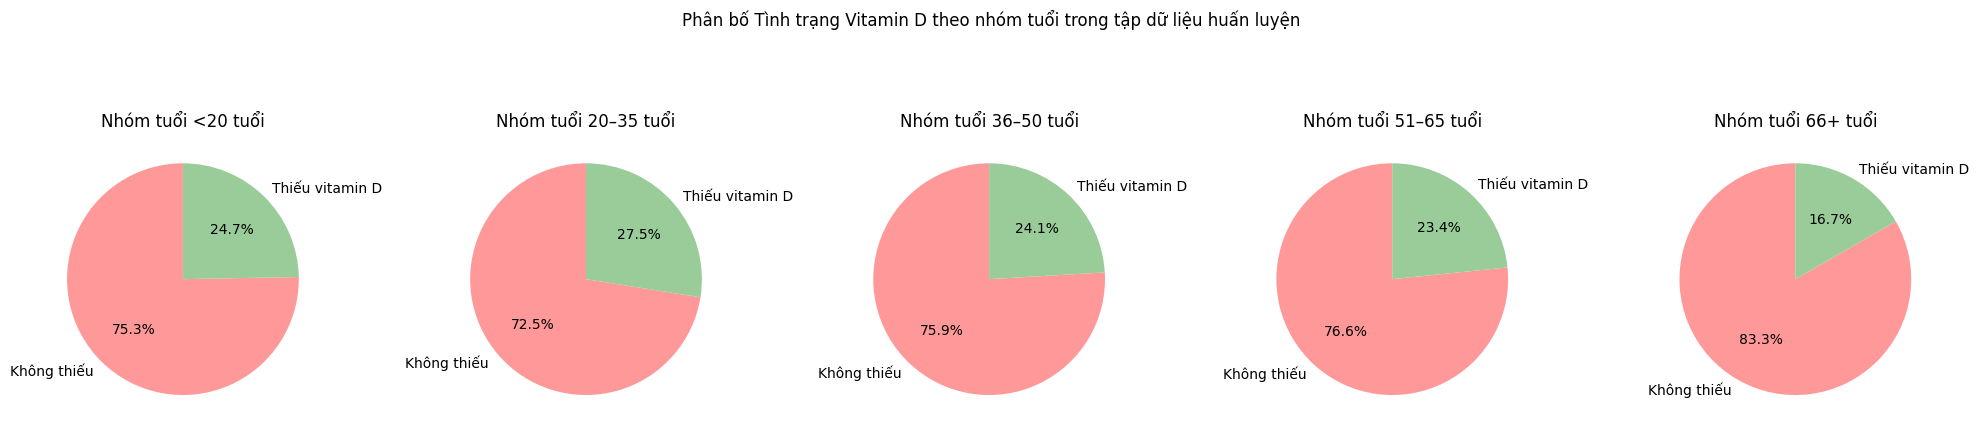

In [38]:
import matplotlib.pyplot as plt

# Nhóm tuổi mới
age_bins = [0, 20, 36, 51, 66, np.inf]
age_labels = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

# Phân nhóm tuổi mới
df['Nhóm tuổi'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Chuyển label thành text để dễ nhìn
df['Tình trạng Vitamin D'] = df['label'].apply(lambda x: 'Thiếu vitamin D' if x == 1 else 'Không thiếu')

# Tạo biểu đồ hình tròn cho từng nhóm tuổi
fig, axes = plt.subplots(1, len(age_labels), figsize=(20, 5))

for ax, group in zip(axes, age_labels):
    data_group = df[df['Nhóm tuổi'] == group]['Tình trạng Vitamin D'].value_counts()
    labels = data_group.index
    sizes = data_group.values

    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#99cc99'])
    ax.set_title(f'Nhóm tuổi {group}')

plt.suptitle('Phân bố Tình trạng Vitamin D theo nhóm tuổi trong tập dữ liệu huấn luyện')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


📊 Số lượng mẫu theo nhóm tuổi và chủng tộc:
Race         1.0  2.0   3.0   4.0  5.0
age_group                             
<20 tuổi    1019  207  1066  1048  234
20–35 tuổi   743  241  1453   676  265
36–50 tuổi   494  214  1395   549  219
51–65 tuổi   453  205  1265   545  175
66+ tuổi     303  138  1561   329   89


C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\115837645.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_race_counts = df_train.groupby(['age_group', 'Race']).size().unstack(fill_value=0)
C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_2560\115837645.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df_train.groupby(['age_group', 'Race']).size().reset_index(name='count')


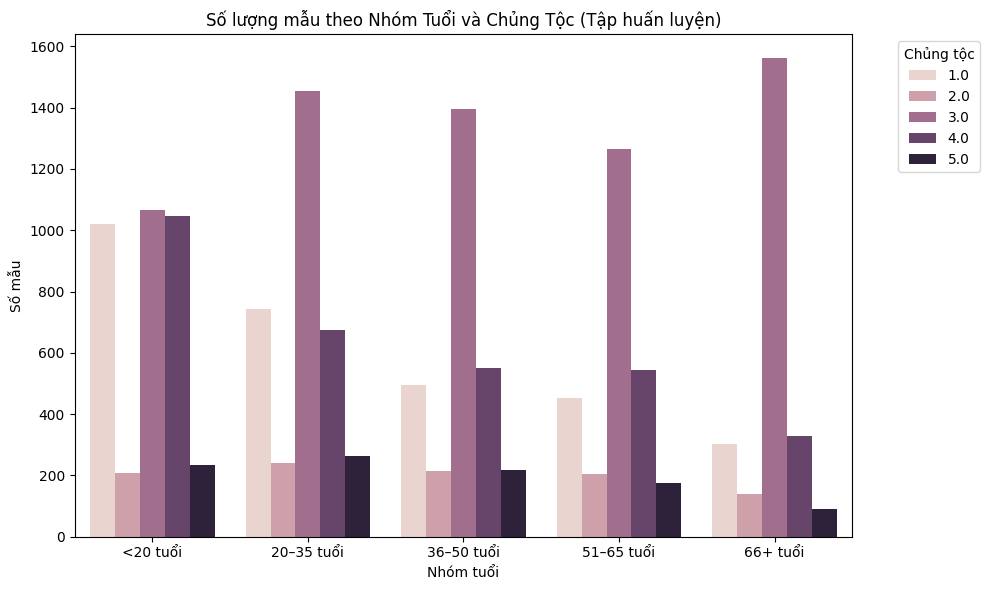

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Tạo nhóm tuổi (Age Group) trong df_train
age_bins = [0, 20, 36, 51, 66, float('inf')]
age_labels = ['<20 tuổi', '20–35 tuổi', '36–50 tuổi', '51–65 tuổi', '66+ tuổi']

# Thêm cột nhóm tuổi
df_train['age_group'] = pd.cut(df_train['Age'], bins=age_bins, labels=age_labels, right=False)

# --- 2. Thống kê số lượng mẫu theo nhóm tuổi và chủng tộc
age_race_counts = df_train.groupby(['age_group', 'Race']).size().unstack(fill_value=0)

print("📊 Số lượng mẫu theo nhóm tuổi và chủng tộc:")
print(age_race_counts)

# --- 3. Trực quan hóa dữ liệu: Stacked Bar Chart
df_plot = df_train.groupby(['age_group', 'Race']).size().reset_index(name='count')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_plot, x='age_group', y='count', hue='Race')
plt.title("Số lượng mẫu theo Nhóm Tuổi và Chủng Tộc (Tập huấn luyện)")
plt.ylabel("Số mẫu")
plt.xlabel("Nhóm tuổi")
plt.legend(title="Chủng tộc", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
